## Installations & Label Definitons

In [1]:
# Cell 1: Install & import libs (FIXED)
import sys
import subprocess
import os

def install_package(package):
    """Safely install a package using pip"""
    try:
        # Try using pip directly
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        print(f"✅ Successfully installed {package}")
        return True
    except subprocess.CalledProcessError as e:
        print(f"❌ Failed to install {package}: {e}")
        return False

def check_package(package_name, import_name=None):
    """Check if a package is already installed"""
    if import_name is None:
        import_name = package_name
    try:
        __import__(import_name)
        print(f"✅ {package_name} is already installed")
        return True
    except ImportError:
        print(f"⚠️  {package_name} not found, installing...")
        return False

print("🔧 Checking and installing required packages...")

packages = [
    ("pandas", "pandas"),
    ("openai", "openai"),
    ("scikit-learn", "sklearn")
]

for package, import_name in packages:
    if not check_package(package, import_name):
        install_package(package)

print("\n📦 Importing libraries...")
try:
    import pandas as pd
    import openai
    print("✅ All imports successful!")
except ImportError as e:
    print(f"❌ Import error: {e}")
    print("💡 Try restarting the kernel and running this cell again")

print("\n🎯 Ready to proceed!")

🔧 Checking and installing required packages...
✅ pandas is already installed
✅ openai is already installed
✅ scikit-learn is already installed

📦 Importing libraries...
✅ All imports successful!

🎯 Ready to proceed!


In [2]:
# =========================
# System diagnostic + label/definition setup (updated & tightened)
# =========================
import sys, platform, os, re

print("🔍 SYSTEM DIAGNOSTICS")
print("=" * 40)
print(f"Python version: {sys.version.split()[0]}")
print(f"Platform: {platform.platform()}")
print(f"Architecture: {platform.architecture()}")
print(f"Python executable: {sys.executable}")
print(f"CWD: {os.getcwd()}")

print("\n📦 PACKAGE VERSIONS:")
def _ver(modname, attr="__version__"):
    try:
        mod = __import__(modname)
        v = getattr(mod, attr, "unknown")
        print(f"✅ {modname}: {v}")
    except Exception as e:
        print(f"⚠️  {modname}: {e}")

_ver("pandas")
_ver("openai")
_ver("sklearn")
_ver("numpy")

# =========================
# Labels (fixed order)
# =========================
labels = [
    "Medical",
    "Mental Health",
    "Abuse",
    "Aggression",
    "Sexual",
    "Discrimination",
    "Pregnancy",
    "Not Applicable",
]

# =========================
# Tight, low-overlap definitions (optimized for small models)
# =========================
definitions = {
    "Medical": (
        "Concrete medical details tied to abortion/miscarriage/sexual-violence"
        "(pills, D&C, HCG, procedures, ultrasound/ER, antibiotics, confirmed heavy bleeding, period). "
        "Do not use for generic symptoms unless clearly linked to the core topics."
    ),
    "Mental Health": (
        "Explicit or observable emotional or psychological distress caused by the core topic. "
        "Includes feelings or reactions such as panic attacks, severe anxiety, intrusive thoughts, "
        "grief, worry, guilt, sadness, crying, or being in tears. "
        "Also include cases where someone is clearly emotionally overwhelmed or struggling to cope, "
        "even if they are not the narrator."
    ),
    "Abuse": (
        "Coercion/control/threats/sexual assault by another person. Includes pressuring about abortion, "
        "rape, stalking, intimidation, isolation, threats to report/ruin reputation. "
        "This category also covers sexual assault, whether through force, coercion, "
        "or exploitation of vulnerability."
    ),
    "Aggression": (
        "Any non sexual physical violence such as hitting, slapping, choking, restraining, or throwing objects. "
        "Use only when there is clear evidence of physical harm"
        "Exclude sexual assault or any sexual coercion — those belong under 'Abuse'. "
        "Also exclude purely verbal aggression or arguments."
    ),
    "Sexual": (
        "Any mention of consensual sexual content, behavior, or sexual acts (sex, having sex, "
        "handjob, blowjob, masturbate, finger, nudes, oral, grind, rubbing, porn, cum, came etc.), "
        "as well as sexual health topics (condoms, libido, etc.). "
        "Exclude sexual assault (that belongs under Abuse), but this tag can co-occur if "
        "consensual sexual content or sexual health topics are also present. "
        "Do not include kissing or making out under this tag."
    ),
    "Discrimination": (
        "Stigma, shaming, moral policing, legal/clinic barriers, or mistreatment related to the core topic "
        "(denial of care, derogatory remarks)."
        "Exclude neutral or factual mentions of laws or legality ('abortion is not legal in this state')."
    ),
    "Pregnancy": (
        "Mentions of being pregnant, suspected pregnancy, taking a pregnancy test, missed "
        "or late periods, pregnancy loss, miscarriage, abortion, or chemical pregnancy. "
        "Include both personal experiences and general discussions of abortion, "
        "or miscarriage since these are pregnancy-related outcomes."
    ),
    "Not Applicable": (
        "Use only if the post is not about abortion, miscarriage, or sexual violence and none of the above labels apply."
    ),
}

# =========================
# Domain keyword prior (used to gate relevance in prompts or QA)
# =========================
DOMAIN_KEYWORDS = {
    "abortion", "abort", "miscarriage", "pregnancy loss", "plan b",
    "mifepristone", "misoprostol", "medical abortion", "surgical abortion",
    "d&c", "dilation and curettage", "pregnant", "late period",
    "pregnancy test", "spotting", "heavy bleeding", "rape",
    "sexual assault", "assaulted", "aftercare", "clinic", "ultrasound",
}

# Optional: finer per-label evidence hints (can be sprinkled into prompts)
LABEL_HINTS = {
    "Medical": {"pill", "mifepristone", "misoprostol", "procedure", "ultrasound", "antibiotic", "infection", "ER"},
    "Mental Health": {"panic", "anxiety", "crying", "grief", "hopeless", "intrusive"},
    "Abuse": {"forced", "threat", "coerce", "stalk", "rape", "assaulted", "control", "isolate"},
    "Aggression": {"hit", "beat", "choke", "strangle", "punch", "gun"},
    "Sexual": {"sex", "condom", "libido", "porn", "kink", "after sex"},
    "Discrimination": {"illegal", "ban", "deny", "refuse", "policy", "law", "shame"},
    "Pregnancy": {"pregnant", "missed period", "late period", "test", "positive", "miscarriage"},
}

# =========================
# Helper: quick domain-relevance gate (use if you want to prefilter or add as a hint)
# =========================
DOMAIN_RE = re.compile(r"|".join(re.escape(k) for k in sorted(DOMAIN_KEYWORDS)), re.IGNORECASE)

def is_domain_related(text: str) -> bool:
    return bool(DOMAIN_RE.search(text or ""))

# =========================
# Sanity checks
# =========================
missing_defs = [l for l in labels if l not in definitions]
assert not missing_defs, f"Missing definitions for: {missing_defs}"

print("\n✅ Setup complete:")
print(f"- Labels: {len(labels)} ({labels})")
print(f"- Definitions loaded: {len(definitions)}")
print(f"- Domain keywords loaded: {len(DOMAIN_KEYWORDS)}")
print(f"- Label hints loaded: {len(LABEL_HINTS)}")


🔍 SYSTEM DIAGNOSTICS
Python version: 3.10.12
Platform: Linux-6.8.0-1040-aws-x86_64-with-glibc2.35
Architecture: ('64bit', 'ELF')
Python executable: /bin/python3
CWD: /home/ubuntu/TW_MultiLabel_SMP/jupyter-notebooks

📦 PACKAGE VERSIONS:
✅ pandas: 2.3.1
✅ openai: 1.99.1
✅ sklearn: 1.7.1
✅ numpy: 2.2.6

✅ Setup complete:
- Labels: 8 (['Medical', 'Mental Health', 'Abuse', 'Aggression', 'Sexual', 'Discrimination', 'Pregnancy', 'Not Applicable'])
- Definitions loaded: 8
- Domain keywords loaded: 22
- Label hints loaded: 7


## Dataset

In [3]:
# Cell 3 : Load Dataset
df = pd.read_csv("/home/ubuntu/TW_MultiLabel_SMP/jupyter-notebooks/training_sets/train_20251007_153631.csv")
df.head()

,id,subreddit,title,selftext,created_utc,url,Tags,__dataset,__source_file,unique_key,label
0,1ku7sfe,relationships,I don't know how to get over mourning my pregn...,I'm not sure where to post this so I thought h...,2025-05-24 9:40:46,https://www.reddit.com/r/relationships/comment...,NaN,abortion,abortion_data-updated - new_abortion_related_s...,e1104d3e92052cc00ddeaea7313942ba45217e951ade53...,abortion
1,1cdk975,relationships,I (26M) am not sure how to approach my wife (2...,So I met my wife at twenty-one years old and s...,2024-04-26 12:34:48,https://www.reddit.com/r/relationships/comment...,NaN,abortion,abortion_data-updated - new_abortion_related_s...,5c1f54a1e633d6893eeedce8f7aedfa8fb148264dd32d6...,abortion
2,1l5ybv0,abortion,Not bleeding after taking misoprostol,"Hi everyone, just a little background I took M...",2025-06-07 23:33:12,https://www.reddit.com/r/abortion/comments/1l5...,NaN,abortion,abortion_data-updated - new_abortion_related_s...,78ce1e45e54581069c6fed51db138e226e0fbe51e9b0d8...,abortion
3,gsyxre,abortion,What is a legitimate reason to NEED to abort a...,This may be against the rules but I'm getting ...,2020-05-29 18:58:34,https://www.reddit.com/r/abortion/comments/gsy...,NaN,abortion,abortion_data-updated - new_abortion_related_s...,df2712ccb99b4350f56f5dada3ad3467a31739d332d550...,abortion
4,1lk8sba,TwoXChromosomes,"The Answer to The Question, ""When Was Your Las...","""Fuck the fascists. I'm not telling."" \n\nI ta...",2025-06-25 15:31:24,https://www.reddit.com/r/TwoXChromosomes/comme...,NaN,miscarriage,miscarriage-data-updated - miscarriage_related...,028912d0743ddc5ce4124c1d6441dbade63343371534e2...,miscarriage


In [4]:
# # Cell 4 : Step 1: Clean 'Tags' column if needed
# df["Tags"] = df["Tags"].apply(
#     lambda x: [tag.strip() for tag in x.split(",")] if isinstance(x, str) else x
# )

# # Step 2: Create binary columns per label
# all_labels = [
#     "Medical",
#     "Mental Health",
#     "Abuse",
#     "Aggression",
#     "Sexual",
#     "Discrimination",
#     "Pregnancy",
#     "Not Applicable"
# ]

# for label in all_labels:
#     df[label] = df["Tags"].apply(lambda tags: int(label in tags if isinstance(tags, list) else []))


## Prompts

In [19]:
# # ---- Cell 1 (NO-CLIP EXAMPLES) ----
# from sentence_transformers import SentenceTransformer
# import numpy as np
# from sklearn.metrics.pairwise import cosine_similarity
# import torch
# import json
# import pandas as pd
# import re  # for robust tag parsing

# # ---- Globals / setup (same assumptions as your code) ----
# global collected_examples_per_label
# collected_examples_per_label = {}  # Reset at each call

# # Assumes `labels` (list of label names) and `definitions` (dict[label] -> text) are already defined
# df = pd.read_csv("/home/ubuntu/TW_MultiLabel_SMP/jupyter-notebooks/training_sets/train_20251012_043813.csv")

# # 2,000-post TRAINING set (few-shot source; includes Tags)
# df_train = pd.read_csv("/home/ubuntu/TW_MultiLabel_SMP/datasets/2000_Posts_Annotations - Combined_Dataset.csv")

# # Resolve columns
# TITLE_CANDS = ["title","post_title","headline","subject"]
# BODY_CANDS  = ["selftext","body","text","description","content"]
# TAGS_CANDS  = ["Tags", "tags", "labels", "Labels"]

# def _find_col(df_, cands, kind):
#     for c in cands:
#         if c in df_.columns: return c
#     lower = {c.lower(): c for c in df_.columns}
#     for c in cands:
#         if c.lower() in lower: return lower[c.lower()]
#     raise KeyError(f"No {kind} column found. Tried {cands}. Available: {list(df_.columns)}")

# TITLE_COL   = _find_col(df,       TITLE_CANDS, "TITLE")
# BODY_COL    = _find_col(df,       BODY_CANDS,  "BODY")
# TITLE_COL_T = _find_col(df_train, TITLE_CANDS, "TRAIN_TITLE")
# BODY_COL_T  = _find_col(df_train, BODY_CANDS,  "TRAIN_BODY")
# TAGS_COL_T  = _find_col(df_train, TAGS_CANDS,  "TRAIN_TAGS")

# # Embeddings for the 2,000 training posts
# train_embeddings = torch.load("/home/ubuntu/embeddings/r8_embeddings_B.pt")
# if isinstance(train_embeddings, torch.Tensor):
#     train_embeddings = train_embeddings.detach().cpu().numpy()

# model = SentenceTransformer("all-mpnet-base-v2")

# with open("/home/ubuntu/TW_MultiLabel_SMP/similarity_scores/cross_similar_posts_k3_500_r8.json", "r") as f:
#     similar_post_map = json.load(f)  # TEST index (str) -> list of [TRAIN_idx, score] (or dicts)

# # Parse Tags
# def parse_tags_cell(cell):
#     if pd.isna(cell):
#         return set()
#     s = str(cell).strip()
#     s = s.replace("[", "").replace("]", "").replace("'", "").replace('"', "")
#     parts = [p.strip() for p in re.split(r"[;,]", s) if p.strip()]
#     return set(parts)

# CANON = {
#     "Pregnancy": "Pregnancy",
#     "Abuse": "Abuse",
#     "Aggression": "Aggression",
#     "Sexual": "Sexual",
#     "Medical": "Medical",
#     "Mental Health": "Mental Health",
#     "Discrimination": "Discrimination",
#     "Not Applicable": "Not Applicable",
#     "NA": "Not Applicable",
#     "N/A": "Not Applicable",
# }
# def canon_label(name: str) -> str:
#     return CANON.get(name.strip(), name.strip())

# # === CHANGE: NO CLIPPING IN FEW-SHOTS ===
# def _format_examples(label_name, positives, negatives=None, max_chars=None):
#     """
#     Formats positives/negatives into a few-shot block with NO truncation.
#     max_chars is ignored to honor full text.
#     """
#     blocks = []
#     for i, e in enumerate(positives, 1):
#         blocks.append(
#             f"Positive Example {i} for '{label_name}':\n"
#             f"Title: {str(e.get('title','')).strip()}\n"
#             f"Description: {str(e.get('body','')).strip()}\n"
#             "Label: YES"
#         )
#     if negatives:
#         for i, e in enumerate(negatives, 1):
#             blocks.append(
#                 f"Negative Example {i} (similar but should be NO):\n"
#                 f"Title: {str(e.get('title','')).strip()}\n"
#                 f"Description: {str(e.get('body','')).strip()}\n"
#                 "Label: NO"
#             )
#     return "\n\n".join(blocks) if blocks else "[none available]"

# # Precompute training label sets
# _train_label_sets = df_train[TAGS_COL_T].apply(parse_tags_cell).apply(lambda s: {canon_label(x) for x in s})

# def make_multishot_prompt_cosine(
#     k, title, body, current_index=None, include_defs=True, debug=False,
#     include_negatives=False, k_neg=2
# ):
#     """
#     TRUE k-shot prompting:
#     - Select positives via df_train[Tags].
#     - Prefer 3 precomputed TRAIN neighbors (JSON) that include the label; fallback to cosine over all TRAIN positives.
#     - Optional hard negatives.
#     - Inject examples into prompt.
#     """
#     global collected_examples_per_label
#     collected_examples_per_label = {}

#     input_text = f"{title or ''} {body or ''}"
#     input_embedding = model.encode([input_text], convert_to_numpy=True, normalize_embeddings=False)[0]

#     prompts_by_label = {}

#     for label_name in labels:
#         positives, negatives = [], []

#         if label_name != "Not Applicable":
#             pos_indices, pos_scores = [], []
#             used_json = False

#             # Precomputed neighbors filter by label
#             if current_index is not None and str(current_index) in similar_post_map:
#                 used_json = True
#                 try:
#                     pairs = similar_post_map[str(current_index)]
#                     for item in pairs:
#                         if isinstance(item, (list, tuple)) and len(item) >= 2:
#                             idx = int(item[0]); score = float(item[1])
#                         else:
#                             idx = int(item.get("idx", -1)); score = float(item.get("score", 0.0))
#                         if idx in df_train.index and label_name in _train_label_sets.loc[idx]:
#                             pos_indices.append(idx); pos_scores.append(score)
#                         if len(pos_indices) == k:
#                             break
#                 except Exception:
#                     used_json = False

#             # Fallback cosine over all TRAIN positives
#             if len(pos_indices) < k:
#                 cand_idx = [i for i, tags in _train_label_sets.items() if label_name in tags]
#                 if cand_idx:
#                     cand_emb = train_embeddings[cand_idx]
#                     sims = cosine_similarity([input_embedding], cand_emb)[0]
#                     order = np.argsort(sims)[::-1]
#                     for i_ord in order:
#                         idx = cand_idx[i_ord]
#                         if idx not in pos_indices:
#                             pos_indices.append(idx)
#                             pos_scores.append(float(sims[i_ord]))
#                             if len(pos_indices) == k:
#                                 break

#             # Materialize positives
#             for idx, score in zip(pos_indices, pos_scores):
#                 row_t = df_train.loc[idx]
#                 positives.append({
#                     "index": int(idx),
#                     "score": round(score, 4),
#                     "title": row_t.get(TITLE_COL_T, "[No Title]"),
#                     "body":  row_t.get(BODY_COL_T,  "[No Body]")
#                 })
#                 if debug:
#                     src = "json" if used_json else "cosine"
#                     print(f"[{label_name}] + idx={idx} score={score:.4f} ({src})")

#             # Optional negatives
#             if include_negatives:
#                 cand_idx = [i for i, tags in _train_label_sets.items() if label_name not in tags]
#                 if cand_idx:
#                     cand_emb = train_embeddings[cand_idx]
#                     sims = cosine_similarity([input_embedding], cand_emb)[0]
#                     top_kn = np.argsort(sims)[-k_neg:][::-1]
#                     for i_ord in top_kn:
#                         idx = cand_idx[i_ord]
#                         row_t = df_train.loc[idx]
#                         negatives.append({
#                             "index": int(idx),
#                             "score": float(sims[i_ord]),
#                             "title": row_t.get(TITLE_COL_T, "[No Title]"),
#                             "body":  row_t.get(BODY_COL_T,  "[No Body]")
#                         })

#         collected_examples_per_label[label_name] = positives

#         # ---- Build prompt ----
#         definition = definitions.get(label_name, "").strip() if include_defs else ""
#         fewshot_block = _format_examples(label_name, positives, negatives if include_negatives else None)

#         parts = [
#             "You are an attentive content reviewer tasked with identifying specific emotional or traumatic triggers "
#             "in Reddit posts related to abortion, miscarriage, or sexual violence.\n\n",
#             "DOMAIN GATE:\n",
#             "• If the post is NOT clearly about abortion, miscarriage, or sexual violence (A/M/SV), then:\n",
#             "  – If the current label is 'Not Applicable', answer YES and STOP.\n",
#             "  – Otherwise, answer NO and STOP.\n",
#             "• If the post IS clearly about A/M/SV, continue with the rules below.\n\n",
#             "Your task is to analyze the post and decide whether readers could be triggered by it. "
#             "We have multiple categories of trigger warnings, but in this case, "
#             "you will evaluate **only one trigger label at a time** using a careful step-by-step approach.\n\n",
#             f"Trigger Warning Label to evaluate: *{label_name}*\n\n",
#         ]
#         if include_defs:
#             parts.append(f"Definition of '{label_name}':\n{definition}\n\n")
#         parts += [
#             "Global constraints:\n",
#             "• Answer strictly with YES or NO (uppercase, no punctuation, no explanation).\n",
#             "• Only mark a label YES if the post *explicitly and clearly* matches the label’s definition.\n",
#             "• If the post is vague, uncertain, or does not directly match the definition, answer NO.\n",
#             "• Do not infer, assume, or guess based on weak signals.\n\n",
#             "Special rule for 'Not Applicable' (NA):\n",
#             "• 'Not Applicable' must be marked YES **only if no other trigger labels would be YES** for this post.\n",
#             "• If *any* other trigger label (evaluated separately) would be YES, then 'Not Applicable' must be NO.\n",
#             "• In other words, 'Not Applicable' is mutually exclusive with all other labels.\n\n",
#             "FEW-SHOT EXAMPLES (for calibration):\n",
#             fewshot_block,
#             "\n\n",
#             f"Title: {title.strip()}\n\n",
#             f"Description: {body.strip()}\n\n",
#             f"Does this post contain the '{label_name}' trigger?\n",
#             "Answer:"
#         ]
#         prompt_str = "".join(parts)

#         prompts_by_label[label_name] = prompt_str

#     return prompts_by_label

# # Single-label helper (returns injected prompt)
# def make_prompt_for_label(label_name, k, title, body, current_index=None, debug=False):
#     pm = make_multishot_prompt_cosine(k, title, body, current_index=current_index, debug=debug)
#     return pm[label_name]

# ---- Cell 1 (FIXED) ----
from sentence_transformers import SentenceTransformer
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import torch
import json
import pandas as pd
import re  # for robust tag parsing

# ---- Globals / setup (same assumptions as your code) ----
global collected_examples_per_label
collected_examples_per_label = {}  # Reset at each call

# Assumes `labels` (list of label names) and `definitions` (dict[label] -> text) are already defined
df = pd.read_csv("/home/ubuntu/TW_MultiLabel_SMP/jupyter-notebooks/training_sets/train_20251010_022233.csv")

# 1,500-post TRAINING set (few-shot source; includes Tags)
df_train = pd.read_csv("/home/ubuntu/TW_MultiLabel_SMP/datasets/1500_Posts_Annotations - Combined_Dataset.csv")

# Resolve columns
TITLE_CANDS = ["title","post_title","headline","subject"]
BODY_CANDS  = ["selftext","body","text","description","content"]
TAGS_CANDS  = ["Tags", "tags", "labels", "Labels"]

def _find_col(df_, cands, kind):
    for c in cands:
        if c in df_.columns: return c
    lower = {c.lower(): c for c in df_.columns}
    for c in cands:
        if c.lower() in lower: return lower[c.lower()]
    raise KeyError(f"No {kind} column found. Tried {cands}. Available: {list(df_.columns)}")

TITLE_COL   = _find_col(df,       TITLE_CANDS, "TITLE")
BODY_COL    = _find_col(df,       BODY_CANDS,  "BODY")
TITLE_COL_T = _find_col(df_train, TITLE_CANDS, "TRAIN_TITLE")
BODY_COL_T  = _find_col(df_train, BODY_CANDS,  "TRAIN_BODY")
TAGS_COL_T  = _find_col(df_train, TAGS_CANDS,  "TRAIN_TAGS")

# Embeddings for the 1,500 training posts
train_embeddings = torch.load("/home/ubuntu/embeddings/test_500_train_1500_embeddings_B.pt")
if isinstance(train_embeddings, torch.Tensor):
    train_embeddings = train_embeddings.detach().cpu().numpy()

model = SentenceTransformer("all-mpnet-base-v2")

with open("/home/ubuntu/TW_MultiLabel_SMP/similarity_scores/cross_similar_posts_500_train_1500_test.json", "r") as f:
    similar_post_map = json.load(f)  # TEST index (str) -> list of [TRAIN_idx, score] (or dicts)

# Parse Tags
def parse_tags_cell(cell):
    if pd.isna(cell):
        return set()
    s = str(cell).strip()
    s = s.replace("[", "").replace("]", "").replace("'", "").replace('"', "")
    parts = [p.strip() for p in re.split(r"[;,]", s) if p.strip()]
    return set(parts)

CANON = {
    "Pregnancy": "Pregnancy",
    "Abuse": "Abuse",
    "Aggression": "Aggression",
    "Sexual": "Sexual",
    "Medical": "Medical",
    "Mental Health": "Mental Health",
    "Discrimination": "Discrimination",
    "Not Applicable": "Not Applicable",
    "NA": "Not Applicable",
    "N/A": "Not Applicable",
}
def canon_label(name: str) -> str:
    return CANON.get(name.strip(), name.strip())

def _format_examples(label_name, positives, negatives=None, max_chars=1000):
    def clip(s, lim):
        s = (s or "").strip()
        return s[:lim] + ("…" if len(s) > lim else "")
    blocks = []
    for i, e in enumerate(positives, 1):
        blocks.append(
            f"Positive Example {i} for '{label_name}':\n"
            f"Title: {clip(e['title'], 160)}\n"
            f"Description: {clip(e['body'], max_chars)}\n"
            f"Tags: {e.get('tags', '[No Tags]')}\n"   # ✅ Added line
            "Label: YES"
        )
    if negatives:
        for i, e in enumerate(negatives, 1):
            blocks.append(
                f"Negative Example {i} (similar but should be NO):\n"
                f"Title: {clip(e['title'], 160)}\n"
                f"Description: {clip(e['body'], max_chars)}\n"
                f"Tags: {e.get('tags', '[No Tags]')}\n"   # ✅ Added line
                "Label: NO"
            )
    return "\n\n".join(blocks) if blocks else "[none available]"


# Precompute training label sets
_train_label_sets = df_train[TAGS_COL_T].apply(parse_tags_cell).apply(lambda s: {canon_label(x) for x in s})

def make_multishot_prompt_cosine(
    k, title, body, current_index=None, include_defs=True, debug=False,
    include_negatives=False, k_neg=2
):
    """
    TRUE k-shot prompting:
    - Select positives via df_train[Tags].
    - Prefer 3 precomputed TRAIN neighbors (JSON) that include the label; fallback to cosine over all TRAIN positives.
    - Optional hard negatives.
    - Inject examples into prompt.
    """
    global collected_examples_per_label
    collected_examples_per_label = {}

    input_text = f"{title or ''} {body or ''}"
    input_embedding = model.encode([input_text], convert_to_numpy=True, normalize_embeddings=False)[0]

    prompts_by_label = {}

    for label_name in labels:
        positives, negatives = [], []

        if label_name != "Not Applicable":
            pos_indices, pos_scores = [], []
            used_json = False

            # Precomputed neighbors filter by label
            if current_index is not None and str(current_index) in similar_post_map:
                used_json = True
                try:
                    pairs = similar_post_map[str(current_index)]
                    for item in pairs:
                        if isinstance(item, (list, tuple)) and len(item) >= 2:
                            idx = int(item[0]); score = float(item[1])
                        else:
                            idx = int(item.get("idx", -1)); score = float(item.get("score", 0.0))
                        if idx in df_train.index and label_name in _train_label_sets.loc[idx]:
                            pos_indices.append(idx); pos_scores.append(score)
                        if len(pos_indices) == k:
                            break
                except Exception:
                    used_json = False

            # Fallback cosine over all TRAIN positives
            if len(pos_indices) < k:
                cand_idx = [i for i, tags in _train_label_sets.items() if label_name in tags]
                if cand_idx:
                    cand_emb = train_embeddings[cand_idx]
                    sims = cosine_similarity([input_embedding], cand_emb)[0]
                    order = np.argsort(sims)[::-1]
                    for i_ord in order:
                        idx = cand_idx[i_ord]
                        if idx not in pos_indices:
                            pos_indices.append(idx)
                            pos_scores.append(float(sims[i_ord]))
                            if len(pos_indices) == k:
                                break

            # Materialize positives
            for idx, score in zip(pos_indices, pos_scores):
                row_t = df_train.loc[idx]
                positives.append({
                    "index": int(idx),
                    "score": round(score, 4),
                    "title": row_t.get(TITLE_COL_T, "[No Title]"),
                    "body":  row_t.get(BODY_COL_T,  "[No Body]"),
                    "tags":  row_t.get(TAGS_COL_T, "[No Tags]")
                })
                if debug:
                    src = "json" if used_json else "cosine"
                    print(f"[{label_name}] + idx={idx} score={score:.4f} ({src})")
                    print(f"  → Tags: {row_t.get(TAGS_COL_T, '[No Tags]')}")

            # Optional negatives
            if include_negatives:
                cand_idx = [i for i, tags in _train_label_sets.items() if label_name not in tags]
                if cand_idx:
                    cand_emb = train_embeddings[cand_idx]
                    sims = cosine_similarity([input_embedding], cand_emb)[0]
                    top_kn = np.argsort(sims)[-k_neg:][::-1]
                    for i_ord in top_kn:
                        idx = cand_idx[i_ord]
                        row_t = df_train.loc[idx]
                        negatives.append({
                            "index": int(idx),
                            "score": float(sims[i_ord]),
                            "title": row_t.get(TITLE_COL_T, "[No Title]"),
                            "body":  row_t.get(BODY_COL_T,  "[No Body]"),
                            "tags":  row_t.get(TAGS_COL_T, "[No Tags]")
                        })

        collected_examples_per_label[label_name] = positives

        # ---- Build prompt safely with join (prevents SyntaxError) ----
        definition = definitions.get(label_name, "").strip() if include_defs else ""
        fewshot_block = _format_examples(label_name, positives, negatives if include_negatives else None)

        parts = [
            "You are an attentive content reviewer tasked with identifying specific emotional or traumatic triggers "
            "in Reddit posts related to abortion, miscarriage, or sexual violence.\n\n",
            "DOMAIN GATE:\n",
            "• If the post is NOT clearly about abortion, miscarriage, or sexual violence (A/M/SV), then:\n",
            "  – If the current label is 'Not Applicable', answer YES and STOP.\n",
            "  – Otherwise, answer NO and STOP.\n",
            "• If the post IS clearly about A/M/SV, continue with the rules below.\n\n",
            "Your task is to analyze the post and decide whether readers could be triggered by it. "
            "We have multiple categories of trigger warnings, but in this case, "
            "you will evaluate **only one trigger label at a time** using a careful step-by-step approach.\n\n",
            f"Trigger Warning Label to evaluate: *{label_name}*\n\n",
        ]
        if include_defs:
            parts.append(f"Definition of '{label_name}':\n{definition}\n\n")
        parts += [
            "Global constraints:\n",
            "• Answer strictly with YES or NO (uppercase, no punctuation, no explanation).\n",
            "• Only mark a label YES if the post *explicitly and clearly* matches the label’s definition.\n",
            "• If the post is vague, uncertain, or does not directly match the definition, answer NO.\n",
            "• Do not infer, assume, or guess based on weak signals.\n\n",
            "Special rule for 'Not Applicable' (NA):\n",
            "• 'Not Applicable' must be marked YES **only if no other trigger labels would be YES** for this post.\n",
            "• If *any* other trigger label (evaluated separately) would be YES, then 'Not Applicable' must be NO.\n",
            "• In other words, 'Not Applicable' is mutually exclusive with all other labels.\n\n",
            "FEW-SHOT EXAMPLES (for calibration):\n",
            "Each example below includes its true Tags; use these examples (and their Tags) to calibrate your decision for the new post.\n",
            fewshot_block,
            "\n\n",
            "Step-by-step instructions:\n",
            "1) Carefully read the post (Title and Description).\n",
            "2) Compare the content to the label’s definition above.\n",
            "3) Use the few-shot examples (and their Tags) to calibrate your decision for THIS label.\n",
            "4) Decide: Does the post explicitly and clearly match this label? If yes, answer YES; otherwise, NO.\n",
            "5) If the current label is 'Not Applicable', apply the special rule above.\n\n",
            f"Title: {title.strip()}\n\n",
            f"Description: {body.strip()}\n\n",
            f"Does this post contain the '{label_name}' trigger?\n",
            "Answer:"
        ]
        prompt_str = "".join(parts)

        prompts_by_label[label_name] = prompt_str

    return prompts_by_label

# Single-label helper (returns injected prompt)
def make_prompt_for_label(label_name, k, title, body, current_index=None, debug=False):
    pm = make_multishot_prompt_cosine(k, title, body, current_index=current_index, debug=debug)
    return pm[label_name]


In [20]:
# ---- Triage: sanity checks (SAFE VERSION) ----
import numpy as np

# 0) Basic integrity
print("train_embeddings shape:", getattr(train_embeddings, "shape", None))
print("df_train rows:", len(df_train))
assert train_embeddings.shape[0] == len(df_train), "Embeddings count != df_train rows"

# 1) JSON neighbor keys should be 0..499 (your 500 test rows)
json_keys_int = list(map(int, similar_post_map.keys()))
print("JSON sample keys:", list(similar_post_map.keys())[:5], 
      "min/max:", min(json_keys_int), max(json_keys_int))

# 2) Tag coverage vs configured labels
uniq_tags = set().union(*_train_label_sets.tolist())
print("Unique tags in 2K:", sorted(list(uniq_tags))[:30], " ... total:", len(uniq_tags))
print("Configured labels:", labels)
missing = [t for t in uniq_tags if canon_label(t) not in set(labels)]
print("Tags not mapping to labels (first 20):", missing[:20])

# 3) Re-resolve title/body *on the exact DataFrame you're sampling from* (the 500/test df)
TITLE_CANDS = ["title","post_title","headline","subject"]
BODY_CANDS  = ["selftext","body","text","description","content"]

def _find_col(df_, cands, kind):
    # exact match first
    for c in cands:
        if c in df_.columns:
            return c
    # case-insensitive
    lower = {c.lower(): c for c in df_.columns}
    for c in cands:
        if c.lower() in lower:
            return lower[c.lower()]
    raise KeyError(f"No {kind} column found. Tried {cands}. Available: {list(df_.columns)}")

# IMPORTANT: resolve on df (your 500/test set loaded in Cell 1)
TITLE_COL = _find_col(df, TITLE_CANDS, "TITLE")
BODY_COL  = _find_col(df, BODY_CANDS,  "BODY")

print("Resolved TEST cols:", TITLE_COL, "/", BODY_COL)
print("df (test) has columns:", list(df.columns))

# 4) Safe sample access (no KeyError)
if len(df) > 0:
    sample_row   = df.iloc[0]
    sample_title = str(sample_row.get(TITLE_COL, ""))  # .get avoids KeyError
    sample_body  = str(sample_row.get(BODY_COL,  ""))  # .get avoids KeyError
else:
    sample_title, sample_body = "sample", "sample"

# 5) Only use JSON neighbors if we're pretending a TEST post (keys 0..499)
idx_key = 0 if 0 in json_keys_int else None
print("Using idx_key for neighbors:", idx_key)

# 6) Build prompts once and check how many few-shots we got per label
def few_shot_count_for(title, body, idx_key):
    _ = make_multishot_prompt_cosine(
        k=3, title=title, body=body, current_index=idx_key, include_defs=True, debug=False
    )
    return {lb: len(collected_examples_per_label.get(lb, [])) for lb in labels}

counts = few_shot_count_for(sample_title, sample_body, idx_key)
print("Few-shot counts:", counts)

# Optional peek at a specific label's examples
peek_label = "Medical" if "Medical" in labels else labels[0]
print(f"\nExamples preview for '{peek_label}':")
for ex in collected_examples_per_label.get(peek_label, [])[:3]:
    print(f"- idx={ex['index']} score={ex['score']} | title[:60]={ex['title'][:60]!r}")


train_embeddings shape: (1500, 768)
df_train rows: 1500
JSON sample keys: ['0', '1', '2', '3', '4'] min/max: 0 499
Unique tags in 2K: ['Abuse', 'Aggression', 'Discrimination', 'Medical', 'Mental Health', 'Not Applicable', 'Pregnancy', 'Sexual']  ... total: 8
Configured labels: ['Medical', 'Mental Health', 'Abuse', 'Aggression', 'Sexual', 'Discrimination', 'Pregnancy', 'Not Applicable']
Tags not mapping to labels (first 20): []
Resolved TEST cols: title / body
df (test) has columns: ['id', 'subreddit', 'title', 'body', 'created_utc', 'url', 'Tags', '__dataset', '__source_file', 'unique_key', 'label']
Using idx_key for neighbors: 0
Few-shot counts: {'Medical': 3, 'Mental Health': 3, 'Abuse': 3, 'Aggression': 3, 'Sexual': 3, 'Discrimination': 3, 'Pregnancy': 3, 'Not Applicable': 0}

Examples preview for 'Medical':
- idx=1089 score=0.7717 | title[:60]='Is this sexual assault?'
- idx=1049 score=0.5886 | title[:60]='The police told me it wasn’t sexual assault and closed my ca'
- idx=861 scor

In [13]:
# =========================
# Cell 5: Parsing & finalization helpers (updated for YES/NO per-label flow)
# =========================
import re

def normalize_yes_no(text: str) -> str:
    """
    Convert any LLM response into 'YES' or 'NO'.
    We expect a single-token answer, but this guards against noise.
    """
    if not text:
        return "NO"
    s = str(text).strip()
    # look for explicit YES/NO anywhere (case-insensitive)
    m = re.search(r"\b(YES|NO)\b", s, flags=re.I)
    if m:
        return m.group(1).upper()
    # fallback: first char heuristic
    return "YES" if s[:1].upper() == "Y" else "NO"


def finalize_labels(per_label_answers: dict, label_order=None):
    """
    Given a dict like {'Medical':'YES', 'Mental Health':'NO', ...},
    return the final list of labels. If none (excluding 'Not Applicable') are YES,
    return ['Not Applicable'].
    """
    if label_order is None:
        label_order = labels  # uses the global 'labels' from Cell 2

    positives = [
        lab for lab in label_order
        if per_label_answers.get(lab, "NO").strip().upper() == "YES"
        and lab != "Not Applicable"
    ]

    if positives:
        return positives
    return ["Not Applicable"]


def yesno_dict_to_binary(per_label_answers: dict, label_order=None):
    """
    Optional utility: convert {'Medical':'YES', ...} -> binary list [1/0] in label_order.
    Useful for quick metric calcs or debugging.
    """
    if label_order is None:
        label_order = labels
    return [1 if per_label_answers.get(lab, "NO").upper() == "YES" else 0 for lab in label_order]


## GPT Function and output

### OPENAI-API

In [21]:
# Cell 6: OpenAI Version Check and Compatibility Fix (UPDATED)

import os
import openai
from dotenv import load_dotenv
from packaging import version

# Load environment variables from .env
load_dotenv()
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

print("🔍 Checking OpenAI configuration...")

# Fail fast if the key is missing
if not OPENAI_API_KEY or not OPENAI_API_KEY.strip():
    raise RuntimeError(
        "OPENAI_API_KEY is not set. Add it to your environment or .env file before proceeding."
    )

print(f"OpenAI package version: {openai.__version__}")

# Determine API format using version
if version.parse(openai.__version__) >= version.parse("1.0.0"):
    # Modern API (v1.x)
    try:
        from openai import OpenAI
    except Exception as e:
        raise RuntimeError(f"Failed to import OpenAI client: {e}")

    client = OpenAI(api_key=OPENAI_API_KEY)
    api_format = "modern"
    print("✅ Using modern OpenAI API format (v1.x)")
else:
    # Legacy API (v0.x)
    openai.api_key = OPENAI_API_KEY
    client = openai  # keep a 'client' name for downstream code
    api_format = "legacy"
    print("✅ Using legacy OpenAI API format (v0.x)")

print(f"🔧 API Format: {api_format}")

# Optional: declare a default model name placeholder for later cells.
# Pick one your key actually has access to (you already listed available models earlier).
DEFAULT_MODEL = "gpt-4o-mini"  # change if needed per your account access

print(f"🧠 Default model set to: {DEFAULT_MODEL}")
print("🎯 OpenAI setup complete and ready to use.")


🔍 Checking OpenAI configuration...
OpenAI package version: 1.99.1
✅ Using modern OpenAI API format (v1.x)
🔧 API Format: modern
🧠 Default model set to: gpt-4o-mini
🎯 OpenAI setup complete and ready to use.


###Perplexity-part

In [22]:
from datetime import datetime
import time, random, re, math

PPL_BASE = "2"     # "e" or "2"
PPL_MODE = "last"  # "avg" or "last"
_LN2 = math.log(2.0)

def _ppl_from_logprobs(logps, base=PPL_BASE, mode=PPL_MODE):
    vals = [lp for lp in (logps or []) if lp == lp]
    if not vals:
        return float("nan")
    if mode == "last":
        lp = vals[-1]
        if base == "2":
            H = -lp / _LN2
            return 2.0 ** H
        return math.e ** (-lp)
    avg_lp = sum(vals)/len(vals)
    if base == "2":
        H = -avg_lp / _LN2
        return 2.0 ** H
    return math.e ** (-avg_lp)

def getTriggerWarningsLLMResponse(
    post_text: str,
    model: str = DEFAULT_MODEL,
    mode: str = "binary",
    temperature: float = 0.0,
    max_tokens: int = 1,
    verbose: bool = False,
    max_retries: int = 2,
    base_delay: float = 0.8,
    max_delay: float = 6.0,
    request_timeout: float = 45.0
):
    if mode == "binary":
        system_msg = "Answer ONLY with YES or NO (uppercase). No punctuation, no explanation."
    else:
        system_msg = (
            "Follow the user’s instructions exactly. For EACH label block you see, write a line "
            "in the form `Answer: YES` or `Answer: NO`. At the very end, include a final line in the form "
            "`Labels: [<comma-separated list of applicable labels or Not Applicable>]`."
        )

    for attempt in range(max_retries + 1):
        try:
            # ✅ correct place to call with_options is on the client
            resp = client.with_options(timeout=request_timeout).chat.completions.create(
                model=model,
                temperature=temperature,
                max_tokens=max_tokens,
                logprobs=True,
                top_logprobs=0,
                stop=["\n"],
                messages=[
                    {"role": "system", "content": system_msg},
                    {"role": "user",   "content": post_text},
                ],
            )

            choice = resp.choices[0]
            content_items = getattr(getattr(choice, "logprobs", None), "content", None)
            toks, lps = [], []
            if content_items:
                for it in content_items:
                    toks.append(getattr(it, "token", ""))
                    lps.append(float(getattr(it, "logprob", float("nan"))))
                joined_from_tokens = "".join(toks)
            else:
                joined_from_tokens = (getattr(getattr(choice, "message", None), "content", None) or "").strip()

            raw_text = joined_from_tokens or ""
            s = raw_text.strip().upper()
            ans = "YES" if s.startswith("Y") or "YES" in s else ("NO" if s else "NO")

            ppl = _ppl_from_logprobs(lps)
            if verbose:
                print(f"[{datetime.now().strftime('%H:%M:%S')}] out={raw_text!r} ans={ans} ppl={ppl:.4f} tok={len(lps)}")

            return {
                "text": raw_text,
                "answer": ans,
                "ppl": ppl,
                "n_tokens": len(lps),
                "tokens": toks,
                "logprobs": lps,
            }

        except Exception as e:
            wait = min(base_delay * (2 ** attempt), max_delay) * (0.8 + 0.4 * random.random())
            print(f"[{datetime.now().strftime('%H:%M:%S')}] ⚠️ LLM error ({attempt+1}/{max_retries+1}): {e}. Backing off {wait:.2f}s…")
            time.sleep(wait)

    return {"text": "NO", "answer": "NO", "ppl": float("nan"), "n_tokens": 0, "tokens": [], "logprobs": []}


## Multi-Shot

### 75 Posts

In [9]:
# 🛠️ Step 1: Clean 'Tags' column if needed
df["Tags"] = df["Tags"].apply(
    lambda x: [tag.strip() for tag in x.split(",")] if isinstance(x, str) else x
)

# 🧷 Step 2: Create binary columns per label
all_labels = [
    "Medical",
    "Mental Health",
    "Abuse",
    "Aggression",
    "Sexual",
    "Discrimination",
    "Pregnancy",
    "Not Applicable"
]

for label in all_labels:
    df[label] = df["Tags"].apply(lambda tags: int(label in tags if isinstance(tags, list) else []))


TypeError: int() argument must be a string, a bytes-like object or a real number, not 'list'

In [54]:
print(df.columns.tolist())

['id', 'subreddit', 'title', 'body', 'created_utc', 'url', 'Tags', 'Medical', 'Mental Health', 'Abuse', 'Aggression', 'Sexual', 'Discrimination', 'Pregnancy', 'Not Applicable']


### Round 1 - (Train : 75, Test : 125)

In [12]:
# === Batch 3-shot (k=3) few-shot labeling for 125 posts WITH per-label OUTPUT perplexity (no ground truth) ===
import pandas as pd, json, time, copy, re
from pathlib import Path

# -------- Paths --------
PERP_DIR        = Path("/home/ubuntu/Perplexity Files")
PERP_DIR.mkdir(parents=True, exist_ok=True)

INPUT_CSV       = "/home/ubuntu/TW_MultiLabel_SMP/datasets/125_Posts_Annotations - Final Annotations.csv"  # your input posts
OUTPUT_CSV      = PERP_DIR / "predicted_labels_with_label_PPL_tr_75_te_125_k3.csv"   # single file you asked for
EXAMPLES_JSON   = PERP_DIR / "used_examples_for_125_posts_K_3.json"        # optional traceability

YESNO_RE = re.compile(r"\b(YES|NO)\b", re.IGNORECASE)

# Use this label order exactly as requested
LABELS_ORDER = [
    "Abuse",
    "Aggression",
    "Sexual",
    "Medical",
    "Mental Health",
    "Discrimination",
    "Pregnancy",
    "Not Applicable",
]

def extract_yes_no(resp) -> str:
    """Coerce model output to YES/NO; accepts dicts and strings."""
    if resp is None:
        return "NO"
    if isinstance(resp, dict):
        if "text" in resp and isinstance(resp["text"], str):
            resp = resp["text"]
        elif "content" in resp and isinstance(resp["content"], str):
            resp = resp["content"]
        else:
            resp = str(resp)
    if not isinstance(resp, str):
        resp = str(resp)
    line = resp.strip().splitlines()[0] if resp.strip() else ""
    m = YESNO_RE.search(line)
    if m:
        return "YES" if m.group(1).upper() == "YES" else "NO"
    tok = line.upper().split()[:1]
    return "YES" if (tok and tok[0] == "YES") else "NO"

def tiny_throttle(sec=0.35):
    try:
        import time; time.sleep(sec)
    except Exception:
        pass

# --- load input posts ---
df_in = pd.read_csv(INPUT_CSV)
if not {'title','body'}.issubset(df_in.columns):
    raise KeyError("INPUT_CSV must contain 'title' and 'body' columns.")
subset = df_in.iloc[:125][['title','body']].fillna('').astype(str)

rows_out = []
all_used_examples = []   # snapshot of cosine-chosen neighbors for transparency

for i, (_, row) in enumerate(subset.iterrows(), start=1):
    title = row['title']
    body  = row['body']

    # Populate cosine neighbors (Cell 1); DOES NOT change the prompt text
    _ = make_multishot_prompt_cosine(
        k=3,
        title=title,
        body=body,
        current_index=None,
        include_defs=True,
        debug=False
    )

    yes_labels = []
    per_label_ppl = {}
    # collect per-label debug lines to print later
    per_label_lines = []

    for idx_lbl, lbl in enumerate(LABELS_ORDER, start=1):
        prompt = make_prompt_for_label(
            label_name=lbl,
            k=3,
            title=title,
            body=body,
            current_index=None,
            debug=False
        )

        # Call Cell 2 helper (returns token logprobs for the YES/NO answer)
        resp = getTriggerWarningsLLMResponse(
            prompt,
            mode="binary",
            max_tokens=4,     # enough for YES/NO; if splits happen, Cell 2's PPL_MODE="avg" handles it
            temperature=0.0,
            verbose=False
        )

        ans = extract_yes_no(resp)
        per_label_ppl[lbl] = float(resp.get("ppl", float("nan")))   # self-confidence PPL from output logprobs

        # One quick retry if malformed
        if ans not in ("YES", "NO"):
            resp2 = getTriggerWarningsLLMResponse(
                prompt,
                mode="binary",
                max_tokens=8,
                temperature=0.0,
                verbose=False
            )
            ans = extract_yes_no(resp2)
            per_label_ppl[lbl] = float(resp2.get("ppl", per_label_ppl[lbl]))

        if ans == "YES":
            yes_labels.append(lbl)

        # buffer the per-label heartbeat & result (we'll print after the summary)
        per_label_lines.append(f"[post {i}/125] label {idx_lbl}/8: {lbl}")
        dbg = (resp.get("text","") or "")[:120].replace("\n"," ")
        per_label_lines.append(f"Post {i}, Label '{lbl}': {dbg!r} -> {ans}, PPL_out={per_label_ppl[lbl]:.4f}")

        tiny_throttle(0.12)

    if not yes_labels:
        yes_labels = ["Not Applicable"]

    # ---- YES-only summary (first line you wanted) ----
    yes_ppl_items = []
    yes_ppl_values = []
    for lbl in yes_labels:
        v = per_label_ppl.get(lbl, float("nan"))
        yes_ppl_items.append(f"{lbl}:{(f'{v:.4f}' if (v==v) else 'NaN')}")
        if v == v:
            yes_ppl_values.append(v)

    mean_yes = (sum(yes_ppl_values)/len(yes_ppl_values)) if yes_ppl_values else float("nan")
    max_yes  = (max(yes_ppl_values))                      if yes_ppl_values else float("nan")
    mean_str = f"{mean_yes:.4f}" if (mean_yes==mean_yes) else "NaN"
    max_str  = f"{max_yes:.4f}"  if (max_yes==max_yes)   else "NaN"

    # 1) YES line
    print(f"{i}. YES labels: {yes_labels} | YES-PPLs[{', '.join(yes_ppl_items)}] |")

    # 2) banner
    print(f"=== Working on post {i}/125 ===")

    # 3) full per-label block
    for line in per_label_lines:
        print(line)

    # 4) tail stats
    print(f"meanPPL_yes={mean_str} | maxPPL_yes={max_str}")

    # ---- build output row for CSV ----
    out_row = {
        "title": title,
        "body": body,
        "PredictedLabels": json.dumps(yes_labels, ensure_ascii=False)
    }
    for lbl in LABELS_ORDER:
        out_row[f"PPL_{lbl}"] = per_label_ppl.get(lbl, float("nan"))
    rows_out.append(out_row)

    # keep examples snapshot for auditability
    snapshot = copy.deepcopy(collected_examples_per_label) if 'collected_examples_per_label' in globals() else {}
    all_used_examples.append({
        "post_index_1_based": i,
        "title": title,
        "body": body,
        "examples_by_label": snapshot
    })

# --- save single CSV with predicted labels + 8 per-label PPL columns ---
df_out = pd.DataFrame(rows_out)
df_out.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")
print(f"\n✅ Saved predicted labels + per-label OUTPUT PPL to {OUTPUT_CSV}")

# --- optional: save used examples JSON for traceability ---
with open(EXAMPLES_JSON, "w", encoding="utf-8") as f:
    json.dump(all_used_examples, f, indent=2, ensure_ascii=False)
print(f"✅ Saved used examples (cosine-picked) to {EXAMPLES_JSON}")


1. YES labels: ['Medical', 'Mental Health', 'Pregnancy'] | YES-PPLs[Medical:1.0000, Mental Health:1.0087, Pregnancy:1.0000] |
=== Working on post 1/125 ===
[post 1/125] label 1/8: Abuse
Post 1, Label 'Abuse': 'NO' -> NO, PPL_out=1.0000
[post 1/125] label 2/8: Aggression
Post 1, Label 'Aggression': 'NO' -> NO, PPL_out=1.0000
[post 1/125] label 3/8: Sexual
Post 1, Label 'Sexual': 'NO' -> NO, PPL_out=1.0000
[post 1/125] label 4/8: Medical
Post 1, Label 'Medical': 'YES' -> YES, PPL_out=1.0000
[post 1/125] label 5/8: Mental Health
Post 1, Label 'Mental Health': 'YES' -> YES, PPL_out=1.0087
[post 1/125] label 6/8: Discrimination
Post 1, Label 'Discrimination': 'NO' -> NO, PPL_out=1.0000
[post 1/125] label 7/8: Pregnancy
Post 1, Label 'Pregnancy': 'YES' -> YES, PPL_out=1.0000
[post 1/125] label 8/8: Not Applicable
Post 1, Label 'Not Applicable': 'NO' -> NO, PPL_out=1.0000
meanPPL_yes=1.0029 | maxPPL_yes=1.0087
2. YES labels: ['Medical', 'Mental Health', 'Pregnancy'] | YES-PPLs[Medical:1.0002,

In [17]:
# Round 1 Cell: Precision/Recall/F1 per post using GT "Tags" column (Ubuntu-friendly)
import os
import ast
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# ---- paths (edit if your files live elsewhere) ----
INPUT_CSV  = "/home/ubuntu/TW_MultiLabel_SMP/datasets/125_Posts_Annotations - Final Annotations.csv"
OUTPUT_CSV = "/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/predicted_labels_with_label_PPL_tr_75_te_125_k3.csv"
SAVE_AS    = "/home/ubuntu/TW_MultiLabel_SMP/metrics/per_post_metrics_from_tr_75_te_125_tags_multishot_k_3_gpt.csv"

# ---- load data ----
gt_df   = pd.read_csv(INPUT_CSV)
pred_df = pd.read_csv(OUTPUT_CSV)

# align to first 75 rows (adjust if you want more)
gt_subset   = gt_df.head(125).reset_index(drop=True)
pred_subset = pred_df.head(125).reset_index(drop=True)

# ---- helpers ----
def parse_listish(value):
    """
    Parse labels that might be stored as python-list strings or comma-separated strings.
    Returns a set of normalized labels.
    """
    if pd.isna(value):
        return set()
    s = str(value).strip()
    # try python list literal first
    try:
        maybe_list = ast.literal_eval(s)
        if isinstance(maybe_list, (list, tuple)):
            items = maybe_list
        else:
            items = [s]
    except Exception:
        # fallback: comma-separated
        items = [tok.strip() for tok in s.split(",") if tok.strip()]
    # normalize labels (consistent spacing/case)
    return set([str(x).strip() for x in items if str(x).strip()])

# ---- parse labels ----
if "Tags" not in gt_subset.columns:
    raise KeyError("Ground truth CSV must contain a 'Tags' column with human-annotated labels.")

gt_labels_list   = gt_subset["Tags"].apply(parse_listish).tolist()
pred_labels_list = pred_subset["PredictedLabels"].apply(parse_listish).tolist()

# build label universe
all_labels = sorted(list(set().union(*gt_labels_list, *pred_labels_list)))

# ---- compute metrics ----
rows = []
y_true_all, y_pred_all = [], []

for idx, (gt_set, pred_set) in enumerate(zip(gt_labels_list, pred_labels_list), start=1):
    y_true = [1 if l in gt_set else 0 for l in all_labels]
    y_pred = [1 if l in pred_set else 0 for l in all_labels]

    y_true_all.extend(y_true)
    y_pred_all.extend(y_pred)

    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f = f1_score(y_true, y_pred, zero_division=0)

    rows.append({
        "PostIndex": idx,
        "TrueLabels": sorted(list(gt_set)),
        "PredictedLabels": sorted(list(pred_set)),
        "Precision": round(p, 3),
        "Recall": round(r, 3),
        "F1": round(f, 3),
    })

metrics_df = pd.DataFrame(rows)

# macro averages = mean of per-post metrics
macro_p = float(metrics_df["Precision"].mean())
macro_r = float(metrics_df["Recall"].mean())
macro_f = float(metrics_df["F1"].mean())

# micro averages = computed on pooled one-hot vectors
micro_p = precision_score(y_true_all, y_pred_all, zero_division=0)
micro_r = recall_score(y_true_all, y_pred_all, zero_division=0)
micro_f = f1_score(y_true_all, y_pred_all, zero_division=0)

summary_rows = pd.DataFrame([
    {"PostIndex": "Macro-Avg", "TrueLabels": None, "PredictedLabels": None,
     "Precision": round(macro_p, 3), "Recall": round(macro_r, 3), "F1": round(macro_f, 3)},
    {"PostIndex": "Micro-Avg", "TrueLabels": None, "PredictedLabels": None,
     "Precision": round(micro_p, 3), "Recall": round(micro_r, 3), "F1": round(micro_f, 3)},
])

final_metrics = pd.concat([metrics_df, summary_rows], ignore_index=True)

# ---- save (no /mnt/data, so always local) ----
final_metrics.to_csv(SAVE_AS, index=False, encoding="utf-8")
print(f"✅ Saved per-post metrics + macro/micro averages to: {os.path.abspath(SAVE_AS)}")


✅ Saved per-post metrics + macro/micro averages to: /home/ubuntu/TW_MultiLabel_SMP/metrics/per_post_metrics_from_tr_75_te_125_tags_multishot_k_3_gpt.csv


In [18]:
# K-3 metrics results 
import pandas as pd
import ast

# === Configure this to your file ===
CSV_PATH = "/home/ubuntu/TW_MultiLabel_SMP/metrics/per_post_metrics_from_tr_75_te_125_tags_multishot_k_3_gpt.csv"

def _safe_list(x):
    """Parse list-like strings into Python lists; return [] if parsing fails."""
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    s = str(x).strip()
    # try JSON-ish or Python literal list
    try:
        val = ast.literal_eval(s)
        if isinstance(val, list):
            return val
    except Exception:
        pass
    # fallback: comma-split
    return [t.strip() for t in s.split(",") if t.strip()]

def summarize_metrics(csv_path: str):
    df = pd.read_csv(csv_path)

    # Detect summary rows if present
    has_macro = (df["PostIndex"] == "Macro-Avg").any() if "PostIndex" in df.columns else False
    has_micro = (df["PostIndex"] == "Micro-Avg").any() if "PostIndex" in df.columns else False

    # Pull macro/micro if available, else compute from per-post rows
    macro_p = macro_r = macro_f = None
    micro_p = micro_r = micro_f = None

    if has_macro:
        row = df.loc[df["PostIndex"] == "Macro-Avg"].iloc[0]
        macro_p, macro_r, macro_f = float(row["Precision"]), float(row["Recall"]), float(row["F1"])
    if has_micro:
        row = df.loc[df["PostIndex"] == "Micro-Avg"].iloc[0]
        micro_p, micro_r, micro_f = float(row["Precision"]), float(row["Recall"]), float(row["F1"])

    # Filter per-post rows
    per_post = df.copy()
    if "PostIndex" in per_post.columns:
        per_post = per_post[~per_post["PostIndex"].isin(["Macro-Avg", "Micro-Avg"])]

    # Compute perfect/incorrect if we have labels
    perfect_matches = completely_incorrect = None
    if {"TrueLabels", "PredictedLabels"}.issubset(per_post.columns):
        t_labels = per_post["TrueLabels"].apply(_safe_list)
        p_labels = per_post["PredictedLabels"].apply(_safe_list)

        perfect_matches = sum(set(t) == set(p) for t, p in zip(t_labels, p_labels))
        completely_incorrect = sum(len(set(t).intersection(set(p))) == 0 for t, p in zip(t_labels, p_labels))
        n_posts = len(per_post)
    else:
        n_posts = len(per_post)

    # If macro/micro not present, approximate macro as mean of per-post, and skip micro
    if macro_p is None and {"Precision","Recall","F1"}.issubset(per_post.columns):
        macro_p = per_post["Precision"].mean()
        macro_r = per_post["Recall"].mean()
        macro_f = per_post["F1"].mean()

    # Pretty print in your requested format
    print("Here’s the summary you can share with your advisor:\n")
    if macro_p is not None:
        print(f"Macro Precision: {macro_p:.3f}")
        print(f"Macro Recall: {macro_r:.3f}")
        print(f"Macro F1: {macro_f:.3f}\n")
    else:
        print("Macro metrics: not available in this file.\n")

    if micro_p is not None:
        print(f"Micro Precision: {micro_p:.3f}")
        print(f"Micro Recall: {micro_r:.3f}")
        print(f"Micro F1: {micro_f:.3f}\n")
    else:
        print("Micro metrics: not available in this file.\n")

    if perfect_matches is not None:
        print(f"Perfect Matches: {perfect_matches} out of {n_posts} posts ({100*perfect_matches/n_posts:.1f}%) exactly matched human annotations")
    else:
        print("Perfect Matches: (labels not found in CSV to compute)")
    if completely_incorrect is not None:
        print(f"Completely Incorrect: {completely_incorrect} out of {n_posts} posts ({100*completely_incorrect/n_posts:.1f}%) had no correct labels")
    else:
        print("Completely Incorrect: (labels not found in CSV to compute)")

# Run
summarize_metrics(CSV_PATH)

Here’s the summary you can share with your advisor:

Macro Precision: 0.814
Macro Recall: 0.878
Macro F1: 0.821

Micro Precision: 0.791
Micro Recall: 0.890
Micro F1: 0.838

Perfect Matches: 51 out of 125 posts (40.8%) exactly matched human annotations
Completely Incorrect: 5 out of 125 posts (4.0%) had no correct labels


In [19]:
# Round 1 --- Threshold-based misprediction detection using PPL ---
import pandas as pd
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

# Load files
df_true = pd.read_csv("/home/ubuntu/TW_MultiLabel_SMP/datasets/125_Posts_Annotations - Final Annotations.csv")
df_pred = pd.read_csv("/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/predicted_labels_with_label_PPL_tr_75_te_125_k3.csv")

# Ensure column alignment
if "PredictedLabels" not in df_pred.columns:
    raise ValueError("Predictions file must contain 'PredictedLabels' column.")

# Parse ground truth: all 8 label columns (0/1)
label_cols = ["Abuse", "Aggression", "Sexual", "Medical", 
              "Mental Health", "Discrimination", "Pregnancy", "Not Applicable"]

def row_to_labelset(row):
    return [lbl for lbl in label_cols if row.get(lbl, 0) == 1]

# Ground truth sets
true_labels = [row_to_labelset(row) for _, row in df_true.iterrows()]

# Predicted sets
pred_labels = df_pred["PredictedLabels"].apply(lambda x: eval(x) if isinstance(x, str) else [])

# Identify mispredictions (row-wise)
is_mispred = [set(t) != set(p) for t, p in zip(true_labels, pred_labels)]

# Function to test thresholds
def eval_thresholds(df_pred, is_mispred, thresholds=np.arange(1.0, 1.15, 0.01)):
    results = []
    is_mispred = np.array(is_mispred, dtype=bool)  # ensure numpy array
    
    for t in thresholds:
        # Flag as suspect if any label PPL > threshold
        suspect = (df_pred[[c for c in df_pred.columns if c.startswith("PPL_")]].max(axis=1).values > t)
        
        # Compare with actual mispredictions
        TP = np.sum(suspect & is_mispred)
        FP = np.sum(suspect & ~is_mispred)
        FN = np.sum(~suspect & is_mispred)
        TN = np.sum(~suspect & ~is_mispred)
        
        precision = TP / (TP + FP) if (TP + FP) else 0.0
        recall    = TP / (TP + FN) if (TP + FN) else 0.0
        f1        = (2*precision*recall)/(precision+recall) if (precision+recall) else 0.0
        
        results.append({
            "threshold": round(t, 3),
            "TP": TP, "FP": FP, "FN": FN, "TN": TN,
            "precision": round(precision, 4),
            "recall": round(recall, 4),
            "f1": round(f1, 4)
        })
    return pd.DataFrame(results)

# Run evaluation
# Use 1.01 → 1.10 instead of starting at 1.00
results_df = eval_thresholds(df_pred, is_mispred, thresholds=np.arange(1.01, 1.11, 0.01))


# Show first few rows
print(results_df.head(10))

# Save to CSV for full inspection
results_df.to_csv("/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/threshold_eval_metrics_125.csv", index=False)
print("✅ Saved metrics to /home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/threshold_eval_metrics_125.csv")

# Show best thresholds
best_f1 = results_df.loc[results_df["f1"].idxmax()]
best_recall = results_df.loc[results_df["recall"].idxmax()]
print("\n🏆 Best by F1:")
print(best_f1)

print("\n🔎 Best by Recall:")
print(best_recall)

   threshold  TP  FP  FN  TN  precision  recall      f1
0       1.01  66   0  59   0        1.0   0.528  0.6911
1       1.02  54   0  71   0        1.0   0.432  0.6034
2       1.03  49   0  76   0        1.0   0.392  0.5632
3       1.04  44   0  81   0        1.0   0.352  0.5207
4       1.05  42   0  83   0        1.0   0.336  0.5030
5       1.06  42   0  83   0        1.0   0.336  0.5030
6       1.07  40   0  85   0        1.0   0.320  0.4848
7       1.08  40   0  85   0        1.0   0.320  0.4848
8       1.09  37   0  88   0        1.0   0.296  0.4568
9       1.10  37   0  88   0        1.0   0.296  0.4568
✅ Saved metrics to /home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/threshold_eval_metrics_125.csv

🏆 Best by F1:
threshold     1.0100
TP           66.0000
FP            0.0000
FN           59.0000
TN            0.0000
precision     1.0000
recall        0.5280
f1            0.6911
Name: 0, dtype: float64

🔎 Best by Recall:
threshold     1.0100
TP           66.0000
FP            0.00

In [20]:
# Round 1 --- One-shot overall Precision / Recall / F1 for all 125 posts ---
import pandas as pd
import numpy as np
import json, ast

# Load
df_true = pd.read_csv("/home/ubuntu/TW_MultiLabel_SMP/datasets/125_Posts_Annotations - Final Annotations.csv")
df_pred = pd.read_csv("/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/predicted_labels_with_label_PPL_tr_75_te_125_k3.csv")

label_cols = ["Abuse", "Aggression", "Sexual", "Medical", 
              "Mental Health", "Discrimination", "Pregnancy", "Not Applicable"]

def row_to_labelset(row):
    return {lbl for lbl in label_cols if row.get(lbl, 0) == 1}

# Ground-truth sets
true_sets = [row_to_labelset(row) for _, row in df_true.iterrows()]

# Predicted sets (robust parse)
def parse_pred(s):
    if isinstance(s, list): 
        return set(s)
    if isinstance(s, str):
        s = s.strip()
        if not s:
            return set()
        try:
            return set(json.loads(s))
        except Exception:
            try:
                return set(ast.literal_eval(s))
            except Exception:
                return set()
    return set()

pred_sets = [parse_pred(s) for s in df_pred["PredictedLabels"]]

# Mispred flags (row-wise)
is_mispred = np.array([ts != ps for ts, ps in zip(true_sets, pred_sets)], dtype=bool)

# Max PPL per post
ppl_cols = [c for c in df_pred.columns if c.startswith("PPL_")]
max_ppl = df_pred[ppl_cols].max(axis=1).to_numpy(dtype=float)

# ---- choose your single threshold here ----
THRESHOLD = 1.02  # change if you want

# Suspect if any label's output-PPL exceeds threshold
suspect = (max_ppl > THRESHOLD)

# Confusion matrix
TP = int(np.sum(suspect & is_mispred))
FP = int(np.sum(suspect & ~is_mispred))
FN = int(np.sum(~suspect & is_mispred))
TN = int(np.sum(~suspect & ~is_mispred))

precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
f1        = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

print("=== Overall Evaluation (All 125 posts) ===")
print(f"Threshold: PPL > {THRESHOLD:.3f}")
print(f"TP: {TP}, FP: {FP}, FN: {FN}, TN: {TN}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")

# (optional) also show coverage
print(f"\nFlagged (suspect) posts: {int(suspect.sum())} / {len(suspect)}")
print(f"Mispredicted posts: {int(is_mispred.sum())} / {len(is_mispred)}")

=== Overall Evaluation (All 125 posts) ===
Threshold: PPL > 1.020
TP: 54, FP: 0, FN: 71, TN: 0
Precision: 1.0000
Recall:    0.4320
F1:        0.6034

Flagged (suspect) posts: 54 / 125
Mispredicted posts: 125 / 125


In [22]:
import pandas as pd, numpy as np, ast, re

TRUE_PATH = "/home/ubuntu/TW_MultiLabel_SMP/datasets/125_Posts_Annotations - Final Annotations.csv"
PRED_PATH = "/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/predicted_labels_with_label_PPL_tr_75_te_125_k3.csv"

CANON_LABELS = [
    "Abuse",
    "Aggression",
    "Sexual",
    "Medical",
    "Mental Health",
    "Discrimination",
    "Pregnancy",
    "Not Applicable",
]

def norm_key_text(s):
    s = "" if pd.isna(s) else str(s)
    s = s.lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s

def norm_name(s: str) -> str:
    return re.sub(r"[^a-z0-9]+", "", str(s).strip().lower())

# map many variants to canonical labels
NORM_TO_CANON = {
    norm_name("abuse"): "Abuse",
    norm_name("aggression"): "Aggression",
    norm_name("sexual"): "Sexual",
    norm_name("medical"): "Medical",
    norm_name("mentalhealth"): "Mental Health",
    norm_name("mental health"): "Mental Health",
    norm_name("discrimination"): "Discrimination",
    norm_name("pregnancy"): "Pregnancy",
    norm_name("notapplicable"): "Not Applicable",
    norm_name("na"): "Not Applicable",
    norm_name("none"): "Not Applicable",
}

def to_canonical_label(s):
    key = norm_name(s)
    return NORM_TO_CANON.get(key, None)

def parse_listlike(text):
    """Parse list-like strings safely; fall back to splitting by , ; | / if needed."""
    if isinstance(text, list):
        return [str(t).strip() for t in text]
    if pd.isna(text):
        return []
    s = str(text).strip()
    # Try literal_eval first (handles "['A','B']" or '["A","B"]')
    try:
        v = ast.literal_eval(s)
        if isinstance(v, list):
            return [str(t).strip() for t in v]
        if isinstance(v, str):
            s = v  # fall through to split
    except Exception:
        pass
    # Strip surrounding brackets if present
    s = s.strip("[]()")
    # Split on common separators
    parts = re.split(r"[,\|;/]", s)
    return [p.strip() for p in parts if p.strip()]

def parse_gt_tags_to_set(val):
    raw = parse_listlike(val)
    out = []
    for item in raw:
        can = to_canonical_label(item)
        if can:
            out.append(can)
    # if “Tags” might be a single string label like "Medical"
    if not out and isinstance(val, str) and val.strip():
        can = to_canonical_label(val)
        if can:
            out = [can]
    return set(out)

def parse_pred_list_to_set(val):
    raw = parse_listlike(val)
    out = []
    for item in raw:
        can = to_canonical_label(item)
        if can:
            out.append(can)
        else:
            # If predictions are already canonical, keep as-is
            if item in CANON_LABELS:
                out.append(item)
    return set(out)

# ---- Load
df_true = pd.read_csv(TRUE_PATH)
df_pred = pd.read_csv(PRED_PATH)

# normalize columns
df_true.columns = [c.strip() for c in df_true.columns]
df_pred.columns = [c.strip() for c in df_pred.columns]

# ---- Build join key (prefer id if in both; else title+body)
id_cols = [c for c in ["id","ID","post_id","PostID","Index"] if c in df_true.columns and c in df_pred.columns]
if id_cols:
    keycol = id_cols[0]
    df_true["_key"] = df_true[keycol]
    df_pred["_key"] = df_pred[keycol]
else:
    df_true["_key"] = df_true.get("title","").apply(norm_key_text) + " || " + df_true.get("body","").apply(norm_key_text)
    df_pred["_key"] = df_pred.get("title","").apply(norm_key_text) + " || " + df_pred.get("body","").apply(norm_key_text)

df_true = df_true.drop_duplicates("_key")
df_pred = df_pred.drop_duplicates("_key")

merged = df_pred.merge(df_true, on="_key", how="inner", suffixes=("_pred","_true"))
print(f"[Info] Rows — pred: {len(df_pred)}, true: {len(df_true)}, merged: {len(merged)}")

# ---- Extract GT label sets from 'Tags'
if "Tags" not in merged.columns:
    raise RuntimeError("Ground-truth file must contain a 'Tags' column (list or delimited string of labels).")

true_sets = merged["Tags"].apply(parse_gt_tags_to_set)

# ---- Extract predicted label sets from 'PredictedLabels'
if "PredictedLabels" not in merged.columns:
    raise RuntimeError("Predictions file must contain 'PredictedLabels' column.")

pred_sets = merged["PredictedLabels"].apply(parse_pred_list_to_set)

# ---- Compare
is_correct = (pred_sets == true_sets)
n_total = len(is_correct)
n_correct = int(is_correct.sum())
n_mispred = n_total - n_correct
acc = n_correct / n_total if n_total else 0.0

print("\n=== Ground Truth Evaluation (Aligned rows) ===")
print(f"Total compared:       {n_total}")
print(f"Correct predictions:  {n_correct}")
print(f"Mispredicted:         {n_mispred}")
print(f"Accuracy:             {acc:.4f}")

# Optional: quick peek at a few mismatches
if n_correct < n_total:
    debug = pd.DataFrame({
        "GT": true_sets.apply(lambda s: sorted(list(s))),
        "Pred": pred_sets.apply(lambda s: sorted(list(s)))
    })
    print("\n[Debug] Sample mismatches (first 5):")
    print(debug[debug["GT"] != debug["Pred"]].head(5).to_string(index=False))


[Info] Rows — pred: 125, true: 125, merged: 125

=== Ground Truth Evaluation (Aligned rows) ===
Total compared:       125
Correct predictions:  51
Mispredicted:         74
Accuracy:             0.4080

[Debug] Sample mismatches (first 5):
                                 GT                                Pred
               [Medical, Pregnancy] [Medical, Mental Health, Pregnancy]
[Medical, Mental Health, Pregnancy]          [Mental Health, Pregnancy]
         [Mental Health, Pregnancy] [Medical, Mental Health, Pregnancy]
               [Medical, Pregnancy]         [Discrimination, Pregnancy]
           [Medical, Mental Health]                [Medical, Pregnancy]


In [25]:
# --- Combined evaluation for 100_Round_1 files (handles Tags OR one-hot GT) ---
import pandas as pd, numpy as np, ast, re

TRUE_PATH = "/home/ubuntu/TW_MultiLabel_SMP/datasets/125_Posts_Annotations - Final Annotations.csv"
PRED_PATH = "/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/predicted_labels_with_label_PPL_tr_75_te_125_k3.csv"

CANON_LABELS = [
    "Abuse","Aggression","Sexual","Medical",
    "Mental Health","Discrimination","Pregnancy","Not Applicable"
]

def norm_key_text(s):
    s = "" if pd.isna(s) else str(s)
    s = s.lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s

def norm_name(s: str) -> str:
    return re.sub(r"[^a-z0-9]+", "", str(s).strip().lower())

NORM_TO_CANON = {
    norm_name("abuse"): "Abuse",
    norm_name("aggression"): "Aggression",
    norm_name("sexual"): "Sexual",
    norm_name("medical"): "Medical",
    norm_name("mentalhealth"): "Mental Health",
    norm_name("mental health"): "Mental Health",
    norm_name("discrimination"): "Discrimination",
    norm_name("pregnancy"): "Pregnancy",
    norm_name("notapplicable"): "Not Applicable",
    norm_name("na"): "Not Applicable",
    norm_name("none"): "Not Applicable",
}

def to_canonical_label(s):
    key = norm_name(s)
    return NORM_TO_CANON.get(key, None)

def parse_listlike(text):
    """Parse list-like strings safely; fall back to splitting by , ; | / if needed."""
    if isinstance(text, list):
        return [str(t).strip() for t in text]
    if pd.isna(text):
        return []
    s = str(text).strip()
    try:
        v = ast.literal_eval(s)     # handles "['A','B']" or '["A","B"]'
        if isinstance(v, list):
            return [str(t).strip() for t in v]
        if isinstance(v, str):
            s = v
    except Exception:
        pass
    s = s.strip("[]()")
    parts = re.split(r"[,\|;/]", s)
    return [p.strip() for p in parts if p.strip()]

def parse_pred_list_to_set(val):
    raw = parse_listlike(val)
    out = []
    for item in raw:
        can = to_canonical_label(item)
        if can:
            out.append(can)
        elif item in CANON_LABELS:   # already canonical
            out.append(item)
    return set(out)

def truthy(val) -> bool:
    s = str(val).strip().lower()
    if s in {"1","true","yes","y","t","x","✓","✔","1.0"}:
        return True
    try:
        return float(s) > 0
    except:
        return False

# ---------- load ----------
df_true = pd.read_csv(TRUE_PATH)
df_pred = pd.read_csv(PRED_PATH)
df_true.columns = [c.strip() for c in df_true.columns]
df_pred.columns = [c.strip() for c in df_pred.columns]

# ---------- align rows (prefer id; else title+body) ----------
id_cols = [c for c in ["id","ID","post_id","PostID","Index"] if c in df_true.columns and c in df_pred.columns]
if id_cols:
    keycol = id_cols[0]
    df_true["_key"] = df_true[keycol]
    df_pred["_key"] = df_pred[keycol]
else:
    df_true["_key"] = df_true.get("title","").apply(norm_key_text) + " || " + df_true.get("body","").apply(norm_key_text)
    df_pred["_key"] = df_pred.get("title","").apply(norm_key_text) + " || " + df_pred.get("body","").apply(norm_key_text)

df_true = df_true.drop_duplicates("_key")
df_pred = df_pred.drop_duplicates("_key")
merged = df_pred.merge(df_true, on="_key", how="inner", suffixes=("_pred","_true"))
print(f"[Info] Rows — pred: {len(df_pred)}, true: {len(df_true)}, merged: {len(merged)}")

# ---------- build ground-truth label sets (supports Tags OR one-hot) ----------
label_cols_present = [lab for lab in CANON_LABELS if lab in merged.columns]
use_one_hot = (len(label_cols_present) >= 3)  # heuristic: if many of the 8 exist, treat as one-hot

def gt_row_to_set(row):
    if "Tags" in merged.columns and not use_one_hot:
        # Tags route
        raw = parse_listlike(row["Tags"])
        out = []
        for item in raw:
            can = to_canonical_label(item)
            if can:
                out.append(can)
        # fallback for single string tag
        if not out and isinstance(row["Tags"], str) and row["Tags"].strip():
            can = to_canonical_label(row["Tags"])
            if can:
                out = [can]
        return set(out)
    else:
        # one-hot route
        labs = []
        for lab in CANON_LABELS:
            if lab in row.index:
                val = row[lab]
                if truthy(val):
                    labs.append(lab)
        return set(labs)

true_sets = merged.apply(gt_row_to_set, axis=1)

# ---------- predicted label sets ----------
if "PredictedLabels" not in merged.columns:
    raise RuntimeError("Predictions file must contain 'PredictedLabels' column.")
pred_sets = merged["PredictedLabels"].apply(parse_pred_list_to_set)

# ---------- exact-set correctness ----------
is_mispred = np.array([t != p for t, p in zip(true_sets, pred_sets)], dtype=bool)
n_total = len(is_mispred)
n_corr = int((~is_mispred).sum())
n_wrong = int(is_mispred.sum())
acc = n_corr / n_total if n_total else 0.0

print("\n=== Ground Truth Accuracy (exact set match) ===")
print(f"Total compared:       {n_total}")
print(f"Correct predictions:  {n_corr}")
print(f"Mispredicted:         {n_wrong}")
print(f"Accuracy:             {acc:.4f}")

# ---------- max PPL per post ----------
ppl_cols = [c for c in merged.columns if c.startswith("PPL_")]
if not ppl_cols:
    raise RuntimeError("Predictions file must include PPL_* columns.")
max_ppl = merged[ppl_cols].max(axis=1).values

# ---------- combined review metrics (advisor definition) ----------
def eval_combined(thresh, label):
    mask = (max_ppl > thresh)                 # posts flagged by PPL
    n_total_flagged = int(mask.sum())
    TP = int((mask & is_mispred).sum())       # flagged & actually wrong
    FP = int((mask & ~is_mispred).sum())      # flagged but correct
    FN = int((~mask & is_mispred).sum())      # not flagged but wrong
    TN = int((~mask & ~is_mispred).sum())     # not flagged & correct

    precision = (TP / (TP + FP)) if (TP + FP) > 0 else 0.0
    recall    = (TP / (TP + FN)) if (TP + FN) > 0 else 0.0
    f1        = (2*precision*recall)/(precision+recall) if (precision+recall) > 0 else 0.0

    return {
        "Bin": label,
        "Threshold rule": f"PPL > {thresh}",
        "Posts flagged": n_total_flagged,
        "TP (flagged & wrong)": TP,
        "FP (flagged & correct)": FP,
        "FN (missed wrong)": FN,
        "TN (ignored & correct)": TN,
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1": round(f1, 4),
    }

results = [
    eval_combined(1.05, "Review (Noticeable + Flag)"),
    eval_combined(1.02, "Review (Mild + Noticeable + Flag)"),
    eval_combined(1.01, "Review (Mild + Noticeable + Flag)"),
    eval_combined(1.0005, "Review (Mild + Noticeable + Flag)"),
    eval_combined(1.00, "Review (Mild + Noticeable + Flag)")
]

df_combined = pd.DataFrame(results)
print("\n=== Combined Review Metrics ===")
print(df_combined.to_string(index=False))


[Info] Rows — pred: 125, true: 125, merged: 125

=== Ground Truth Accuracy (exact set match) ===
Total compared:       125
Correct predictions:  51
Mispredicted:         74
Accuracy:             0.4080

=== Combined Review Metrics ===
                              Bin Threshold rule  Posts flagged  TP (flagged & wrong)  FP (flagged & correct)  FN (missed wrong)  TN (ignored & correct)  Precision  Recall     F1
       Review (Noticeable + Flag)     PPL > 1.05             42                    34                       8                 40                      43     0.8095  0.4595 0.5862
Review (Mild + Noticeable + Flag)     PPL > 1.02             54                    41                      13                 33                      38     0.7593  0.5541 0.6406
Review (Mild + Noticeable + Flag)     PPL > 1.01             66                    50                      16                 24                      35     0.7576  0.6757 0.7143
Review (Mild + Noticeable + Flag)   PPL > 1.0005 


ROC-AUC (mispred as positive): 0.7414
Best threshold by Youden's J: 1.000553 | TPR=0.878, FPR=0.471


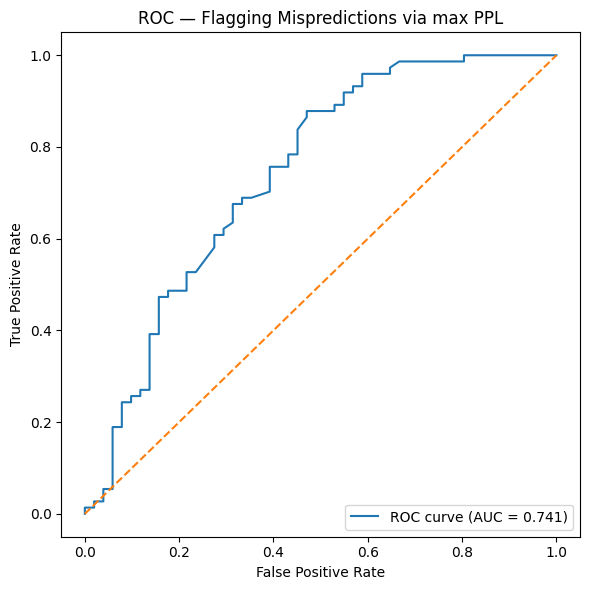

At best_thresh: TP=64, FP=24, FN=10, TN=27, Precision=0.7273, Recall=0.8649, F1=0.7901


In [26]:
# --- ROC curve & AUC (mispred = positive class) ---
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

y_true  = is_mispred.astype(int)   # 1 = mispredicted, 0 = correct
y_score = max_ppl.astype(float)    # continuous "risk" score

fpr, tpr, thresh = roc_curve(y_true, y_score, pos_label=1)
roc_auc = auc(fpr, tpr)
print(f"\nROC-AUC (mispred as positive): {roc_auc:.4f}")

# Optional: pick an operating point (Youden's J = TPR - FPR)
j_idx = np.argmax(tpr - fpr)
best_thresh = thresh[j_idx]
print(f"Best threshold by Youden's J: {best_thresh:.6f} | TPR={tpr[j_idx]:.3f}, FPR={fpr[j_idx]:.3f}")

# Plot
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — Flagging Mispredictions via max PPL")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# (Optional) Evaluate confusion metrics at the chosen threshold to match your table
def eval_at(th):
    mask = (y_score > th)
    TP = int(((mask == 1) & (y_true == 1)).sum())
    FP = int(((mask == 1) & (y_true == 0)).sum())
    FN = int(((mask == 0) & (y_true == 1)).sum())
    TN = int(((mask == 0) & (y_true == 0)).sum())
    prec = TP / (TP + FP) if (TP + FP) else 0.0
    rec  = TP / (TP + FN) if (TP + FN) else 0.0
    f1   = (2*prec*rec)/(prec+rec) if (prec+rec) else 0.0
    return TP, FP, FN, TN, prec, rec, f1

TP, FP, FN, TN, prec, rec, f1 = eval_at(best_thresh)
print(f"At best_thresh: TP={TP}, FP={FP}, FN={FN}, TN={TN}, Precision={prec:.4f}, Recall={rec:.4f}, F1={f1:.4f}")


=== Metrics at Selected Perplexity Thresholds ===
 Threshold (PPL > th)  TP  FP  FN  TN  Precision  Recall     F1
             1.000000  74  51   0   0     0.5920  1.0000 0.7437
             1.000100  68  29   6  22     0.7010  0.9189 0.7953
             1.000200  66  27   8  24     0.7097  0.8919 0.7904
             1.000300  66  27   8  24     0.7097  0.8919 0.7904
             1.000400  65  27   9  24     0.7065  0.8784 0.7831
             1.000500  65  24   9  27     0.7303  0.8784 0.7975
             1.000553  64  24  10  27     0.7273  0.8649 0.7901
             1.000600  64  24  10  27     0.7273  0.8649 0.7901
             1.000700  64  24  10  27     0.7273  0.8649 0.7901
             1.000800  61  23  13  28     0.7262  0.8243 0.7722
             1.000900  61  23  13  28     0.7262  0.8243 0.7722
             1.001000  59  23  15  28     0.7195  0.7973 0.7564


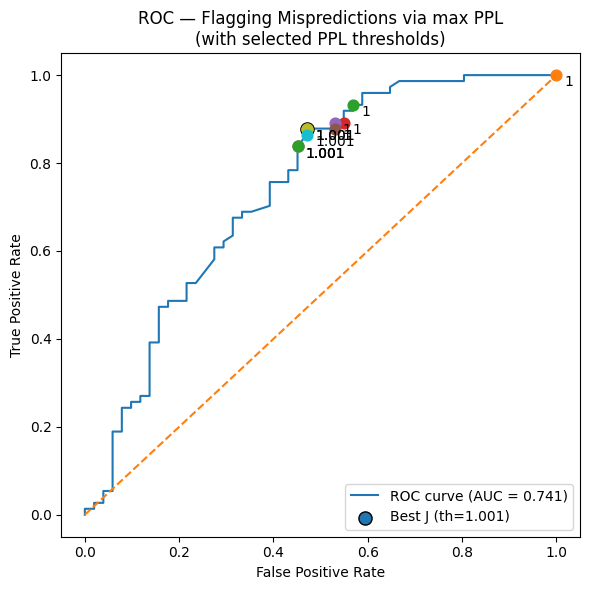

In [27]:
import pandas as pd
import numpy as np

# --- Choose thresholds to report/mark (include your table's values + best J) ---
chosen_ths = [1.00, 1.0001, 1.0002, 1.0003, 1.0004, 1.0005, 1.0006, 1.0007, 1.0008, 1.0009, 1.001]
# chosen_ths = [1.00, 1.0005, 1.001, 1.002, 1.003, 1.004, 1.005, 1.006, 1.007, 1.008, 1.009, 1.01, 1.02, 1.05]
chosen_ths.append(float(best_thresh))
chosen_ths = sorted(set(chosen_ths))

# --- Compute metrics at each chosen threshold ---
rows = []
for th in chosen_ths:
    TP, FP, FN, TN, prec, rec, f1 = eval_at(th)
    rows.append({
        "Threshold (PPL > th)": th,
        "TP": TP, "FP": FP, "FN": FN, "TN": TN,
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1": round(f1, 4),
    })

df_thresh = pd.DataFrame(rows)
print("\n=== Metrics at Selected Perplexity Thresholds ===")
print(df_thresh.to_string(index=False))

# --- Build a (fpr,tpr,threshold) DataFrame (filter out inf) for plotting helpers ---
roc_df = pd.DataFrame({"FPR": fpr, "TPR": tpr, "th": thresh})
roc_df = roc_df[np.isfinite(roc_df["th"])]

# --- Plot again with dots + labels for the chosen thresholds (nearest ROC points) ---
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")

# mark best J
plt.scatter([fpr[j_idx]], [tpr[j_idx]], s=90, marker="o", edgecolors="k", zorder=3,
            label=f"Best J (th={best_thresh:.4g})")

# mark selected thresholds
for th in chosen_ths:
    # find nearest ROC threshold index
    idx = int(np.argmin(np.abs(thresh - th)))
    x, y = fpr[idx], tpr[idx]
    plt.scatter([x], [y], s=60, zorder=3)
    plt.annotate(f"{th:.4g}", (x, y), textcoords="offset points", xytext=(6, -8))

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — Flagging Mispredictions via max PPL\n(with selected PPL thresholds)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


### Round 2 - (Train : 200, Test : 100)

In [ ]:
# === Batch 3-shot (k=3) few-shot labeling for 125 posts WITH per-label OUTPUT perplexity (no ground truth) ===
import pandas as pd, json, time, copy, re
from pathlib import Path

# -------- Paths --------
PERP_DIR        = Path("/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files")
PERP_DIR.mkdir(parents=True, exist_ok=True)

INPUT_CSV       = "/home/ubuntu/TW_MultiLabel_SMP/datasets/100_Round_1 - Final_Annotations.csv"  # your input posts
OUTPUT_CSV      = PERP_DIR / "predicted_labels_with_label_PPL_tr_200_te_100_k3.csv"   # single file you asked for
EXAMPLES_JSON   = "/home/ubuntu/TW_MultiLabel_SMP/used_examples/used_examples_for_tr_200_te_100_k3.json"        # optional traceability

YESNO_RE = re.compile(r"\b(YES|NO)\b", re.IGNORECASE)

# Use this label order exactly as requested
LABELS_ORDER = [
    "Abuse",
    "Aggression",
    "Sexual",
    "Medical",
    "Mental Health",
    "Discrimination",
    "Pregnancy",
    "Not Applicable",
]

def extract_yes_no(resp) -> str:
    """Coerce model output to YES/NO; accepts dicts and strings."""
    if resp is None:
        return "NO"
    if isinstance(resp, dict):
        if "text" in resp and isinstance(resp["text"], str):
            resp = resp["text"]
        elif "content" in resp and isinstance(resp["content"], str):
            resp = resp["content"]
        else:
            resp = str(resp)
    if not isinstance(resp, str):
        resp = str(resp)
    line = resp.strip().splitlines()[0] if resp.strip() else ""
    m = YESNO_RE.search(line)
    if m:
        return "YES" if m.group(1).upper() == "YES" else "NO"
    tok = line.upper().split()[:1]
    return "YES" if (tok and tok[0] == "YES") else "NO"

def tiny_throttle(sec=0.35):
    try:
        import time; time.sleep(sec)
    except Exception:
        pass

# --- load input posts ---
df_in = pd.read_csv(INPUT_CSV)
if not {'title','body'}.issubset(df_in.columns):
    raise KeyError("INPUT_CSV must contain 'title' and 'body' columns.")
subset = df_in.iloc[:125][['title','body']].fillna('').astype(str)

rows_out = []
all_used_examples = []   # snapshot of cosine-chosen neighbors for transparency

for i, (_, row) in enumerate(subset.iterrows(), start=1):
    title = row['title']
    body  = row['body']

    # Populate cosine neighbors (Cell 1); DOES NOT change the prompt text
    _ = make_multishot_prompt_cosine(
        k=3,
        title=title,
        body=body,
        current_index=None,
        include_defs=True,
        debug=False
    )

    yes_labels = []
    per_label_ppl = {}
    # collect per-label debug lines to print later
    per_label_lines = []

    for idx_lbl, lbl in enumerate(LABELS_ORDER, start=1):
        prompt = make_prompt_for_label(
            label_name=lbl,
            k=3,
            title=title,
            body=body,
            current_index=None,
            debug=False
        )

        # Call Cell 2 helper (returns token logprobs for the YES/NO answer)
        resp = getTriggerWarningsLLMResponse(
            prompt,
            mode="binary",
            max_tokens=4,     # enough for YES/NO; if splits happen, Cell 2's PPL_MODE="avg" handles it
            temperature=0.0,
            verbose=False
        )

        ans = extract_yes_no(resp)
        per_label_ppl[lbl] = float(resp.get("ppl", float("nan")))   # self-confidence PPL from output logprobs

        # One quick retry if malformed
        if ans not in ("YES", "NO"):
            resp2 = getTriggerWarningsLLMResponse(
                prompt,
                mode="binary",
                max_tokens=8,
                temperature=0.0,
                verbose=False
            )
            ans = extract_yes_no(resp2)
            per_label_ppl[lbl] = float(resp2.get("ppl", per_label_ppl[lbl]))

        if ans == "YES":
            yes_labels.append(lbl)

        # buffer the per-label heartbeat & result (we'll print after the summary)
        per_label_lines.append(f"[post {i}/125] label {idx_lbl}/8: {lbl}")
        dbg = (resp.get("text","") or "")[:120].replace("\n"," ")
        per_label_lines.append(f"Post {i}, Label '{lbl}': {dbg!r} -> {ans}, PPL_out={per_label_ppl[lbl]:.4f}")

        tiny_throttle(0.12)

    if not yes_labels:
        yes_labels = ["Not Applicable"]

    # ---- YES-only summary (first line you wanted) ----
    yes_ppl_items = []
    yes_ppl_values = []
    for lbl in yes_labels:
        v = per_label_ppl.get(lbl, float("nan"))
        yes_ppl_items.append(f"{lbl}:{(f'{v:.4f}' if (v==v) else 'NaN')}")
        if v == v:
            yes_ppl_values.append(v)

    mean_yes = (sum(yes_ppl_values)/len(yes_ppl_values)) if yes_ppl_values else float("nan")
    max_yes  = (max(yes_ppl_values))                      if yes_ppl_values else float("nan")
    mean_str = f"{mean_yes:.4f}" if (mean_yes==mean_yes) else "NaN"
    max_str  = f"{max_yes:.4f}"  if (max_yes==max_yes)   else "NaN"

    # 1) YES line
    print(f"{i}. YES labels: {yes_labels} | YES-PPLs[{', '.join(yes_ppl_items)}] |")

    # 2) banner
    print(f"=== Working on post {i}/125 ===")

    # 3) full per-label block
    for line in per_label_lines:
        print(line)

    # 4) tail stats
    print(f"meanPPL_yes={mean_str} | maxPPL_yes={max_str}")

    # ---- build output row for CSV ----
    out_row = {
        "title": title,
        "body": body,
        "PredictedLabels": json.dumps(yes_labels, ensure_ascii=False)
    }
    for lbl in LABELS_ORDER:
        out_row[f"PPL_{lbl}"] = per_label_ppl.get(lbl, float("nan"))
    rows_out.append(out_row)

    # keep examples snapshot for auditability
    snapshot = copy.deepcopy(collected_examples_per_label) if 'collected_examples_per_label' in globals() else {}
    all_used_examples.append({
        "post_index_1_based": i,
        "title": title,
        "body": body,
        "examples_by_label": snapshot
    })

# --- save single CSV with predicted labels + 8 per-label PPL columns ---
df_out = pd.DataFrame(rows_out)
df_out.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")
print(f"\n✅ Saved predicted labels + per-label OUTPUT PPL to {OUTPUT_CSV}")

# --- optional: save used examples JSON for traceability ---
with open(EXAMPLES_JSON, "w", encoding="utf-8") as f:
    json.dump(all_used_examples, f, indent=2, ensure_ascii=False)
print(f"✅ Saved used examples (cosine-picked) to {EXAMPLES_JSON}")


1. YES labels: ['Medical', 'Pregnancy'] | YES-PPLs[Medical:1.0000, Pregnancy:1.0041] |
=== Working on post 1/125 ===
[post 1/125] label 1/8: Abuse
Post 1, Label 'Abuse': 'NO' -> NO, PPL_out=1.0000
[post 1/125] label 2/8: Aggression
Post 1, Label 'Aggression': 'NO' -> NO, PPL_out=1.0000
[post 1/125] label 3/8: Sexual
Post 1, Label 'Sexual': 'NO' -> NO, PPL_out=1.0000
[post 1/125] label 4/8: Medical
Post 1, Label 'Medical': 'YES' -> YES, PPL_out=1.0000
[post 1/125] label 5/8: Mental Health
Post 1, Label 'Mental Health': 'NO' -> NO, PPL_out=1.3679
[post 1/125] label 6/8: Discrimination
Post 1, Label 'Discrimination': 'NO' -> NO, PPL_out=1.0000
[post 1/125] label 7/8: Pregnancy
Post 1, Label 'Pregnancy': 'YES' -> YES, PPL_out=1.0041
[post 1/125] label 8/8: Not Applicable
Post 1, Label 'Not Applicable': 'NO' -> NO, PPL_out=1.0000
meanPPL_yes=1.0021 | maxPPL_yes=1.0041
2. YES labels: ['Medical', 'Mental Health', 'Pregnancy'] | YES-PPLs[Medical:1.0000, Mental Health:1.0000, Pregnancy:1.0000] 

FileNotFoundError: [Errno 2] No such file or directory: '/home/ubuntu/used_examples/used_examples_for_tr_200_te_100_k3.json'

In [39]:
# Cell: Precision/Recall/F1 per post using GT "Tags" column (Ubuntu-friendly)
import os
import ast
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

INPUT_CSV  = "/home/ubuntu/TW_MultiLabel_SMP/datasets/100_Round_1 - Final_Annotations.csv"
OUTPUT_CSV = "/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/predicted_labels_with_label_PPL_tr_200_te_100_k3.csv"
SAVE_AS    = "/home/ubuntu/TW_MultiLabel_SMP/metrics/per_post_metrics_from_tr_200_te_100_tags_multishot_k_3_gpt.csv"

# ---- load data ----
gt_df   = pd.read_csv(INPUT_CSV)
pred_df = pd.read_csv(OUTPUT_CSV)

# align to first 75 rows (adjust if you want more)
gt_subset   = gt_df.head(125).reset_index(drop=True)
pred_subset = pred_df.head(125).reset_index(drop=True)

# ---- helpers ----
def parse_listish(value):
    """
    Parse labels that might be stored as python-list strings or comma-separated strings.
    Returns a set of normalized labels.
    """
    if pd.isna(value):
        return set()
    s = str(value).strip()
    # try python list literal first
    try:
        maybe_list = ast.literal_eval(s)
        if isinstance(maybe_list, (list, tuple)):
            items = maybe_list
        else:
            items = [s]
    except Exception:
        # fallback: comma-separated
        items = [tok.strip() for tok in s.split(",") if tok.strip()]
    # normalize labels (consistent spacing/case)
    return set([str(x).strip() for x in items if str(x).strip()])

# ---- parse labels ----
if "Tags" not in gt_subset.columns:
    raise KeyError("Ground truth CSV must contain a 'Tags' column with human-annotated labels.")

gt_labels_list   = gt_subset["Tags"].apply(parse_listish).tolist()
pred_labels_list = pred_subset["PredictedLabels"].apply(parse_listish).tolist()

# build label universe
all_labels = sorted(list(set().union(*gt_labels_list, *pred_labels_list)))

# ---- compute metrics ----
rows = []
y_true_all, y_pred_all = [], []

for idx, (gt_set, pred_set) in enumerate(zip(gt_labels_list, pred_labels_list), start=1):
    y_true = [1 if l in gt_set else 0 for l in all_labels]
    y_pred = [1 if l in pred_set else 0 for l in all_labels]

    y_true_all.extend(y_true)
    y_pred_all.extend(y_pred)

    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f = f1_score(y_true, y_pred, zero_division=0)

    rows.append({
        "PostIndex": idx,
        "TrueLabels": sorted(list(gt_set)),
        "PredictedLabels": sorted(list(pred_set)),
        "Precision": round(p, 3),
        "Recall": round(r, 3),
        "F1": round(f, 3),
    })

metrics_df = pd.DataFrame(rows)

# macro averages = mean of per-post metrics
macro_p = float(metrics_df["Precision"].mean())
macro_r = float(metrics_df["Recall"].mean())
macro_f = float(metrics_df["F1"].mean())

# micro averages = computed on pooled one-hot vectors
micro_p = precision_score(y_true_all, y_pred_all, zero_division=0)
micro_r = recall_score(y_true_all, y_pred_all, zero_division=0)
micro_f = f1_score(y_true_all, y_pred_all, zero_division=0)

summary_rows = pd.DataFrame([
    {"PostIndex": "Macro-Avg", "TrueLabels": None, "PredictedLabels": None,
     "Precision": round(macro_p, 3), "Recall": round(macro_r, 3), "F1": round(macro_f, 3)},
    {"PostIndex": "Micro-Avg", "TrueLabels": None, "PredictedLabels": None,
     "Precision": round(micro_p, 3), "Recall": round(micro_r, 3), "F1": round(micro_f, 3)},
])

final_metrics = pd.concat([metrics_df, summary_rows], ignore_index=True)

# ---- save (no /mnt/data, so always local) ----
final_metrics.to_csv(SAVE_AS, index=False, encoding="utf-8")
print(f"✅ Saved per-post metrics + macro/micro averages to: {os.path.abspath(SAVE_AS)}")


✅ Saved per-post metrics + macro/micro averages to: /home/ubuntu/TW_MultiLabel_SMP/metrics/per_post_metrics_from_tr_200_te_100_tags_multishot_k_3_gpt.csv


In [40]:
# K-3 metrics results 
import pandas as pd
import ast

# === Configure this to your file ===
CSV_PATH = "/home/ubuntu/TW_MultiLabel_SMP/metrics/per_post_metrics_from_tr_200_te_100_tags_multishot_k_3_gpt.csv"

def _safe_list(x):
    """Parse list-like strings into Python lists; return [] if parsing fails."""
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    s = str(x).strip()
    # try JSON-ish or Python literal list
    try:
        val = ast.literal_eval(s)
        if isinstance(val, list):
            return val
    except Exception:
        pass
    # fallback: comma-split
    return [t.strip() for t in s.split(",") if t.strip()]

def summarize_metrics(csv_path: str):
    df = pd.read_csv(csv_path)

    # Detect summary rows if present
    has_macro = (df["PostIndex"] == "Macro-Avg").any() if "PostIndex" in df.columns else False
    has_micro = (df["PostIndex"] == "Micro-Avg").any() if "PostIndex" in df.columns else False

    # Pull macro/micro if available, else compute from per-post rows
    macro_p = macro_r = macro_f = None
    micro_p = micro_r = micro_f = None

    if has_macro:
        row = df.loc[df["PostIndex"] == "Macro-Avg"].iloc[0]
        macro_p, macro_r, macro_f = float(row["Precision"]), float(row["Recall"]), float(row["F1"])
    if has_micro:
        row = df.loc[df["PostIndex"] == "Micro-Avg"].iloc[0]
        micro_p, micro_r, micro_f = float(row["Precision"]), float(row["Recall"]), float(row["F1"])

    # Filter per-post rows
    per_post = df.copy()
    if "PostIndex" in per_post.columns:
        per_post = per_post[~per_post["PostIndex"].isin(["Macro-Avg", "Micro-Avg"])]

    # Compute perfect/incorrect if we have labels
    perfect_matches = completely_incorrect = None
    if {"TrueLabels", "PredictedLabels"}.issubset(per_post.columns):
        t_labels = per_post["TrueLabels"].apply(_safe_list)
        p_labels = per_post["PredictedLabels"].apply(_safe_list)

        perfect_matches = sum(set(t) == set(p) for t, p in zip(t_labels, p_labels))
        completely_incorrect = sum(len(set(t).intersection(set(p))) == 0 for t, p in zip(t_labels, p_labels))
        n_posts = len(per_post)
    else:
        n_posts = len(per_post)

    # If macro/micro not present, approximate macro as mean of per-post, and skip micro
    if macro_p is None and {"Precision","Recall","F1"}.issubset(per_post.columns):
        macro_p = per_post["Precision"].mean()
        macro_r = per_post["Recall"].mean()
        macro_f = per_post["F1"].mean()

    # Pretty print in your requested format
    print("Here’s the summary you can share with your advisor:\n")
    if macro_p is not None:
        print(f"Macro Precision: {macro_p:.3f}")
        print(f"Macro Recall: {macro_r:.3f}")
        print(f"Macro F1: {macro_f:.3f}\n")
    else:
        print("Macro metrics: not available in this file.\n")

    if micro_p is not None:
        print(f"Micro Precision: {micro_p:.3f}")
        print(f"Micro Recall: {micro_r:.3f}")
        print(f"Micro F1: {micro_f:.3f}\n")
    else:
        print("Micro metrics: not available in this file.\n")

    if perfect_matches is not None:
        print(f"Perfect Matches: {perfect_matches} out of {n_posts} posts ({100*perfect_matches/n_posts:.1f}%) exactly matched human annotations")
    else:
        print("Perfect Matches: (labels not found in CSV to compute)")
    if completely_incorrect is not None:
        print(f"Completely Incorrect: {completely_incorrect} out of {n_posts} posts ({100*completely_incorrect/n_posts:.1f}%) had no correct labels")
    else:
        print("Completely Incorrect: (labels not found in CSV to compute)")

# Run
summarize_metrics(CSV_PATH)


Here’s the summary you can share with your advisor:

Macro Precision: 0.802
Macro Recall: 0.943
Macro F1: 0.844

Micro Precision: 0.782
Micro Recall: 0.944
Micro F1: 0.855

Perfect Matches: 48 out of 100 posts (48.0%) exactly matched human annotations
Completely Incorrect: 1 out of 100 posts (1.0%) had no correct labels


In [ ]:
# --- Threshold-based misprediction detection using PPL ---
import pandas as pd
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

# Load files
df_true = pd.read_csv("/home/ubuntu/TW_MultiLabel_SMP/datasets/100_Round_1 - Final_Annotations.csv")
df_pred = pd.read_csv("/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/predicted_labels_with_label_PPL_tr_200_te_100_k3.csv")

# Ensure column alignment
if "PredictedLabels" not in df_pred.columns:
    raise ValueError("Predictions file must contain 'PredictedLabels' column.")

# Parse ground truth: all 8 label columns (0/1)
label_cols = ["Abuse", "Aggression", "Sexual", "Medical", 
              "Mental Health", "Discrimination", "Pregnancy", "Not Applicable"]

def row_to_labelset(row):
    return [lbl for lbl in label_cols if row.get(lbl, 0) == 1]

# Ground truth sets
true_labels = [row_to_labelset(row) for _, row in df_true.iterrows()]

# Predicted sets
pred_labels = df_pred["PredictedLabels"].apply(lambda x: eval(x) if isinstance(x, str) else [])

# Identify mispredictions (row-wise)
is_mispred = [set(t) != set(p) for t, p in zip(true_labels, pred_labels)]

# Function to test thresholds
def eval_thresholds(df_pred, is_mispred, thresholds=np.arange(1.0, 1.15, 0.01)):
    results = []
    is_mispred = np.array(is_mispred, dtype=bool)  # ensure numpy array
    
    for t in thresholds:
        # Flag as suspect if any label PPL > threshold
        suspect = (df_pred[[c for c in df_pred.columns if c.startswith("PPL_")]].max(axis=1).values > t)
        
        # Compare with actual mispredictions
        TP = np.sum(suspect & is_mispred)
        FP = np.sum(suspect & ~is_mispred)
        FN = np.sum(~suspect & is_mispred)
        TN = np.sum(~suspect & ~is_mispred)
        
        precision = TP / (TP + FP) if (TP + FP) else 0.0
        recall    = TP / (TP + FN) if (TP + FN) else 0.0
        f1        = (2*precision*recall)/(precision+recall) if (precision+recall) else 0.0
        
        results.append({
            "threshold": round(t, 3),
            "TP": TP, "FP": FP, "FN": FN, "TN": TN,
            "precision": round(precision, 4),
            "recall": round(recall, 4),
            "f1": round(f1, 4)
        })
    return pd.DataFrame(results)

# Run evaluation
# Use 1.01 → 1.10 instead of starting at 1.00
results_df = eval_thresholds(df_pred, is_mispred, thresholds=np.arange(1.01, 1.11, 0.01))


# Show first few rows
print(results_df.head(10))

# Save to CSV for full inspection
results_df.to_csv("/home/ubuntu/Perplexity Files/threshold_eval_metrics_200.csv", index=False)
print("✅ Saved metrics to /home/ubuntu/Perplexity Files/threshold_eval_metrics_200.csv")

# Show best thresholds
best_f1 = results_df.loc[results_df["f1"].idxmax()]
best_recall = results_df.loc[results_df["recall"].idxmax()]
print("\n🏆 Best by F1:")
print(best_f1)

print("\n🔎 Best by Recall:")
print(best_recall)


   threshold  TP  FP  FN  TN  precision  recall      f1
0       1.01  49   0  51   0        1.0    0.49  0.6577
1       1.02  43   0  57   0        1.0    0.43  0.6014
2       1.03  42   0  58   0        1.0    0.42  0.5915
3       1.04  39   0  61   0        1.0    0.39  0.5612
4       1.05  34   0  66   0        1.0    0.34  0.5075
5       1.06  34   0  66   0        1.0    0.34  0.5075
6       1.07  28   0  72   0        1.0    0.28  0.4375
7       1.08  28   0  72   0        1.0    0.28  0.4375
8       1.09  25   0  75   0        1.0    0.25  0.4000
9       1.10  25   0  75   0        1.0    0.25  0.4000
✅ Saved metrics to /home/ubuntu/Perplexity Files/threshold_eval_metrics.csv

🏆 Best by F1:
threshold     1.0100
TP           49.0000
FP            0.0000
FN           51.0000
TN            0.0000
precision     1.0000
recall        0.4900
f1            0.6577
Name: 0, dtype: float64

🔎 Best by Recall:
threshold     1.0100
TP           49.0000
FP            0.0000
FN           51.000

In [42]:
# --- Combined bin analysis for PPL thresholds ---
import numpy as np

# Max PPL per post
max_ppl = df_pred[[c for c in df_pred.columns if c.startswith("PPL_")]].max(axis=1).values
is_mispred = np.array(is_mispred, dtype=bool)
total_mispred = is_mispred.sum()

def eval_combined(thresh, label):
    mask = (max_ppl > thresh)
    n_total = mask.sum()
    n_mispred = (mask & is_mispred).sum()
    precision = n_mispred / n_total if n_total > 0 else 0.0
    recall = n_mispred / total_mispred if total_mispred > 0 else 0.0
    f1 = (2*precision*recall)/(precision+recall) if (precision+recall) > 0 else 0.0
    return {
        "Bin": label,
        "Posts in bin": int(n_total),
        "Mispred in bin": int(n_mispred),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1": round(f1, 4)
    }

results = []
results.append(eval_combined(1.05, "Review (PPL > 1.05)"))
results.append(eval_combined(1.02, "Review (PPL > 1.02)"))

df_combined = pd.DataFrame(results)
print(df_combined)


                   Bin  Posts in bin  Mispred in bin  Precision  Recall  \
0  Review (PPL > 1.05)            34              34        1.0    0.34   
1  Review (PPL > 1.02)            43              43        1.0    0.43   

       F1  
0  0.5075  
1  0.6014  


In [43]:
# --- One-shot overall Precision / Recall / F1 for all 125 posts ---
import pandas as pd
import numpy as np
import json, ast

# Load
df_true = pd.read_csv("/home/ubuntu/TW_MultiLabel_SMP/datasets/100_Round_1 - Final_Annotations.csv")
df_pred = pd.read_csv("/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/predicted_labels_with_label_PPL_tr_200_te_100_k3.csv")

label_cols = ["Abuse", "Aggression", "Sexual", "Medical", 
              "Mental Health", "Discrimination", "Pregnancy", "Not Applicable"]

def row_to_labelset(row):
    return {lbl for lbl in label_cols if row.get(lbl, 0) == 1}

# Ground-truth sets
true_sets = [row_to_labelset(row) for _, row in df_true.iterrows()]

# Predicted sets (robust parse)
def parse_pred(s):
    if isinstance(s, list): 
        return set(s)
    if isinstance(s, str):
        s = s.strip()
        if not s:
            return set()
        try:
            return set(json.loads(s))
        except Exception:
            try:
                return set(ast.literal_eval(s))
            except Exception:
                return set()
    return set()

pred_sets = [parse_pred(s) for s in df_pred["PredictedLabels"]]

# Mispred flags (row-wise)
is_mispred = np.array([ts != ps for ts, ps in zip(true_sets, pred_sets)], dtype=bool)

# Max PPL per post
ppl_cols = [c for c in df_pred.columns if c.startswith("PPL_")]
max_ppl = df_pred[ppl_cols].max(axis=1).to_numpy(dtype=float)

# ---- choose your single threshold here ----
THRESHOLD = 1.02  # change if you want

# Suspect if any label's output-PPL exceeds threshold
suspect = (max_ppl > THRESHOLD)

# Confusion matrix
TP = int(np.sum(suspect & is_mispred))
FP = int(np.sum(suspect & ~is_mispred))
FN = int(np.sum(~suspect & is_mispred))
TN = int(np.sum(~suspect & ~is_mispred))

precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
f1        = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

print("=== Overall Evaluation (All 125 posts) ===")
print(f"Threshold: PPL > {THRESHOLD:.3f}")
print(f"TP: {TP}, FP: {FP}, FN: {FN}, TN: {TN}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")

# (optional) also show coverage
print(f"\nFlagged (suspect) posts: {int(suspect.sum())} / {len(suspect)}")
print(f"Mispredicted posts: {int(is_mispred.sum())} / {len(is_mispred)}")

=== Overall Evaluation (All 125 posts) ===
Threshold: PPL > 1.020
TP: 43, FP: 0, FN: 57, TN: 0
Precision: 1.0000
Recall:    0.4300
F1:        0.6014

Flagged (suspect) posts: 43 / 100
Mispredicted posts: 100 / 100


In [44]:
import pandas as pd, numpy as np, ast, re

TRUE_PATH = "/home/ubuntu/TW_MultiLabel_SMP/datasets/100_Round_1 - Final_Annotations.csv"
PRED_PATH = "/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/predicted_labels_with_label_PPL_tr_200_te_100_k3.csv"

CANON_LABELS = [
    "Abuse",
    "Aggression",
    "Sexual",
    "Medical",
    "Mental Health",
    "Discrimination",
    "Pregnancy",
    "Not Applicable",
]

def norm_key_text(s):
    s = "" if pd.isna(s) else str(s)
    s = s.lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s

def norm_name(s: str) -> str:
    return re.sub(r"[^a-z0-9]+", "", str(s).strip().lower())

# map many variants to canonical labels
NORM_TO_CANON = {
    norm_name("abuse"): "Abuse",
    norm_name("aggression"): "Aggression",
    norm_name("sexual"): "Sexual",
    norm_name("medical"): "Medical",
    norm_name("mentalhealth"): "Mental Health",
    norm_name("mental health"): "Mental Health",
    norm_name("discrimination"): "Discrimination",
    norm_name("pregnancy"): "Pregnancy",
    norm_name("notapplicable"): "Not Applicable",
    norm_name("na"): "Not Applicable",
    norm_name("none"): "Not Applicable",
}

def to_canonical_label(s):
    key = norm_name(s)
    return NORM_TO_CANON.get(key, None)

def parse_listlike(text):
    """Parse list-like strings safely; fall back to splitting by , ; | / if needed."""
    if isinstance(text, list):
        return [str(t).strip() for t in text]
    if pd.isna(text):
        return []
    s = str(text).strip()
    # Try literal_eval first (handles "['A','B']" or '["A","B"]')
    try:
        v = ast.literal_eval(s)
        if isinstance(v, list):
            return [str(t).strip() for t in v]
        if isinstance(v, str):
            s = v  # fall through to split
    except Exception:
        pass
    # Strip surrounding brackets if present
    s = s.strip("[]()")
    # Split on common separators
    parts = re.split(r"[,\|;/]", s)
    return [p.strip() for p in parts if p.strip()]

def parse_gt_tags_to_set(val):
    raw = parse_listlike(val)
    out = []
    for item in raw:
        can = to_canonical_label(item)
        if can:
            out.append(can)
    # if “Tags” might be a single string label like "Medical"
    if not out and isinstance(val, str) and val.strip():
        can = to_canonical_label(val)
        if can:
            out = [can]
    return set(out)

def parse_pred_list_to_set(val):
    raw = parse_listlike(val)
    out = []
    for item in raw:
        can = to_canonical_label(item)
        if can:
            out.append(can)
        else:
            # If predictions are already canonical, keep as-is
            if item in CANON_LABELS:
                out.append(item)
    return set(out)

# ---- Load
df_true = pd.read_csv(TRUE_PATH)
df_pred = pd.read_csv(PRED_PATH)

# normalize columns
df_true.columns = [c.strip() for c in df_true.columns]
df_pred.columns = [c.strip() for c in df_pred.columns]

# ---- Build join key (prefer id if in both; else title+body)
id_cols = [c for c in ["id","ID","post_id","PostID","Index"] if c in df_true.columns and c in df_pred.columns]
if id_cols:
    keycol = id_cols[0]
    df_true["_key"] = df_true[keycol]
    df_pred["_key"] = df_pred[keycol]
else:
    df_true["_key"] = df_true.get("title","").apply(norm_key_text) + " || " + df_true.get("body","").apply(norm_key_text)
    df_pred["_key"] = df_pred.get("title","").apply(norm_key_text) + " || " + df_pred.get("body","").apply(norm_key_text)

df_true = df_true.drop_duplicates("_key")
df_pred = df_pred.drop_duplicates("_key")

merged = df_pred.merge(df_true, on="_key", how="inner", suffixes=("_pred","_true"))
print(f"[Info] Rows — pred: {len(df_pred)}, true: {len(df_true)}, merged: {len(merged)}")

# ---- Extract GT label sets from 'Tags'
if "Tags" not in merged.columns:
    raise RuntimeError("Ground-truth file must contain a 'Tags' column (list or delimited string of labels).")

true_sets = merged["Tags"].apply(parse_gt_tags_to_set)

# ---- Extract predicted label sets from 'PredictedLabels'
if "PredictedLabels" not in merged.columns:
    raise RuntimeError("Predictions file must contain 'PredictedLabels' column.")

pred_sets = merged["PredictedLabels"].apply(parse_pred_list_to_set)

# ---- Compare
is_correct = (pred_sets == true_sets)
n_total = len(is_correct)
n_correct = int(is_correct.sum())
n_mispred = n_total - n_correct
acc = n_correct / n_total if n_total else 0.0

print("\n=== Ground Truth Evaluation (Aligned rows) ===")
print(f"Total compared:       {n_total}")
print(f"Correct predictions:  {n_correct}")
print(f"Mispredicted:         {n_mispred}")
print(f"Accuracy:             {acc:.4f}")

# Optional: quick peek at a few mismatches
if n_correct < n_total:
    debug = pd.DataFrame({
        "GT": true_sets.apply(lambda s: sorted(list(s))),
        "Pred": pred_sets.apply(lambda s: sorted(list(s)))
    })
    print("\n[Debug] Sample mismatches (first 5):")
    print(debug[debug["GT"] != debug["Pred"]].head(5).to_string(index=False))


[Info] Rows — pred: 100, true: 100, merged: 100

=== Ground Truth Evaluation (Aligned rows) ===
Total compared:       100
Correct predictions:  48
Mispredicted:         52
Accuracy:             0.4800

[Debug] Sample mismatches (first 5):
                                 GT                                                   Pred
           [Medical, Mental Health]                             [Mental Health, Pregnancy]
                        [Pregnancy]                    [Medical, Mental Health, Pregnancy]
[Medical, Mental Health, Pregnancy]    [Discrimination, Medical, Mental Health, Pregnancy]
         [Mental Health, Pregnancy]    [Discrimination, Medical, Mental Health, Pregnancy]
               [Medical, Pregnancy] [Abuse, Aggression, Medical, Mental Health, Pregnancy]


In [45]:
# --- Combined evaluation for 100_Round_1 files (handles Tags OR one-hot GT) ---
import pandas as pd, numpy as np, ast, re

TRUE_PATH = "/home/ubuntu/TW_MultiLabel_SMP/datasets/100_Round_1 - Final_Annotations.csv"
PRED_PATH = "/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/predicted_labels_with_label_PPL_tr_200_te_100_k3.csv"

CANON_LABELS = [
    "Abuse","Aggression","Sexual","Medical",
    "Mental Health","Discrimination","Pregnancy","Not Applicable"
]

def norm_key_text(s):
    s = "" if pd.isna(s) else str(s)
    s = s.lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s

def norm_name(s: str) -> str:
    return re.sub(r"[^a-z0-9]+", "", str(s).strip().lower())

NORM_TO_CANON = {
    norm_name("abuse"): "Abuse",
    norm_name("aggression"): "Aggression",
    norm_name("sexual"): "Sexual",
    norm_name("medical"): "Medical",
    norm_name("mentalhealth"): "Mental Health",
    norm_name("mental health"): "Mental Health",
    norm_name("discrimination"): "Discrimination",
    norm_name("pregnancy"): "Pregnancy",
    norm_name("notapplicable"): "Not Applicable",
    norm_name("na"): "Not Applicable",
    norm_name("none"): "Not Applicable",
}

def to_canonical_label(s):
    key = norm_name(s)
    return NORM_TO_CANON.get(key, None)

def parse_listlike(text):
    """Parse list-like strings safely; fall back to splitting by , ; | / if needed."""
    if isinstance(text, list):
        return [str(t).strip() for t in text]
    if pd.isna(text):
        return []
    s = str(text).strip()
    try:
        v = ast.literal_eval(s)     # handles "['A','B']" or '["A","B"]'
        if isinstance(v, list):
            return [str(t).strip() for t in v]
        if isinstance(v, str):
            s = v
    except Exception:
        pass
    s = s.strip("[]()")
    parts = re.split(r"[,\|;/]", s)
    return [p.strip() for p in parts if p.strip()]

def parse_pred_list_to_set(val):
    raw = parse_listlike(val)
    out = []
    for item in raw:
        can = to_canonical_label(item)
        if can:
            out.append(can)
        elif item in CANON_LABELS:   # already canonical
            out.append(item)
    return set(out)

def truthy(val) -> bool:
    s = str(val).strip().lower()
    if s in {"1","true","yes","y","t","x","✓","✔","1.0"}:
        return True
    try:
        return float(s) > 0
    except:
        return False

# ---------- load ----------
df_true = pd.read_csv(TRUE_PATH)
df_pred = pd.read_csv(PRED_PATH)
df_true.columns = [c.strip() for c in df_true.columns]
df_pred.columns = [c.strip() for c in df_pred.columns]

# ---------- align rows (prefer id; else title+body) ----------
id_cols = [c for c in ["id","ID","post_id","PostID","Index"] if c in df_true.columns and c in df_pred.columns]
if id_cols:
    keycol = id_cols[0]
    df_true["_key"] = df_true[keycol]
    df_pred["_key"] = df_pred[keycol]
else:
    df_true["_key"] = df_true.get("title","").apply(norm_key_text) + " || " + df_true.get("body","").apply(norm_key_text)
    df_pred["_key"] = df_pred.get("title","").apply(norm_key_text) + " || " + df_pred.get("body","").apply(norm_key_text)

df_true = df_true.drop_duplicates("_key")
df_pred = df_pred.drop_duplicates("_key")
merged = df_pred.merge(df_true, on="_key", how="inner", suffixes=("_pred","_true"))
print(f"[Info] Rows — pred: {len(df_pred)}, true: {len(df_true)}, merged: {len(merged)}")

# ---------- build ground-truth label sets (supports Tags OR one-hot) ----------
label_cols_present = [lab for lab in CANON_LABELS if lab in merged.columns]
use_one_hot = (len(label_cols_present) >= 3)  # heuristic: if many of the 8 exist, treat as one-hot

def gt_row_to_set(row):
    if "Tags" in merged.columns and not use_one_hot:
        # Tags route
        raw = parse_listlike(row["Tags"])
        out = []
        for item in raw:
            can = to_canonical_label(item)
            if can:
                out.append(can)
        # fallback for single string tag
        if not out and isinstance(row["Tags"], str) and row["Tags"].strip():
            can = to_canonical_label(row["Tags"])
            if can:
                out = [can]
        return set(out)
    else:
        # one-hot route
        labs = []
        for lab in CANON_LABELS:
            if lab in row.index:
                val = row[lab]
                if truthy(val):
                    labs.append(lab)
        return set(labs)

true_sets = merged.apply(gt_row_to_set, axis=1)

# ---------- predicted label sets ----------
if "PredictedLabels" not in merged.columns:
    raise RuntimeError("Predictions file must contain 'PredictedLabels' column.")
pred_sets = merged["PredictedLabels"].apply(parse_pred_list_to_set)

# ---------- exact-set correctness ----------
is_mispred = np.array([t != p for t, p in zip(true_sets, pred_sets)], dtype=bool)
n_total = len(is_mispred)
n_corr = int((~is_mispred).sum())
n_wrong = int(is_mispred.sum())
acc = n_corr / n_total if n_total else 0.0

print("\n=== Ground Truth Accuracy (exact set match) ===")
print(f"Total compared:       {n_total}")
print(f"Correct predictions:  {n_corr}")
print(f"Mispredicted:         {n_wrong}")
print(f"Accuracy:             {acc:.4f}")

# ---------- max PPL per post ----------
ppl_cols = [c for c in merged.columns if c.startswith("PPL_")]
if not ppl_cols:
    raise RuntimeError("Predictions file must include PPL_* columns.")
max_ppl = merged[ppl_cols].max(axis=1).values

# ---------- combined review metrics (advisor definition) ----------
def eval_combined(thresh, label):
    mask = (max_ppl > thresh)                 # posts flagged by PPL
    n_total_flagged = int(mask.sum())
    TP = int((mask & is_mispred).sum())       # flagged & actually wrong
    FP = int((mask & ~is_mispred).sum())      # flagged but correct
    FN = int((~mask & is_mispred).sum())      # not flagged but wrong
    TN = int((~mask & ~is_mispred).sum())     # not flagged & correct

    precision = (TP / (TP + FP)) if (TP + FP) > 0 else 0.0
    recall    = (TP / (TP + FN)) if (TP + FN) > 0 else 0.0
    f1        = (2*precision*recall)/(precision+recall) if (precision+recall) > 0 else 0.0

    return {
        "Bin": label,
        "Threshold rule": f"PPL > {thresh}",
        "Posts flagged": n_total_flagged,
        "TP": TP,
        "FP": FP,
        "FN": FN,
        "TN": TN,
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1": round(f1, 4),
    }

results = [
    eval_combined(1.05, "Review (Noticeable + Flag)"),
    eval_combined(1.02, "Review (Mild + Noticeable + Flag)"),
    eval_combined(1.01, "Review (Mild + Noticeable + Flag)"),
    eval_combined(1.012, "Review (Mild + Noticeable + Flag)"),
    eval_combined(1.013, "Review (Mild + Noticeable + Flag)"),
    eval_combined(1.014, "Review (Mild + Noticeable + Flag)"),
    eval_combined(1.0141, "Review (Mild + Noticeable + Flag)"),
    eval_combined(1.0142, "Review (Mild + Noticeable + Flag)"),
    eval_combined(1.01425, "Review (Mild + Noticeable + Flag)"),
    eval_combined(1.0143, "Review (Mild + Noticeable + Flag)"),
    eval_combined(1.0144, "Review (Mild + Noticeable + Flag)"),
    eval_combined(1.0145, "Review (Mild + Noticeable + Flag)"),
    eval_combined(1.015, "Review (Mild + Noticeable + Flag)"),
    eval_combined(1.016, "Review (Mild + Noticeable + Flag)"),
    eval_combined(1.001, "Review (Mild + Noticeable + Flag)"),
    eval_combined(1.0005, "Review (Mild + Noticeable + Flag)"),
    eval_combined(1.00, "Review (Mild + Noticeable + Flag)")
]

df_combined = pd.DataFrame(results)
print("\n=== Combined Review Metrics ===")
print(df_combined.to_string(index=False))


[Info] Rows — pred: 100, true: 100, merged: 100

=== Ground Truth Accuracy (exact set match) ===
Total compared:       100
Correct predictions:  48
Mispredicted:         52
Accuracy:             0.4800

=== Combined Review Metrics ===
                              Bin Threshold rule  Posts flagged  TP  FP  FN  TN  Precision  Recall     F1
       Review (Noticeable + Flag)     PPL > 1.05             34  20  14  32  34     0.5882  0.3846 0.4651
Review (Mild + Noticeable + Flag)     PPL > 1.02             43  28  15  24  33     0.6512  0.5385 0.5895
Review (Mild + Noticeable + Flag)     PPL > 1.01             49  33  16  19  32     0.6735  0.6346 0.6535
Review (Mild + Noticeable + Flag)    PPL > 1.012             48  32  16  20  32     0.6667  0.6154 0.6400
Review (Mild + Noticeable + Flag)    PPL > 1.013             48  32  16  20  32     0.6667  0.6154 0.6400
Review (Mild + Noticeable + Flag)    PPL > 1.014             48  32  16  20  32     0.6667  0.6154 0.6400
Review (Mild + Noticeab


ROC-AUC (mispred as positive): 0.6619
Best threshold by Youden's J: 1.002479 | TPR=0.750, FPR=0.396


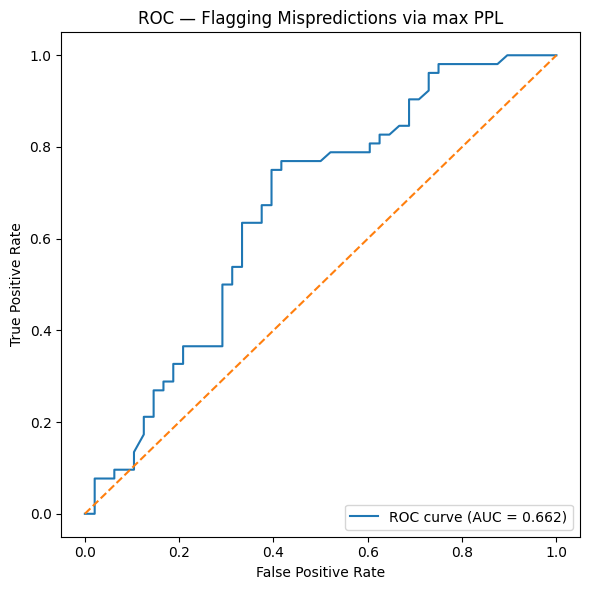

At best_thresh: TP=38, FP=19, FN=14, TN=29, Precision=0.6667, Recall=0.7308, F1=0.6972


In [46]:
# --- ROC curve & AUC (mispred = positive class) ---
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

y_true  = is_mispred.astype(int)   # 1 = mispredicted, 0 = correct
y_score = max_ppl.astype(float)    # continuous "risk" score

fpr, tpr, thresh = roc_curve(y_true, y_score, pos_label=1)
roc_auc = auc(fpr, tpr)
print(f"\nROC-AUC (mispred as positive): {roc_auc:.4f}")

# Optional: pick an operating point (Youden's J = TPR - FPR)
j_idx = np.argmax(tpr - fpr)
best_thresh = thresh[j_idx]
print(f"Best threshold by Youden's J: {best_thresh:.6f} | TPR={tpr[j_idx]:.3f}, FPR={fpr[j_idx]:.3f}")

# Plot
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — Flagging Mispredictions via max PPL")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# (Optional) Evaluate confusion metrics at the chosen threshold to match your table
def eval_at(th):
    mask = (y_score > th)
    TP = int(((mask == 1) & (y_true == 1)).sum())
    FP = int(((mask == 1) & (y_true == 0)).sum())
    FN = int(((mask == 0) & (y_true == 1)).sum())
    TN = int(((mask == 0) & (y_true == 0)).sum())
    prec = TP / (TP + FP) if (TP + FP) else 0.0
    rec  = TP / (TP + FN) if (TP + FN) else 0.0
    f1   = (2*prec*rec)/(prec+rec) if (prec+rec) else 0.0
    return TP, FP, FN, TN, prec, rec, f1

TP, FP, FN, TN, prec, rec, f1 = eval_at(best_thresh)
print(f"At best_thresh: TP={TP}, FP={FP}, FN={FN}, TN={TN}, Precision={prec:.4f}, Recall={rec:.4f}, F1={f1:.4f}")


=== Metrics at Selected Perplexity Thresholds ===
 Threshold (PPL > th)  TP  FP  FN  TN  Precision  Recall     F1
             1.000000  52  48   0   0     0.5200  1.0000 0.6842
             1.000100  43  31   9  17     0.5811  0.8269 0.6825
             1.000200  43  30   9  18     0.5890  0.8269 0.6880
             1.000300  41  29  11  19     0.5857  0.7885 0.6721
             1.000400  41  27  11  21     0.6029  0.7885 0.6833
             1.000500  41  26  11  22     0.6119  0.7885 0.6891
             1.000600  40  24  12  24     0.6250  0.7692 0.6897
             1.000700  40  24  12  24     0.6250  0.7692 0.6897
             1.000800  40  23  12  25     0.6349  0.7692 0.6957
             1.000900  40  23  12  25     0.6349  0.7692 0.6957
             1.001000  40  21  12  27     0.6557  0.7692 0.7080
             1.002479  38  19  14  29     0.6667  0.7308 0.6972


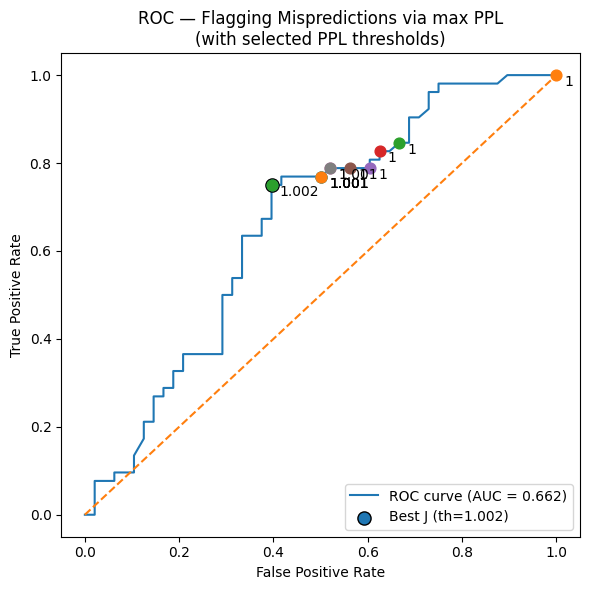

In [47]:
import pandas as pd
import numpy as np

# --- Choose thresholds to report/mark (include your table's values + best J) ---
chosen_ths = [1.00, 1.0001, 1.0002, 1.0003, 1.0004, 1.0005, 1.0006, 1.0007, 1.0008, 1.0009, 1.001]
# chosen_ths = [1.00, 1.0005, 1.001, 1.002, 1.003, 1.004, 1.005, 1.006, 1.007, 1.008, 1.009, 1.01, 1.02, 1.05]
chosen_ths.append(float(best_thresh))
chosen_ths = sorted(set(chosen_ths))

# --- Compute metrics at each chosen threshold ---
rows = []
for th in chosen_ths:
    TP, FP, FN, TN, prec, rec, f1 = eval_at(th)
    rows.append({
        "Threshold (PPL > th)": th,
        "TP": TP, "FP": FP, "FN": FN, "TN": TN,
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1": round(f1, 4),
    })

df_thresh = pd.DataFrame(rows)
print("\n=== Metrics at Selected Perplexity Thresholds ===")
print(df_thresh.to_string(index=False))

# --- Build a (fpr,tpr,threshold) DataFrame (filter out inf) for plotting helpers ---
roc_df = pd.DataFrame({"FPR": fpr, "TPR": tpr, "th": thresh})
roc_df = roc_df[np.isfinite(roc_df["th"])]

# --- Plot again with dots + labels for the chosen thresholds (nearest ROC points) ---
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")

# mark best J
plt.scatter([fpr[j_idx]], [tpr[j_idx]], s=90, marker="o", edgecolors="k", zorder=3,
            label=f"Best J (th={best_thresh:.4g})")

# mark selected thresholds
for th in chosen_ths:
    # find nearest ROC threshold index
    idx = int(np.argmin(np.abs(thresh - th)))
    x, y = fpr[idx], tpr[idx]
    plt.scatter([x], [y], s=60, zorder=3)
    plt.annotate(f"{th:.4g}", (x, y), textcoords="offset points", xytext=(6, -8))

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — Flagging Mispredictions via max PPL\n(with selected PPL thresholds)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


### Round 3 - (Train : 300, Test : 100)

In [55]:
# === Batch 3-shot (k=3) few-shot labeling for 125 posts WITH per-label OUTPUT perplexity (no ground truth) ===
import pandas as pd, json, time, copy, re
from pathlib import Path

# -------- Paths --------
PERP_DIR        = Path("/home/ubuntu//TW_MultiLabel_SMP/Perplexity Files")
PERP_DIR.mkdir(parents=True, exist_ok=True)

INPUT_CSV       = "/home/ubuntu/TW_MultiLabel_SMP/datasets/100_Round_2 - Final_Annotations.csv"  # your input posts
OUTPUT_CSV      = PERP_DIR / "predicted_labels_with_label_PPL_tr_300_te_100_k3.csv"   # single file you asked for
EXAMPLES_JSON   = "/home/ubuntu/used_examples/used_examples_for_tr_300_te_100_k3.json"        # optional traceability

YESNO_RE = re.compile(r"\b(YES|NO)\b", re.IGNORECASE)

# Use this label order exactly as requested
LABELS_ORDER = [
    "Abuse",
    "Aggression",
    "Sexual",
    "Medical",
    "Mental Health",
    "Discrimination",
    "Pregnancy",
    "Not Applicable",
]

def extract_yes_no(resp) -> str:
    """Coerce model output to YES/NO; accepts dicts and strings."""
    if resp is None:
        return "NO"
    if isinstance(resp, dict):
        if "text" in resp and isinstance(resp["text"], str):
            resp = resp["text"]
        elif "content" in resp and isinstance(resp["content"], str):
            resp = resp["content"]
        else:
            resp = str(resp)
    if not isinstance(resp, str):
        resp = str(resp)
    line = resp.strip().splitlines()[0] if resp.strip() else ""
    m = YESNO_RE.search(line)
    if m:
        return "YES" if m.group(1).upper() == "YES" else "NO"
    tok = line.upper().split()[:1]
    return "YES" if (tok and tok[0] == "YES") else "NO"

def tiny_throttle(sec=0.35):
    try:
        import time; time.sleep(sec)
    except Exception:
        pass

# --- load input posts ---
df_in = pd.read_csv(INPUT_CSV)
if not {'title','body'}.issubset(df_in.columns):
    raise KeyError("INPUT_CSV must contain 'title' and 'body' columns.")
subset = df_in.iloc[:125][['title','body']].fillna('').astype(str)

rows_out = []
all_used_examples = []   # snapshot of cosine-chosen neighbors for transparency

for i, (_, row) in enumerate(subset.iterrows(), start=1):
    title = row['title']
    body  = row['body']

    # Populate cosine neighbors (Cell 1); DOES NOT change the prompt text
    _ = make_multishot_prompt_cosine(
        k=3,
        title=title,
        body=body,
        current_index=None,
        include_defs=True,
        debug=False
    )

    yes_labels = []
    per_label_ppl = {}
    # collect per-label debug lines to print later
    per_label_lines = []

    for idx_lbl, lbl in enumerate(LABELS_ORDER, start=1):
        prompt = make_prompt_for_label(
            label_name=lbl,
            k=3,
            title=title,
            body=body,
            current_index=None,
            debug=False
        )

        # Call Cell 2 helper (returns token logprobs for the YES/NO answer)
        resp = getTriggerWarningsLLMResponse(
            prompt,
            mode="binary",
            max_tokens=4,     # enough for YES/NO; if splits happen, Cell 2's PPL_MODE="avg" handles it
            temperature=0.0,
            verbose=False
        )

        ans = extract_yes_no(resp)
        per_label_ppl[lbl] = float(resp.get("ppl", float("nan")))   # self-confidence PPL from output logprobs

        # One quick retry if malformed
        if ans not in ("YES", "NO"):
            resp2 = getTriggerWarningsLLMResponse(
                prompt,
                mode="binary",
                max_tokens=8,
                temperature=0.0,
                verbose=False
            )
            ans = extract_yes_no(resp2)
            per_label_ppl[lbl] = float(resp2.get("ppl", per_label_ppl[lbl]))

        if ans == "YES":
            yes_labels.append(lbl)

        # buffer the per-label heartbeat & result (we'll print after the summary)
        per_label_lines.append(f"[post {i}/125] label {idx_lbl}/8: {lbl}")
        dbg = (resp.get("text","") or "")[:120].replace("\n"," ")
        per_label_lines.append(f"Post {i}, Label '{lbl}': {dbg!r} -> {ans}, PPL_out={per_label_ppl[lbl]:.4f}")

        tiny_throttle(0.12)

    if not yes_labels:
        yes_labels = ["Not Applicable"]

    # ---- YES-only summary (first line you wanted) ----
    yes_ppl_items = []
    yes_ppl_values = []
    for lbl in yes_labels:
        v = per_label_ppl.get(lbl, float("nan"))
        yes_ppl_items.append(f"{lbl}:{(f'{v:.4f}' if (v==v) else 'NaN')}")
        if v == v:
            yes_ppl_values.append(v)

    mean_yes = (sum(yes_ppl_values)/len(yes_ppl_values)) if yes_ppl_values else float("nan")
    max_yes  = (max(yes_ppl_values))                      if yes_ppl_values else float("nan")
    mean_str = f"{mean_yes:.4f}" if (mean_yes==mean_yes) else "NaN"
    max_str  = f"{max_yes:.4f}"  if (max_yes==max_yes)   else "NaN"

    # 1) YES line
    print(f"{i}. YES labels: {yes_labels} | YES-PPLs[{', '.join(yes_ppl_items)}] |")

    # 2) banner
    print(f"=== Working on post {i}/125 ===")

    # 3) full per-label block
    for line in per_label_lines:
        print(line)

    # 4) tail stats
    print(f"meanPPL_yes={mean_str} | maxPPL_yes={max_str}")

    # ---- build output row for CSV ----
    out_row = {
        "title": title,
        "body": body,
        "PredictedLabels": json.dumps(yes_labels, ensure_ascii=False)
    }
    for lbl in LABELS_ORDER:
        out_row[f"PPL_{lbl}"] = per_label_ppl.get(lbl, float("nan"))
    rows_out.append(out_row)

    # keep examples snapshot for auditability
    snapshot = copy.deepcopy(collected_examples_per_label) if 'collected_examples_per_label' in globals() else {}
    all_used_examples.append({
        "post_index_1_based": i,
        "title": title,
        "body": body,
        "examples_by_label": snapshot
    })

# --- save single CSV with predicted labels + 8 per-label PPL columns ---
df_out = pd.DataFrame(rows_out)
df_out.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")
print(f"\n✅ Saved predicted labels + per-label OUTPUT PPL to {OUTPUT_CSV}")

# --- optional: save used examples JSON for traceability ---
with open(EXAMPLES_JSON, "w", encoding="utf-8") as f:
    json.dump(all_used_examples, f, indent=2, ensure_ascii=False)
print(f"✅ Saved used examples (cosine-picked) to {EXAMPLES_JSON}")


1. YES labels: ['Mental Health', 'Pregnancy'] | YES-PPLs[Mental Health:1.0000, Pregnancy:1.0000] |
=== Working on post 1/125 ===
[post 1/125] label 1/8: Abuse
Post 1, Label 'Abuse': 'NO' -> NO, PPL_out=1.0000
[post 1/125] label 2/8: Aggression
Post 1, Label 'Aggression': 'NO' -> NO, PPL_out=1.0000
[post 1/125] label 3/8: Sexual
Post 1, Label 'Sexual': 'NO' -> NO, PPL_out=1.0000
[post 1/125] label 4/8: Medical
Post 1, Label 'Medical': 'NO' -> NO, PPL_out=1.0000
[post 1/125] label 5/8: Mental Health
Post 1, Label 'Mental Health': 'YES' -> YES, PPL_out=1.0000
[post 1/125] label 6/8: Discrimination
Post 1, Label 'Discrimination': 'NO' -> NO, PPL_out=1.0000
[post 1/125] label 7/8: Pregnancy
Post 1, Label 'Pregnancy': 'YES' -> YES, PPL_out=1.0000
[post 1/125] label 8/8: Not Applicable
Post 1, Label 'Not Applicable': 'NO' -> NO, PPL_out=1.0000
meanPPL_yes=1.0000 | maxPPL_yes=1.0000
2. YES labels: ['Medical', 'Mental Health', 'Pregnancy'] | YES-PPLs[Medical:1.0067, Mental Health:1.0000, Pregna

In [56]:
# Round 3 Cell: Precision/Recall/F1 per post using GT "Tags" column (Ubuntu-friendly)
import os
import ast
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

INPUT_CSV  = "/home/ubuntu/TW_MultiLabel_SMP/datasets/100_Round_2 - Final_Annotations.csv"
OUTPUT_CSV = "/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/predicted_labels_with_label_PPL_tr_300_te_100_k3.csv"
SAVE_AS    = "/home/ubuntu/TW_MultiLabel_SMP/metrics/per_post_metrics_from_tr_300_te_100_tags_multishot_k_3_gpt.csv"

# ---- load data ----
gt_df   = pd.read_csv(INPUT_CSV)
pred_df = pd.read_csv(OUTPUT_CSV)

# align to first 75 rows (adjust if you want more)
gt_subset   = gt_df.head(125).reset_index(drop=True)
pred_subset = pred_df.head(125).reset_index(drop=True)

# ---- helpers ----
def parse_listish(value):
    """
    Parse labels that might be stored as python-list strings or comma-separated strings.
    Returns a set of normalized labels.
    """
    if pd.isna(value):
        return set()
    s = str(value).strip()
    # try python list literal first
    try:
        maybe_list = ast.literal_eval(s)
        if isinstance(maybe_list, (list, tuple)):
            items = maybe_list
        else:
            items = [s]
    except Exception:
        # fallback: comma-separated
        items = [tok.strip() for tok in s.split(",") if tok.strip()]
    # normalize labels (consistent spacing/case)
    return set([str(x).strip() for x in items if str(x).strip()])

# ---- parse labels ----
if "Tags" not in gt_subset.columns:
    raise KeyError("Ground truth CSV must contain a 'Tags' column with human-annotated labels.")

gt_labels_list   = gt_subset["Tags"].apply(parse_listish).tolist()
pred_labels_list = pred_subset["PredictedLabels"].apply(parse_listish).tolist()

# build label universe
all_labels = sorted(list(set().union(*gt_labels_list, *pred_labels_list)))

# ---- compute metrics ----
rows = []
y_true_all, y_pred_all = [], []

for idx, (gt_set, pred_set) in enumerate(zip(gt_labels_list, pred_labels_list), start=1):
    y_true = [1 if l in gt_set else 0 for l in all_labels]
    y_pred = [1 if l in pred_set else 0 for l in all_labels]

    y_true_all.extend(y_true)
    y_pred_all.extend(y_pred)

    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f = f1_score(y_true, y_pred, zero_division=0)

    rows.append({
        "PostIndex": idx,
        "TrueLabels": sorted(list(gt_set)),
        "PredictedLabels": sorted(list(pred_set)),
        "Precision": round(p, 3),
        "Recall": round(r, 3),
        "F1": round(f, 3),
    })

metrics_df = pd.DataFrame(rows)

# macro averages = mean of per-post metrics
macro_p = float(metrics_df["Precision"].mean())
macro_r = float(metrics_df["Recall"].mean())
macro_f = float(metrics_df["F1"].mean())

# micro averages = computed on pooled one-hot vectors
micro_p = precision_score(y_true_all, y_pred_all, zero_division=0)
micro_r = recall_score(y_true_all, y_pred_all, zero_division=0)
micro_f = f1_score(y_true_all, y_pred_all, zero_division=0)

summary_rows = pd.DataFrame([
    {"PostIndex": "Macro-Avg", "TrueLabels": None, "PredictedLabels": None,
     "Precision": round(macro_p, 3), "Recall": round(macro_r, 3), "F1": round(macro_f, 3)},
    {"PostIndex": "Micro-Avg", "TrueLabels": None, "PredictedLabels": None,
     "Precision": round(micro_p, 3), "Recall": round(micro_r, 3), "F1": round(micro_f, 3)},
])

final_metrics = pd.concat([metrics_df, summary_rows], ignore_index=True)

# ---- save (no /mnt/data, so always local) ----
final_metrics.to_csv(SAVE_AS, index=False, encoding="utf-8")
print(f"✅ Saved per-post metrics + macro/micro averages to: {os.path.abspath(SAVE_AS)}")


✅ Saved per-post metrics + macro/micro averages to: /home/ubuntu/TW_MultiLabel_SMP/metrics/per_post_metrics_from_tr_300_te_100_tags_multishot_k_3_gpt.csv


In [57]:
# Round 3 K-3 metrics results 
import pandas as pd
import ast

# === Configure this to your file ===
CSV_PATH = "/home/ubuntu/TW_MultiLabel_SMP/metrics/per_post_metrics_from_tr_300_te_100_tags_multishot_k_3_gpt.csv"

def _safe_list(x):
    """Parse list-like strings into Python lists; return [] if parsing fails."""
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    s = str(x).strip()
    # try JSON-ish or Python literal list
    try:
        val = ast.literal_eval(s)
        if isinstance(val, list):
            return val
    except Exception:
        pass
    # fallback: comma-split
    return [t.strip() for t in s.split(",") if t.strip()]

def summarize_metrics(csv_path: str):
    df = pd.read_csv(csv_path)

    # Detect summary rows if present
    has_macro = (df["PostIndex"] == "Macro-Avg").any() if "PostIndex" in df.columns else False
    has_micro = (df["PostIndex"] == "Micro-Avg").any() if "PostIndex" in df.columns else False

    # Pull macro/micro if available, else compute from per-post rows
    macro_p = macro_r = macro_f = None
    micro_p = micro_r = micro_f = None

    if has_macro:
        row = df.loc[df["PostIndex"] == "Macro-Avg"].iloc[0]
        macro_p, macro_r, macro_f = float(row["Precision"]), float(row["Recall"]), float(row["F1"])
    if has_micro:
        row = df.loc[df["PostIndex"] == "Micro-Avg"].iloc[0]
        micro_p, micro_r, micro_f = float(row["Precision"]), float(row["Recall"]), float(row["F1"])

    # Filter per-post rows
    per_post = df.copy()
    if "PostIndex" in per_post.columns:
        per_post = per_post[~per_post["PostIndex"].isin(["Macro-Avg", "Micro-Avg"])]

    # Compute perfect/incorrect if we have labels
    perfect_matches = completely_incorrect = None
    if {"TrueLabels", "PredictedLabels"}.issubset(per_post.columns):
        t_labels = per_post["TrueLabels"].apply(_safe_list)
        p_labels = per_post["PredictedLabels"].apply(_safe_list)

        perfect_matches = sum(set(t) == set(p) for t, p in zip(t_labels, p_labels))
        completely_incorrect = sum(len(set(t).intersection(set(p))) == 0 for t, p in zip(t_labels, p_labels))
        n_posts = len(per_post)
    else:
        n_posts = len(per_post)

    # If macro/micro not present, approximate macro as mean of per-post, and skip micro
    if macro_p is None and {"Precision","Recall","F1"}.issubset(per_post.columns):
        macro_p = per_post["Precision"].mean()
        macro_r = per_post["Recall"].mean()
        macro_f = per_post["F1"].mean()

    # Pretty print in your requested format
    print("Here’s the summary you can share with your advisor:\n")
    if macro_p is not None:
        print(f"Macro Precision: {macro_p:.3f}")
        print(f"Macro Recall: {macro_r:.3f}")
        print(f"Macro F1: {macro_f:.3f}\n")
    else:
        print("Macro metrics: not available in this file.\n")

    if micro_p is not None:
        print(f"Micro Precision: {micro_p:.3f}")
        print(f"Micro Recall: {micro_r:.3f}")
        print(f"Micro F1: {micro_f:.3f}\n")
    else:
        print("Micro metrics: not available in this file.\n")

    if perfect_matches is not None:
        print(f"Perfect Matches: {perfect_matches} out of {n_posts} posts ({100*perfect_matches/n_posts:.1f}%) exactly matched human annotations")
    else:
        print("Perfect Matches: (labels not found in CSV to compute)")
    if completely_incorrect is not None:
        print(f"Completely Incorrect: {completely_incorrect} out of {n_posts} posts ({100*completely_incorrect/n_posts:.1f}%) had no correct labels")
    else:
        print("Completely Incorrect: (labels not found in CSV to compute)")

# Run
summarize_metrics(CSV_PATH)

Here’s the summary you can share with your advisor:

Macro Precision: 0.822
Macro Recall: 0.942
Macro F1: 0.859

Micro Precision: 0.801
Micro Recall: 0.938
Micro F1: 0.864

Perfect Matches: 46 out of 100 posts (46.0%) exactly matched human annotations
Completely Incorrect: 1 out of 100 posts (1.0%) had no correct labels


In [58]:
# Round 3 --- Threshold-based misprediction detection using PPL ---
import pandas as pd
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

# Load files
df_true = pd.read_csv("/home/ubuntu/TW_MultiLabel_SMP/datasets/100_Round_2 - Final_Annotations.csv")
df_pred = pd.read_csv("/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/predicted_labels_with_label_PPL_tr_300_te_100_k3.csv")

# Ensure column alignment
if "PredictedLabels" not in df_pred.columns:
    raise ValueError("Predictions file must contain 'PredictedLabels' column.")

# Parse ground truth: all 8 label columns (0/1)
label_cols = ["Abuse", "Aggression", "Sexual", "Medical", 
              "Mental Health", "Discrimination", "Pregnancy", "Not Applicable"]

def row_to_labelset(row):
    return [lbl for lbl in label_cols if row.get(lbl, 0) == 1]

# Ground truth sets
true_labels = [row_to_labelset(row) for _, row in df_true.iterrows()]

# Predicted sets
pred_labels = df_pred["PredictedLabels"].apply(lambda x: eval(x) if isinstance(x, str) else [])

# Identify mispredictions (row-wise)
is_mispred = [set(t) != set(p) for t, p in zip(true_labels, pred_labels)]

# Function to test thresholds
def eval_thresholds(df_pred, is_mispred, thresholds=np.arange(1.0, 1.15, 0.01)):
    results = []
    is_mispred = np.array(is_mispred, dtype=bool)  # ensure numpy array
    
    for t in thresholds:
        # Flag as suspect if any label PPL > threshold
        suspect = (df_pred[[c for c in df_pred.columns if c.startswith("PPL_")]].max(axis=1).values > t)
        
        # Compare with actual mispredictions
        TP = np.sum(suspect & is_mispred)
        FP = np.sum(suspect & ~is_mispred)
        FN = np.sum(~suspect & is_mispred)
        TN = np.sum(~suspect & ~is_mispred)
        
        precision = TP / (TP + FP) if (TP + FP) else 0.0
        recall    = TP / (TP + FN) if (TP + FN) else 0.0
        f1        = (2*precision*recall)/(precision+recall) if (precision+recall) else 0.0
        
        results.append({
            "threshold": round(t, 3),
            "TP": TP, "FP": FP, "FN": FN, "TN": TN,
            "precision": round(precision, 4),
            "recall": round(recall, 4),
            "f1": round(f1, 4)
        })
    return pd.DataFrame(results)

# Run evaluation
# Use 1.01 → 1.10 instead of starting at 1.00
results_df = eval_thresholds(df_pred, is_mispred, thresholds=np.arange(1.01, 1.11, 0.01))


# Show first few rows
print(results_df.head(10))

# Save to CSV for full inspection
results_df.to_csv("/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/threshold_eval_metrics_300.csv", index=False)
print("✅ Saved metrics to /home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/threshold_eval_metrics_300.csv")

# Show best thresholds
best_f1 = results_df.loc[results_df["f1"].idxmax()]
best_recall = results_df.loc[results_df["recall"].idxmax()]
print("\n🏆 Best by F1:")
print(best_f1)

print("\n🔎 Best by Recall:")
print(best_recall)

   threshold  TP  FP  FN  TN  precision  recall      f1
0       1.01  42   0  58   0        1.0    0.42  0.5915
1       1.02  36   0  64   0        1.0    0.36  0.5294
2       1.03  34   0  66   0        1.0    0.34  0.5075
3       1.04  26   0  74   0        1.0    0.26  0.4127
4       1.05  24   0  76   0        1.0    0.24  0.3871
5       1.06  24   0  76   0        1.0    0.24  0.3871
6       1.07  22   0  78   0        1.0    0.22  0.3607
7       1.08  22   0  78   0        1.0    0.22  0.3607
8       1.09  18   0  82   0        1.0    0.18  0.3051
9       1.10  18   0  82   0        1.0    0.18  0.3051
✅ Saved metrics to /home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/threshold_eval_metrics_300.csv

🏆 Best by F1:
threshold     1.0100
TP           42.0000
FP            0.0000
FN           58.0000
TN            0.0000
precision     1.0000
recall        0.4200
f1            0.5915
Name: 0, dtype: float64

🔎 Best by Recall:
threshold     1.0100
TP           42.0000
FP            0.00

In [59]:
# Round 3 --- One-shot overall Precision / Recall / F1 for all 100 posts ---
import pandas as pd
import numpy as np
import json, ast

# Load
df_true = pd.read_csv("/home/ubuntu/TW_MultiLabel_SMP/datasets/100_Round_2 - Final_Annotations.csv")
df_pred = pd.read_csv("/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/predicted_labels_with_label_PPL_tr_300_te_100_k3.csv")

label_cols = ["Abuse", "Aggression", "Sexual", "Medical", 
              "Mental Health", "Discrimination", "Pregnancy", "Not Applicable"]

def row_to_labelset(row):
    return {lbl for lbl in label_cols if row.get(lbl, 0) == 1}

# Ground-truth sets
true_sets = [row_to_labelset(row) for _, row in df_true.iterrows()]

# Predicted sets (robust parse)
def parse_pred(s):
    if isinstance(s, list): 
        return set(s)
    if isinstance(s, str):
        s = s.strip()
        if not s:
            return set()
        try:
            return set(json.loads(s))
        except Exception:
            try:
                return set(ast.literal_eval(s))
            except Exception:
                return set()
    return set()

pred_sets = [parse_pred(s) for s in df_pred["PredictedLabels"]]

# Mispred flags (row-wise)
is_mispred = np.array([ts != ps for ts, ps in zip(true_sets, pred_sets)], dtype=bool)

# Max PPL per post
ppl_cols = [c for c in df_pred.columns if c.startswith("PPL_")]
max_ppl = df_pred[ppl_cols].max(axis=1).to_numpy(dtype=float)

# ---- choose your single threshold here ----
THRESHOLD = 1.02  # change if you want

# Suspect if any label's output-PPL exceeds threshold
suspect = (max_ppl > THRESHOLD)

# Confusion matrix
TP = int(np.sum(suspect & is_mispred))
FP = int(np.sum(suspect & ~is_mispred))
FN = int(np.sum(~suspect & is_mispred))
TN = int(np.sum(~suspect & ~is_mispred))

precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
f1        = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

print("=== Overall Evaluation (All 125 posts) ===")
print(f"Threshold: PPL > {THRESHOLD:.3f}")
print(f"TP: {TP}, FP: {FP}, FN: {FN}, TN: {TN}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")

# (optional) also show coverage
print(f"\nFlagged (suspect) posts: {int(suspect.sum())} / {len(suspect)}")
print(f"Mispredicted posts: {int(is_mispred.sum())} / {len(is_mispred)}")

=== Overall Evaluation (All 125 posts) ===
Threshold: PPL > 1.020
TP: 36, FP: 0, FN: 64, TN: 0
Precision: 1.0000
Recall:    0.3600
F1:        0.5294

Flagged (suspect) posts: 36 / 100
Mispredicted posts: 100 / 100


In [60]:
import pandas as pd, numpy as np, ast, re

TRUE_PATH = "/home/ubuntu/TW_MultiLabel_SMP/datasets/100_Round_2 - Final_Annotations.csv"
PRED_PATH = "/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/predicted_labels_with_label_PPL_tr_300_te_100_k3.csv"

CANON_LABELS = [
    "Abuse",
    "Aggression",
    "Sexual",
    "Medical",
    "Mental Health",
    "Discrimination",
    "Pregnancy",
    "Not Applicable",
]

def norm_key_text(s):
    s = "" if pd.isna(s) else str(s)
    s = s.lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s

def norm_name(s: str) -> str:
    return re.sub(r"[^a-z0-9]+", "", str(s).strip().lower())

# map many variants to canonical labels
NORM_TO_CANON = {
    norm_name("abuse"): "Abuse",
    norm_name("aggression"): "Aggression",
    norm_name("sexual"): "Sexual",
    norm_name("medical"): "Medical",
    norm_name("mentalhealth"): "Mental Health",
    norm_name("mental health"): "Mental Health",
    norm_name("discrimination"): "Discrimination",
    norm_name("pregnancy"): "Pregnancy",
    norm_name("notapplicable"): "Not Applicable",
    norm_name("na"): "Not Applicable",
    norm_name("none"): "Not Applicable",
}

def to_canonical_label(s):
    key = norm_name(s)
    return NORM_TO_CANON.get(key, None)

def parse_listlike(text):
    """Parse list-like strings safely; fall back to splitting by , ; | / if needed."""
    if isinstance(text, list):
        return [str(t).strip() for t in text]
    if pd.isna(text):
        return []
    s = str(text).strip()
    # Try literal_eval first (handles "['A','B']" or '["A","B"]')
    try:
        v = ast.literal_eval(s)
        if isinstance(v, list):
            return [str(t).strip() for t in v]
        if isinstance(v, str):
            s = v  # fall through to split
    except Exception:
        pass
    # Strip surrounding brackets if present
    s = s.strip("[]()")
    # Split on common separators
    parts = re.split(r"[,\|;/]", s)
    return [p.strip() for p in parts if p.strip()]

def parse_gt_tags_to_set(val):
    raw = parse_listlike(val)
    out = []
    for item in raw:
        can = to_canonical_label(item)
        if can:
            out.append(can)
    # if “Tags” might be a single string label like "Medical"
    if not out and isinstance(val, str) and val.strip():
        can = to_canonical_label(val)
        if can:
            out = [can]
    return set(out)

def parse_pred_list_to_set(val):
    raw = parse_listlike(val)
    out = []
    for item in raw:
        can = to_canonical_label(item)
        if can:
            out.append(can)
        else:
            # If predictions are already canonical, keep as-is
            if item in CANON_LABELS:
                out.append(item)
    return set(out)

# ---- Load
df_true = pd.read_csv(TRUE_PATH)
df_pred = pd.read_csv(PRED_PATH)

# normalize columns
df_true.columns = [c.strip() for c in df_true.columns]
df_pred.columns = [c.strip() for c in df_pred.columns]

# ---- Build join key (prefer id if in both; else title+body)
id_cols = [c for c in ["id","ID","post_id","PostID","Index"] if c in df_true.columns and c in df_pred.columns]
if id_cols:
    keycol = id_cols[0]
    df_true["_key"] = df_true[keycol]
    df_pred["_key"] = df_pred[keycol]
else:
    df_true["_key"] = df_true.get("title","").apply(norm_key_text) + " || " + df_true.get("body","").apply(norm_key_text)
    df_pred["_key"] = df_pred.get("title","").apply(norm_key_text) + " || " + df_pred.get("body","").apply(norm_key_text)

df_true = df_true.drop_duplicates("_key")
df_pred = df_pred.drop_duplicates("_key")

merged = df_pred.merge(df_true, on="_key", how="inner", suffixes=("_pred","_true"))
print(f"[Info] Rows — pred: {len(df_pred)}, true: {len(df_true)}, merged: {len(merged)}")

# ---- Extract GT label sets from 'Tags'
if "Tags" not in merged.columns:
    raise RuntimeError("Ground-truth file must contain a 'Tags' column (list or delimited string of labels).")

true_sets = merged["Tags"].apply(parse_gt_tags_to_set)

# ---- Extract predicted label sets from 'PredictedLabels'
if "PredictedLabels" not in merged.columns:
    raise RuntimeError("Predictions file must contain 'PredictedLabels' column.")

pred_sets = merged["PredictedLabels"].apply(parse_pred_list_to_set)

# ---- Compare
is_correct = (pred_sets == true_sets)
n_total = len(is_correct)
n_correct = int(is_correct.sum())
n_mispred = n_total - n_correct
acc = n_correct / n_total if n_total else 0.0

print("\n=== Ground Truth Evaluation (Aligned rows) ===")
print(f"Total compared:       {n_total}")
print(f"Correct predictions:  {n_correct}")
print(f"Mispredicted:         {n_mispred}")
print(f"Accuracy:             {acc:.4f}")

# Optional: quick peek at a few mismatches
if n_correct < n_total:
    debug = pd.DataFrame({
        "GT": true_sets.apply(lambda s: sorted(list(s))),
        "Pred": pred_sets.apply(lambda s: sorted(list(s)))
    })
    print("\n[Debug] Sample mismatches (first 5):")
    print(debug[debug["GT"] != debug["Pred"]].head(5).to_string(index=False))


[Info] Rows — pred: 100, true: 100, merged: 100

=== Ground Truth Evaluation (Aligned rows) ===
Total compared:       100
Correct predictions:  46
Mispredicted:         54
Accuracy:             0.4600

[Debug] Sample mismatches (first 5):
                                 GT                                                Pred
[Medical, Mental Health, Pregnancy] [Discrimination, Medical, Mental Health, Pregnancy]
         [Mental Health, Pregnancy]                 [Medical, Mental Health, Pregnancy]
                          [Medical]                                    [Not Applicable]
[Medical, Mental Health, Pregnancy]                                [Medical, Pregnancy]
                        [Pregnancy]                                [Medical, Pregnancy]



ROC-AUC (mispred as positive): 0.6874
Best threshold by Youden's J: 1.000912 | TPR=0.778, FPR=0.478


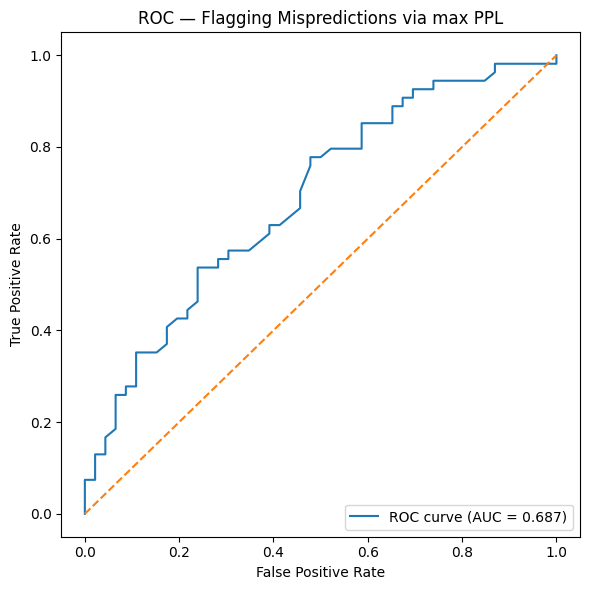

At best_thresh: TP=41, FP=22, FN=13, TN=24, Precision=0.6508, Recall=0.7593, F1=0.7009


In [66]:
# --- ROC curve & AUC (mispred = positive class) ---
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

y_true  = is_mispred.astype(int)   # 1 = mispredicted, 0 = correct
y_score = max_ppl.astype(float)    # continuous "risk" score

fpr, tpr, thresh = roc_curve(y_true, y_score, pos_label=1)
roc_auc = auc(fpr, tpr)
print(f"\nROC-AUC (mispred as positive): {roc_auc:.4f}")

# Optional: pick an operating point (Youden's J = TPR - FPR)
j_idx = np.argmax(tpr - fpr)
best_thresh = thresh[j_idx]
print(f"Best threshold by Youden's J: {best_thresh:.6f} | TPR={tpr[j_idx]:.3f}, FPR={fpr[j_idx]:.3f}")

# Plot
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — Flagging Mispredictions via max PPL")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# (Optional) Evaluate confusion metrics at the chosen threshold to match your table
def eval_at(th):
    mask = (y_score > th)
    TP = int(((mask == 1) & (y_true == 1)).sum())
    FP = int(((mask == 1) & (y_true == 0)).sum())
    FN = int(((mask == 0) & (y_true == 1)).sum())
    TN = int(((mask == 0) & (y_true == 0)).sum())
    prec = TP / (TP + FP) if (TP + FP) else 0.0
    rec  = TP / (TP + FN) if (TP + FN) else 0.0
    f1   = (2*prec*rec)/(prec+rec) if (prec+rec) else 0.0
    return TP, FP, FN, TN, prec, rec, f1

TP, FP, FN, TN, prec, rec, f1 = eval_at(best_thresh)
print(f"At best_thresh: TP={TP}, FP={FP}, FN={FN}, TN={TN}, Precision={prec:.4f}, Recall={rec:.4f}, F1={f1:.4f}")

In [67]:
# --- Combined evaluation for 100_Round_3 files (handles Tags OR one-hot GT) ---
import pandas as pd, numpy as np, ast, re

TRUE_PATH = "/home/ubuntu/TW_MultiLabel_SMP/datasets/100_Round_2 - Final_Annotations.csv"
PRED_PATH = "/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/predicted_labels_with_label_PPL_tr_300_te_100_k3.csv"

CANON_LABELS = [
    "Abuse","Aggression","Sexual","Medical",
    "Mental Health","Discrimination","Pregnancy","Not Applicable"
]

def norm_key_text(s):
    s = "" if pd.isna(s) else str(s)
    s = s.lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s

def norm_name(s: str) -> str:
    return re.sub(r"[^a-z0-9]+", "", str(s).strip().lower())

NORM_TO_CANON = {
    norm_name("abuse"): "Abuse",
    norm_name("aggression"): "Aggression",
    norm_name("sexual"): "Sexual",
    norm_name("medical"): "Medical",
    norm_name("mentalhealth"): "Mental Health",
    norm_name("mental health"): "Mental Health",
    norm_name("discrimination"): "Discrimination",
    norm_name("pregnancy"): "Pregnancy",
    norm_name("notapplicable"): "Not Applicable",
    norm_name("na"): "Not Applicable",
    norm_name("none"): "Not Applicable",
}

def to_canonical_label(s):
    key = norm_name(s)
    return NORM_TO_CANON.get(key, None)

def parse_listlike(text):
    """Parse list-like strings safely; fall back to splitting by , ; | / if needed."""
    if isinstance(text, list):
        return [str(t).strip() for t in text]
    if pd.isna(text):
        return []
    s = str(text).strip()
    try:
        v = ast.literal_eval(s)     # handles "['A','B']" or '["A","B"]'
        if isinstance(v, list):
            return [str(t).strip() for t in v]
        if isinstance(v, str):
            s = v
    except Exception:
        pass
    s = s.strip("[]()")
    parts = re.split(r"[,\|;/]", s)
    return [p.strip() for p in parts if p.strip()]

def parse_pred_list_to_set(val):
    raw = parse_listlike(val)
    out = []
    for item in raw:
        can = to_canonical_label(item)
        if can:
            out.append(can)
        elif item in CANON_LABELS:   # already canonical
            out.append(item)
    return set(out)

def truthy(val) -> bool:
    s = str(val).strip().lower()
    if s in {"1","true","yes","y","t","x","✓","✔","1.0"}:
        return True
    try:
        return float(s) > 0
    except:
        return False

# ---------- load ----------
df_true = pd.read_csv(TRUE_PATH)
df_pred = pd.read_csv(PRED_PATH)
df_true.columns = [c.strip() for c in df_true.columns]
df_pred.columns = [c.strip() for c in df_pred.columns]

# ---------- align rows (prefer id; else title+body) ----------
id_cols = [c for c in ["id","ID","post_id","PostID","Index"] if c in df_true.columns and c in df_pred.columns]
if id_cols:
    keycol = id_cols[0]
    df_true["_key"] = df_true[keycol]
    df_pred["_key"] = df_pred[keycol]
else:
    df_true["_key"] = df_true.get("title","").apply(norm_key_text) + " || " + df_true.get("body","").apply(norm_key_text)
    df_pred["_key"] = df_pred.get("title","").apply(norm_key_text) + " || " + df_pred.get("body","").apply(norm_key_text)

df_true = df_true.drop_duplicates("_key")
df_pred = df_pred.drop_duplicates("_key")
merged = df_pred.merge(df_true, on="_key", how="inner", suffixes=("_pred","_true"))
print(f"[Info] Rows — pred: {len(df_pred)}, true: {len(df_true)}, merged: {len(merged)}")

# ---------- build ground-truth label sets (supports Tags OR one-hot) ----------
label_cols_present = [lab for lab in CANON_LABELS if lab in merged.columns]
use_one_hot = (len(label_cols_present) >= 3)  # heuristic: if many of the 8 exist, treat as one-hot

def gt_row_to_set(row):
    if "Tags" in merged.columns and not use_one_hot:
        # Tags route
        raw = parse_listlike(row["Tags"])
        out = []
        for item in raw:
            can = to_canonical_label(item)
            if can:
                out.append(can)
        # fallback for single string tag
        if not out and isinstance(row["Tags"], str) and row["Tags"].strip():
            can = to_canonical_label(row["Tags"])
            if can:
                out = [can]
        return set(out)
    else:
        # one-hot route
        labs = []
        for lab in CANON_LABELS:
            if lab in row.index:
                val = row[lab]
                if truthy(val):
                    labs.append(lab)
        return set(labs)

true_sets = merged.apply(gt_row_to_set, axis=1)

# ---------- predicted label sets ----------
if "PredictedLabels" not in merged.columns:
    raise RuntimeError("Predictions file must contain 'PredictedLabels' column.")
pred_sets = merged["PredictedLabels"].apply(parse_pred_list_to_set)

# ---------- exact-set correctness ----------
is_mispred = np.array([t != p for t, p in zip(true_sets, pred_sets)], dtype=bool)
n_total = len(is_mispred)
n_corr = int((~is_mispred).sum())
n_wrong = int(is_mispred.sum())
acc = n_corr / n_total if n_total else 0.0

print("\n=== Ground Truth Accuracy (exact set match) ===")
print(f"Total compared:       {n_total}")
print(f"Correct predictions:  {n_corr}")
print(f"Mispredicted:         {n_wrong}")
print(f"Accuracy:             {acc:.4f}")

# ---------- max PPL per post ----------
ppl_cols = [c for c in merged.columns if c.startswith("PPL_")]
if not ppl_cols:
    raise RuntimeError("Predictions file must include PPL_* columns.")
max_ppl = merged[ppl_cols].max(axis=1).values

# ---------- combined review metrics (advisor definition) ----------
def eval_combined(thresh, label):
    mask = (max_ppl > thresh)                 # posts flagged by PPL
    n_total_flagged = int(mask.sum())
    TP = int((mask & is_mispred).sum())       # flagged & actually wrong
    FP = int((mask & ~is_mispred).sum())      # flagged but correct
    FN = int((~mask & is_mispred).sum())      # not flagged but wrong
    TN = int((~mask & ~is_mispred).sum())     # not flagged & correct

    precision = (TP / (TP + FP)) if (TP + FP) > 0 else 0.0
    recall    = (TP / (TP + FN)) if (TP + FN) > 0 else 0.0
    f1        = (2*precision*recall)/(precision+recall) if (precision+recall) > 0 else 0.0

    return {
        "Bin": label,
        "Threshold rule": f"PPL > {thresh}",
        "Posts flagged": n_total_flagged,
        "TP (flagged & wrong)": TP,
        "FP (flagged & correct)": FP,
        "FN (missed wrong)": FN,
        "TN (ignored & correct)": TN,
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1": round(f1, 4),
    }

results = [
    eval_combined(1.05, "Review (Noticeable + Flag)"),
    eval_combined(1.02, "Review (Mild + Noticeable + Flag)"),
    eval_combined(1.01, "Review (Mild + Noticeable + Flag)"),
    eval_combined(1.0005, "Review (Mild + Noticeable + Flag)"),
    eval_combined(1.00, "Review (Mild + Noticeable + Flag)")
]

df_combined = pd.DataFrame(results)
print("\n=== Combined Review Metrics ===")
print(df_combined.to_string(index=False))


[Info] Rows — pred: 100, true: 100, merged: 100

=== Ground Truth Accuracy (exact set match) ===
Total compared:       100
Correct predictions:  46
Mispredicted:         54
Accuracy:             0.4600

=== Combined Review Metrics ===
                              Bin Threshold rule  Posts flagged  TP (flagged & wrong)  FP (flagged & correct)  FN (missed wrong)  TN (ignored & correct)  Precision  Recall     F1
       Review (Noticeable + Flag)     PPL > 1.05             24                    19                       5                 35                      41     0.7917  0.3519 0.4872
Review (Mild + Noticeable + Flag)     PPL > 1.02             36                    25                      11                 29                      35     0.6944  0.4630 0.5556
Review (Mild + Noticeable + Flag)     PPL > 1.01             42                    29                      13                 25                      33     0.6905  0.5370 0.6042
Review (Mild + Noticeable + Flag)   PPL > 1.0005 


=== Metrics at Selected Perplexity Thresholds ===
 Threshold (PPL > th)  TP  FP  FN  TN  Precision  Recall     F1
             1.000000  54  46   0   0     0.5400  1.0000 0.7013
             1.000100  46  30   8  16     0.6053  0.8519 0.7077
             1.000200  46  28   8  18     0.6216  0.8519 0.7187
             1.000300  44  27  10  19     0.6197  0.8148 0.7040
             1.000400  43  26  11  20     0.6232  0.7963 0.6992
             1.000500  42  23  12  23     0.6462  0.7778 0.7059
             1.000600  42  23  12  23     0.6462  0.7778 0.7059
             1.000700  42  23  12  23     0.6462  0.7778 0.7059
             1.000800  42  22  12  24     0.6562  0.7778 0.7119
             1.000900  42  22  12  24     0.6562  0.7778 0.7119
             1.000912  41  22  13  24     0.6508  0.7593 0.7009
             1.001000  38  21  16  25     0.6441  0.7037 0.6726


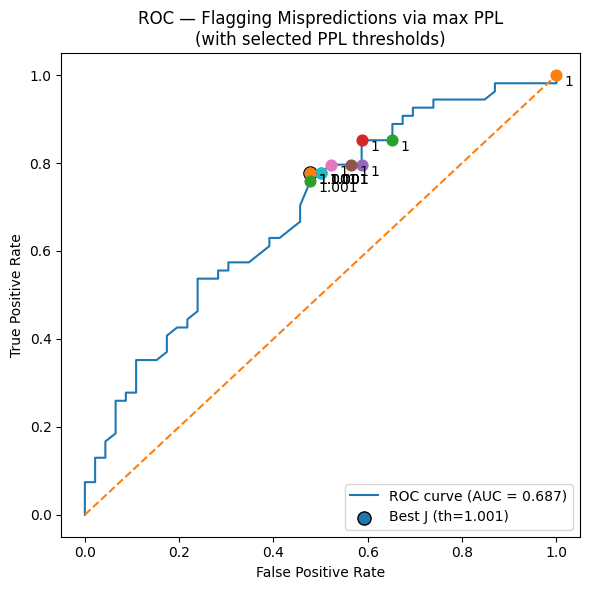

In [68]:
import pandas as pd
import numpy as np

# --- Choose thresholds to report/mark (include your table's values + best J) ---
chosen_ths = [1.00, 1.0001, 1.0002, 1.0003, 1.0004, 1.0005, 1.0006, 1.0007, 1.0008, 1.0009, 1.001]
# chosen_ths = [1.00, 1.0005, 1.001, 1.002, 1.003, 1.004, 1.005, 1.006, 1.007, 1.008, 1.009, 1.01, 1.02, 1.05]
chosen_ths.append(float(best_thresh))
chosen_ths = sorted(set(chosen_ths))

# --- Compute metrics at each chosen threshold ---
rows = []
for th in chosen_ths:
    TP, FP, FN, TN, prec, rec, f1 = eval_at(th)
    rows.append({
        "Threshold (PPL > th)": th,
        "TP": TP, "FP": FP, "FN": FN, "TN": TN,
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1": round(f1, 4),
    })

df_thresh = pd.DataFrame(rows)
print("\n=== Metrics at Selected Perplexity Thresholds ===")
print(df_thresh.to_string(index=False))

# --- Build a (fpr,tpr,threshold) DataFrame (filter out inf) for plotting helpers ---
roc_df = pd.DataFrame({"FPR": fpr, "TPR": tpr, "th": thresh})
roc_df = roc_df[np.isfinite(roc_df["th"])]

# --- Plot again with dots + labels for the chosen thresholds (nearest ROC points) ---
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")

# mark best J
plt.scatter([fpr[j_idx]], [tpr[j_idx]], s=90, marker="o", edgecolors="k", zorder=3,
            label=f"Best J (th={best_thresh:.4g})")

# mark selected thresholds
for th in chosen_ths:
    # find nearest ROC threshold index
    idx = int(np.argmin(np.abs(thresh - th)))
    x, y = fpr[idx], tpr[idx]
    plt.scatter([x], [y], s=60, zorder=3)
    plt.annotate(f"{th:.4g}", (x, y), textcoords="offset points", xytext=(6, -8))

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — Flagging Mispredictions via max PPL\n(with selected PPL thresholds)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


### Round 4 - (Train : 400, Test : 100)

In [75]:
# === Batch 3-shot (k=3) few-shot labeling for 125 posts WITH per-label OUTPUT perplexity (no ground truth) ===
import pandas as pd, json, time, copy, re
from pathlib import Path

# -------- Paths --------
PERP_DIR        = Path("/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files")
PERP_DIR.mkdir(parents=True, exist_ok=True)

INPUT_CSV       = "/home/ubuntu/TW_MultiLabel_SMP/datasets/100_Round_3 - Final Annotations.csv"  # your input posts
OUTPUT_CSV      = PERP_DIR / "predicted_labels_with_label_PPL_tr_400_te_100_k3.csv"   # single file you asked for
EXAMPLES_JSON   = "/home/ubuntu/TW_MultiLabel_SMP/used_examples/used_examples_for_tr_400_te_100_k3.json"        # optional traceability

YESNO_RE = re.compile(r"\b(YES|NO)\b", re.IGNORECASE)

# Use this label order exactly as requested
LABELS_ORDER = [
    "Abuse",
    "Aggression",
    "Sexual",
    "Medical",
    "Mental Health",
    "Discrimination",
    "Pregnancy",
    "Not Applicable",
]

# --- taxonomy definitions (fallback to empty strings if you don't have the real text loaded) ---
if 'definitions' not in globals():
    definitions = {lbl: "" for lbl in LABELS_ORDER}

# --- compatibility shims for older helper cells ---
labels = LABELS_ORDER              # so make_multishot_prompt_cosine can use `labels`
collected_examples_per_label = {}  # ensure the snapshot dict exists

def extract_yes_no(resp) -> str:
    """Coerce model output to YES/NO; accepts dicts and strings."""
    if resp is None:
        return "NO"
    if isinstance(resp, dict):
        if "text" in resp and isinstance(resp["text"], str):
            resp = resp["text"]
        elif "content" in resp and isinstance(resp["content"], str):
            resp = resp["content"]
        else:
            resp = str(resp)
    if not isinstance(resp, str):
        resp = str(resp)
    line = resp.strip().splitlines()[0] if resp.strip() else ""
    m = YESNO_RE.search(line)
    if m:
        return "YES" if m.group(1).upper() == "YES" else "NO"
    tok = line.upper().split()[:1]
    return "YES" if (tok and tok[0] == "YES") else "NO"

def tiny_throttle(sec=0.35):
    try:
        import time; time.sleep(sec)
    except Exception:
        pass

# --- load input posts ---
df_in = pd.read_csv(INPUT_CSV)
if not {'title','body'}.issubset(df_in.columns):
    raise KeyError("INPUT_CSV must contain 'title' and 'body' columns.")
subset = df_in.iloc[:125][['title','body']].fillna('').astype(str)

rows_out = []
all_used_examples = []   # snapshot of cosine-chosen neighbors for transparency

for i, (_, row) in enumerate(subset.iterrows(), start=1):
    title = row['title']
    body  = row['body']

    collected_examples_per_label = {}

    # Populate cosine neighbors (Cell 1); DOES NOT change the prompt text
    _ = make_multishot_prompt_cosine(
        k=3,
        title=title,
        body=body,
        current_index=None,
        include_defs=True,
        debug=False
    )

    yes_labels = []
    per_label_ppl = {}
    # collect per-label debug lines to print later
    per_label_lines = []

    for idx_lbl, lbl in enumerate(LABELS_ORDER, start=1):
        prompt = make_prompt_for_label(
            label_name=lbl,
            k=3,
            title=title,
            body=body,
            current_index=None,
            debug=False
        )

        # Call Cell 2 helper (returns token logprobs for the YES/NO answer)
        resp = getTriggerWarningsLLMResponse(
            prompt,
            mode="binary",
            max_tokens=4,     # enough for YES/NO; if splits happen, Cell 2's PPL_MODE="avg" handles it
            temperature=0.0,
            verbose=False
        )

        ans = extract_yes_no(resp)
        per_label_ppl[lbl] = float(resp.get("ppl", float("nan")))   # self-confidence PPL from output logprobs

        # One quick retry if malformed
        if ans not in ("YES", "NO"):
            resp2 = getTriggerWarningsLLMResponse(
                prompt,
                mode="binary",
                max_tokens=8,
                temperature=0.0,
                verbose=False
            )
            ans = extract_yes_no(resp2)
            per_label_ppl[lbl] = float(resp2.get("ppl", per_label_ppl[lbl]))

        if ans == "YES":
            yes_labels.append(lbl)

        # buffer the per-label heartbeat & result (we'll print after the summary)
        per_label_lines.append(f"[post {i}/100] label {idx_lbl}/8: {lbl}")
        dbg = (resp.get("text","") or "")[:120].replace("\n"," ")
        per_label_lines.append(f"Post {i}, Label '{lbl}': {dbg!r} -> {ans}, PPL_out={per_label_ppl[lbl]:.4f}")

        tiny_throttle(0.12)

    if not yes_labels:
        yes_labels = ["Not Applicable"]

    # ---- YES-only summary (first line you wanted) ----
    yes_ppl_items = []
    yes_ppl_values = []
    for lbl in yes_labels:
        v = per_label_ppl.get(lbl, float("nan"))
        yes_ppl_items.append(f"{lbl}:{(f'{v:.4f}' if (v==v) else 'NaN')}")
        if v == v:
            yes_ppl_values.append(v)

    mean_yes = (sum(yes_ppl_values)/len(yes_ppl_values)) if yes_ppl_values else float("nan")
    max_yes  = (max(yes_ppl_values))                      if yes_ppl_values else float("nan")
    mean_str = f"{mean_yes:.4f}" if (mean_yes==mean_yes) else "NaN"
    max_str  = f"{max_yes:.4f}"  if (max_yes==max_yes)   else "NaN"

    # 1) YES line
    print(f"{i}. YES labels: {yes_labels} | YES-PPLs[{', '.join(yes_ppl_items)}] |")

    # 2) banner
    print(f"=== Working on post {i}/100 ===")

    # 3) full per-label block
    for line in per_label_lines:
        print(line)

    # 4) tail stats
    print(f"meanPPL_yes={mean_str} | maxPPL_yes={max_str}")

    # ---- build output row for CSV ----
    out_row = {
        "title": title,
        "body": body,
        "PredictedLabels": json.dumps(yes_labels, ensure_ascii=False)
    }
    for lbl in LABELS_ORDER:
        out_row[f"PPL_{lbl}"] = per_label_ppl.get(lbl, float("nan"))
    rows_out.append(out_row)

    # keep examples snapshot for auditability
    snapshot = copy.deepcopy(collected_examples_per_label) if 'collected_examples_per_label' in globals() else {}
    all_used_examples.append({
        "post_index_1_based": i,
        "title": title,
        "body": body,
        "examples_by_label": snapshot
    })

# --- save single CSV with predicted labels + 8 per-label PPL columns ---
df_out = pd.DataFrame(rows_out)
df_out.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")
print(f"\n✅ Saved predicted labels + per-label OUTPUT PPL to {OUTPUT_CSV}")

# --- optional: save used examples JSON for traceability ---
with open(EXAMPLES_JSON, "w", encoding="utf-8") as f:
    json.dump(all_used_examples, f, indent=2, ensure_ascii=False)
print(f"✅ Saved used examples (cosine-picked) to {EXAMPLES_JSON}")


1. YES labels: ['Medical', 'Pregnancy'] | YES-PPLs[Medical:1.0000, Pregnancy:1.0000] |
=== Working on post 1/100 ===
[post 1/100] label 1/8: Abuse
Post 1, Label 'Abuse': 'NO' -> NO, PPL_out=1.0000
[post 1/100] label 2/8: Aggression
Post 1, Label 'Aggression': 'NO' -> NO, PPL_out=1.0000
[post 1/100] label 3/8: Sexual
Post 1, Label 'Sexual': 'NO' -> NO, PPL_out=1.0000
[post 1/100] label 4/8: Medical
Post 1, Label 'Medical': 'YES' -> YES, PPL_out=1.0000
[post 1/100] label 5/8: Mental Health
Post 1, Label 'Mental Health': 'NO' -> NO, PPL_out=1.0015
[post 1/100] label 6/8: Discrimination
Post 1, Label 'Discrimination': 'NO' -> NO, PPL_out=1.0000
[post 1/100] label 7/8: Pregnancy
Post 1, Label 'Pregnancy': 'YES' -> YES, PPL_out=1.0000
[post 1/100] label 8/8: Not Applicable
Post 1, Label 'Not Applicable': 'NO' -> NO, PPL_out=1.0000
meanPPL_yes=1.0000 | maxPPL_yes=1.0000
2. YES labels: ['Medical', 'Mental Health', 'Discrimination', 'Pregnancy'] | YES-PPLs[Medical:1.2865, Mental Health:1.0000, 

In [76]:
# Round 4 Cell: Precision/Recall/F1 per post using GT "Tags" column (Ubuntu-friendly)
import os
import ast
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

INPUT_CSV  = "/home/ubuntu/TW_MultiLabel_SMP/datasets/100_Round_3 - Final Annotations.csv"
OUTPUT_CSV = "/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/predicted_labels_with_label_PPL_tr_400_te_100_k3.csv"
SAVE_AS    = "/home/ubuntu/TW_MultiLabel_SMP/metrics/per_post_metrics_from_tr_400_te_100_tags_multishot_k_3_gpt.csv"

# ---- load data ----
gt_df   = pd.read_csv(INPUT_CSV)
pred_df = pd.read_csv(OUTPUT_CSV)

# align to first 75 rows (adjust if you want more)
gt_subset   = gt_df.head(125).reset_index(drop=True)
pred_subset = pred_df.head(125).reset_index(drop=True)

# ---- helpers ----
def parse_listish(value):
    """
    Parse labels that might be stored as python-list strings or comma-separated strings.
    Returns a set of normalized labels.
    """
    if pd.isna(value):
        return set()
    s = str(value).strip()
    # try python list literal first
    try:
        maybe_list = ast.literal_eval(s)
        if isinstance(maybe_list, (list, tuple)):
            items = maybe_list
        else:
            items = [s]
    except Exception:
        # fallback: comma-separated
        items = [tok.strip() for tok in s.split(",") if tok.strip()]
    # normalize labels (consistent spacing/case)
    return set([str(x).strip() for x in items if str(x).strip()])

# ---- parse labels ----
if "Tags" not in gt_subset.columns:
    raise KeyError("Ground truth CSV must contain a 'Tags' column with human-annotated labels.")

gt_labels_list   = gt_subset["Tags"].apply(parse_listish).tolist()
pred_labels_list = pred_subset["PredictedLabels"].apply(parse_listish).tolist()

# build label universe
all_labels = sorted(list(set().union(*gt_labels_list, *pred_labels_list)))

# ---- compute metrics ----
rows = []
y_true_all, y_pred_all = [], []

for idx, (gt_set, pred_set) in enumerate(zip(gt_labels_list, pred_labels_list), start=1):
    y_true = [1 if l in gt_set else 0 for l in all_labels]
    y_pred = [1 if l in pred_set else 0 for l in all_labels]

    y_true_all.extend(y_true)
    y_pred_all.extend(y_pred)

    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f = f1_score(y_true, y_pred, zero_division=0)

    rows.append({
        "PostIndex": idx,
        "TrueLabels": sorted(list(gt_set)),
        "PredictedLabels": sorted(list(pred_set)),
        "Precision": round(p, 3),
        "Recall": round(r, 3),
        "F1": round(f, 3),
    })

metrics_df = pd.DataFrame(rows)

# macro averages = mean of per-post metrics
macro_p = float(metrics_df["Precision"].mean())
macro_r = float(metrics_df["Recall"].mean())
macro_f = float(metrics_df["F1"].mean())

# micro averages = computed on pooled one-hot vectors
micro_p = precision_score(y_true_all, y_pred_all, zero_division=0)
micro_r = recall_score(y_true_all, y_pred_all, zero_division=0)
micro_f = f1_score(y_true_all, y_pred_all, zero_division=0)

summary_rows = pd.DataFrame([
    {"PostIndex": "Macro-Avg", "TrueLabels": None, "PredictedLabels": None,
     "Precision": round(macro_p, 3), "Recall": round(macro_r, 3), "F1": round(macro_f, 3)},
    {"PostIndex": "Micro-Avg", "TrueLabels": None, "PredictedLabels": None,
     "Precision": round(micro_p, 3), "Recall": round(micro_r, 3), "F1": round(micro_f, 3)},
])

final_metrics = pd.concat([metrics_df, summary_rows], ignore_index=True)

# ---- save (no /mnt/data, so always local) ----
final_metrics.to_csv(SAVE_AS, index=False, encoding="utf-8")
print(f"✅ Saved per-post metrics + macro/micro averages to: {os.path.abspath(SAVE_AS)}")


✅ Saved per-post metrics + macro/micro averages to: /home/ubuntu/TW_MultiLabel_SMP/metrics/per_post_metrics_from_tr_400_te_100_tags_multishot_k_3_gpt.csv


In [77]:
# Round 4 K-3 metrics results 
import pandas as pd
import ast

# === Configure this to your file ===
CSV_PATH = "/home/ubuntu/TW_MultiLabel_SMP/metrics/per_post_metrics_from_tr_400_te_100_tags_multishot_k_3_gpt.csv"

def _safe_list(x):
    """Parse list-like strings into Python lists; return [] if parsing fails."""
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    s = str(x).strip()
    # try JSON-ish or Python literal list
    try:
        val = ast.literal_eval(s)
        if isinstance(val, list):
            return val
    except Exception:
        pass
    # fallback: comma-split
    return [t.strip() for t in s.split(",") if t.strip()]

def summarize_metrics(csv_path: str):
    df = pd.read_csv(csv_path)

    # Detect summary rows if present
    has_macro = (df["PostIndex"] == "Macro-Avg").any() if "PostIndex" in df.columns else False
    has_micro = (df["PostIndex"] == "Micro-Avg").any() if "PostIndex" in df.columns else False

    # Pull macro/micro if available, else compute from per-post rows
    macro_p = macro_r = macro_f = None
    micro_p = micro_r = micro_f = None

    if has_macro:
        row = df.loc[df["PostIndex"] == "Macro-Avg"].iloc[0]
        macro_p, macro_r, macro_f = float(row["Precision"]), float(row["Recall"]), float(row["F1"])
    if has_micro:
        row = df.loc[df["PostIndex"] == "Micro-Avg"].iloc[0]
        micro_p, micro_r, micro_f = float(row["Precision"]), float(row["Recall"]), float(row["F1"])

    # Filter per-post rows
    per_post = df.copy()
    if "PostIndex" in per_post.columns:
        per_post = per_post[~per_post["PostIndex"].isin(["Macro-Avg", "Micro-Avg"])]

    # Compute perfect/incorrect if we have labels
    perfect_matches = completely_incorrect = None
    if {"TrueLabels", "PredictedLabels"}.issubset(per_post.columns):
        t_labels = per_post["TrueLabels"].apply(_safe_list)
        p_labels = per_post["PredictedLabels"].apply(_safe_list)

        perfect_matches = sum(set(t) == set(p) for t, p in zip(t_labels, p_labels))
        completely_incorrect = sum(len(set(t).intersection(set(p))) == 0 for t, p in zip(t_labels, p_labels))
        n_posts = len(per_post)
    else:
        n_posts = len(per_post)

    # If macro/micro not present, approximate macro as mean of per-post, and skip micro
    if macro_p is None and {"Precision","Recall","F1"}.issubset(per_post.columns):
        macro_p = per_post["Precision"].mean()
        macro_r = per_post["Recall"].mean()
        macro_f = per_post["F1"].mean()

    # Pretty print in your requested format
    print("Here’s the summary you can share with your advisor:\n")
    if macro_p is not None:
        print(f"Macro Precision: {macro_p:.3f}")
        print(f"Macro Recall: {macro_r:.3f}")
        print(f"Macro F1: {macro_f:.3f}\n")
    else:
        print("Macro metrics: not available in this file.\n")

    if micro_p is not None:
        print(f"Micro Precision: {micro_p:.3f}")
        print(f"Micro Recall: {micro_r:.3f}")
        print(f"Micro F1: {micro_f:.3f}\n")
    else:
        print("Micro metrics: not available in this file.\n")

    if perfect_matches is not None:
        print(f"Perfect Matches: {perfect_matches} out of {n_posts} posts ({100*perfect_matches/n_posts:.1f}%) exactly matched human annotations")
    else:
        print("Perfect Matches: (labels not found in CSV to compute)")
    if completely_incorrect is not None:
        print(f"Completely Incorrect: {completely_incorrect} out of {n_posts} posts ({100*completely_incorrect/n_posts:.1f}%) had no correct labels")
    else:
        print("Completely Incorrect: (labels not found in CSV to compute)")

# Run
summarize_metrics(CSV_PATH)

Here’s the summary you can share with your advisor:

Macro Precision: 0.856
Macro Recall: 0.911
Macro F1: 0.861

Micro Precision: 0.850
Micro Recall: 0.915
Micro F1: 0.881

Perfect Matches: 51 out of 100 posts (51.0%) exactly matched human annotations
Completely Incorrect: 3 out of 100 posts (3.0%) had no correct labels


In [79]:
# Round 4 --- Threshold-based misprediction detection using PPL ---
import pandas as pd
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

# Load files
df_true = pd.read_csv("/home/ubuntu/TW_MultiLabel_SMP/datasets/100_Round_3 - Final Annotations.csv")
df_pred = pd.read_csv("/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/predicted_labels_with_label_PPL_tr_400_te_100_k3.csv")

# Ensure column alignment
if "PredictedLabels" not in df_pred.columns:
    raise ValueError("Predictions file must contain 'PredictedLabels' column.")

# Parse ground truth: all 8 label columns (0/1)
label_cols = ["Abuse", "Aggression", "Sexual", "Medical", 
              "Mental Health", "Discrimination", "Pregnancy", "Not Applicable"]

def row_to_labelset(row):
    return [lbl for lbl in label_cols if row.get(lbl, 0) == 1]

# Ground truth sets
true_labels = [row_to_labelset(row) for _, row in df_true.iterrows()]

# Predicted sets
pred_labels = df_pred["PredictedLabels"].apply(lambda x: eval(x) if isinstance(x, str) else [])

# Identify mispredictions (row-wise)
is_mispred = [set(t) != set(p) for t, p in zip(true_labels, pred_labels)]

# Function to test thresholds
def eval_thresholds(df_pred, is_mispred, thresholds=np.arange(1.0, 1.15, 0.01)):
    results = []
    is_mispred = np.array(is_mispred, dtype=bool)  # ensure numpy array
    
    for t in thresholds:
        # Flag as suspect if any label PPL > threshold
        suspect = (df_pred[[c for c in df_pred.columns if c.startswith("PPL_")]].max(axis=1).values > t)
        
        # Compare with actual mispredictions
        TP = np.sum(suspect & is_mispred)
        FP = np.sum(suspect & ~is_mispred)
        FN = np.sum(~suspect & is_mispred)
        TN = np.sum(~suspect & ~is_mispred)
        
        precision = TP / (TP + FP) if (TP + FP) else 0.0
        recall    = TP / (TP + FN) if (TP + FN) else 0.0
        f1        = (2*precision*recall)/(precision+recall) if (precision+recall) else 0.0
        
        results.append({
            "threshold": round(t, 3),
            "TP": TP, "FP": FP, "FN": FN, "TN": TN,
            "precision": round(precision, 4),
            "recall": round(recall, 4),
            "f1": round(f1, 4)
        })
    return pd.DataFrame(results)

# Run evaluation
# Use 1.01 → 1.10 instead of starting at 1.00
results_df = eval_thresholds(df_pred, is_mispred, thresholds=np.arange(1.01, 1.11, 0.01))


# Show first few rows
print(results_df.head(10))

# Save to CSV for full inspection
results_df.to_csv("/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/threshold_eval_metrics_tr_400.csv", index=False)
print("✅ Saved metrics to /home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/threshold_eval_metrics_400.csv")

# Show best thresholds
best_f1 = results_df.loc[results_df["f1"].idxmax()]
best_recall = results_df.loc[results_df["recall"].idxmax()]
print("\n🏆 Best by F1:")
print(best_f1)

print("\n🔎 Best by Recall:")
print(best_recall)

   threshold  TP  FP  FN  TN  precision  recall      f1
0       1.01  47   0  53   0        1.0    0.47  0.6395
1       1.02  38   0  62   0        1.0    0.38  0.5507
2       1.03  37   0  63   0        1.0    0.37  0.5401
3       1.04  30   0  70   0        1.0    0.30  0.4615
4       1.05  30   0  70   0        1.0    0.30  0.4615
5       1.06  30   0  70   0        1.0    0.30  0.4615
6       1.07  29   0  71   0        1.0    0.29  0.4496
7       1.08  29   0  71   0        1.0    0.29  0.4496
8       1.09  22   0  78   0        1.0    0.22  0.3607
9       1.10  22   0  78   0        1.0    0.22  0.3607
✅ Saved metrics to /home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/threshold_eval_metrics_400.csv

🏆 Best by F1:
threshold     1.0100
TP           47.0000
FP            0.0000
FN           53.0000
TN            0.0000
precision     1.0000
recall        0.4700
f1            0.6395
Name: 0, dtype: float64

🔎 Best by Recall:
threshold     1.0100
TP           47.0000
FP            0.00

In [80]:
# Round 4 --- One-shot overall Precision / Recall / F1 for all 100 posts ---
import pandas as pd
import numpy as np
import json, ast

# Load
df_true = pd.read_csv("/home/ubuntu/TW_MultiLabel_SMP/datasets/100_Round_3 - Final Annotations.csv")
df_pred = pd.read_csv("/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/predicted_labels_with_label_PPL_tr_400_te_100_k3.csv")

label_cols = ["Abuse", "Aggression", "Sexual", "Medical", 
              "Mental Health", "Discrimination", "Pregnancy", "Not Applicable"]

def row_to_labelset(row):
    return {lbl for lbl in label_cols if row.get(lbl, 0) == 1}

# Ground-truth sets
true_sets = [row_to_labelset(row) for _, row in df_true.iterrows()]

# Predicted sets (robust parse)
def parse_pred(s):
    if isinstance(s, list): 
        return set(s)
    if isinstance(s, str):
        s = s.strip()
        if not s:
            return set()
        try:
            return set(json.loads(s))
        except Exception:
            try:
                return set(ast.literal_eval(s))
            except Exception:
                return set()
    return set()

pred_sets = [parse_pred(s) for s in df_pred["PredictedLabels"]]

# Mispred flags (row-wise)
is_mispred = np.array([ts != ps for ts, ps in zip(true_sets, pred_sets)], dtype=bool)

# Max PPL per post
ppl_cols = [c for c in df_pred.columns if c.startswith("PPL_")]
max_ppl = df_pred[ppl_cols].max(axis=1).to_numpy(dtype=float)

# ---- choose your single threshold here ----
THRESHOLD = 1.02  # change if you want

# Suspect if any label's output-PPL exceeds threshold
suspect = (max_ppl > THRESHOLD)

# Confusion matrix
TP = int(np.sum(suspect & is_mispred))
FP = int(np.sum(suspect & ~is_mispred))
FN = int(np.sum(~suspect & is_mispred))
TN = int(np.sum(~suspect & ~is_mispred))

precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
f1        = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

print("=== Overall Evaluation (All 125 posts) ===")
print(f"Threshold: PPL > {THRESHOLD:.3f}")
print(f"TP: {TP}, FP: {FP}, FN: {FN}, TN: {TN}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")

# (optional) also show coverage
print(f"\nFlagged (suspect) posts: {int(suspect.sum())} / {len(suspect)}")
print(f"Mispredicted posts: {int(is_mispred.sum())} / {len(is_mispred)}")

=== Overall Evaluation (All 125 posts) ===
Threshold: PPL > 1.020
TP: 38, FP: 0, FN: 62, TN: 0
Precision: 1.0000
Recall:    0.3800
F1:        0.5507

Flagged (suspect) posts: 38 / 100
Mispredicted posts: 100 / 100


In [81]:
import pandas as pd, numpy as np, ast, re

TRUE_PATH = "/home/ubuntu/TW_MultiLabel_SMP/datasets/100_Round_3 - Final Annotations.csv"
PRED_PATH = "/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/predicted_labels_with_label_PPL_tr_400_te_100_k3.csv"

CANON_LABELS = [
    "Abuse",
    "Aggression",
    "Sexual",
    "Medical",
    "Mental Health",
    "Discrimination",
    "Pregnancy",
    "Not Applicable",
]

def norm_key_text(s):
    s = "" if pd.isna(s) else str(s)
    s = s.lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s

def norm_name(s: str) -> str:
    return re.sub(r"[^a-z0-9]+", "", str(s).strip().lower())

# map many variants to canonical labels
NORM_TO_CANON = {
    norm_name("abuse"): "Abuse",
    norm_name("aggression"): "Aggression",
    norm_name("sexual"): "Sexual",
    norm_name("medical"): "Medical",
    norm_name("mentalhealth"): "Mental Health",
    norm_name("mental health"): "Mental Health",
    norm_name("discrimination"): "Discrimination",
    norm_name("pregnancy"): "Pregnancy",
    norm_name("notapplicable"): "Not Applicable",
    norm_name("na"): "Not Applicable",
    norm_name("none"): "Not Applicable",
}

def to_canonical_label(s):
    key = norm_name(s)
    return NORM_TO_CANON.get(key, None)

def parse_listlike(text):
    """Parse list-like strings safely; fall back to splitting by , ; | / if needed."""
    if isinstance(text, list):
        return [str(t).strip() for t in text]
    if pd.isna(text):
        return []
    s = str(text).strip()
    # Try literal_eval first (handles "['A','B']" or '["A","B"]')
    try:
        v = ast.literal_eval(s)
        if isinstance(v, list):
            return [str(t).strip() for t in v]
        if isinstance(v, str):
            s = v  # fall through to split
    except Exception:
        pass
    # Strip surrounding brackets if present
    s = s.strip("[]()")
    # Split on common separators
    parts = re.split(r"[,\|;/]", s)
    return [p.strip() for p in parts if p.strip()]

def parse_gt_tags_to_set(val):
    raw = parse_listlike(val)
    out = []
    for item in raw:
        can = to_canonical_label(item)
        if can:
            out.append(can)
    # if “Tags” might be a single string label like "Medical"
    if not out and isinstance(val, str) and val.strip():
        can = to_canonical_label(val)
        if can:
            out = [can]
    return set(out)

def parse_pred_list_to_set(val):
    raw = parse_listlike(val)
    out = []
    for item in raw:
        can = to_canonical_label(item)
        if can:
            out.append(can)
        else:
            # If predictions are already canonical, keep as-is
            if item in CANON_LABELS:
                out.append(item)
    return set(out)

# ---- Load
df_true = pd.read_csv(TRUE_PATH)
df_pred = pd.read_csv(PRED_PATH)

# normalize columns
df_true.columns = [c.strip() for c in df_true.columns]
df_pred.columns = [c.strip() for c in df_pred.columns]

# ---- Build join key (prefer id if in both; else title+body)
id_cols = [c for c in ["id","ID","post_id","PostID","Index"] if c in df_true.columns and c in df_pred.columns]
if id_cols:
    keycol = id_cols[0]
    df_true["_key"] = df_true[keycol]
    df_pred["_key"] = df_pred[keycol]
else:
    df_true["_key"] = df_true.get("title","").apply(norm_key_text) + " || " + df_true.get("body","").apply(norm_key_text)
    df_pred["_key"] = df_pred.get("title","").apply(norm_key_text) + " || " + df_pred.get("body","").apply(norm_key_text)

df_true = df_true.drop_duplicates("_key")
df_pred = df_pred.drop_duplicates("_key")

merged = df_pred.merge(df_true, on="_key", how="inner", suffixes=("_pred","_true"))
print(f"[Info] Rows — pred: {len(df_pred)}, true: {len(df_true)}, merged: {len(merged)}")

# ---- Extract GT label sets from 'Tags'
if "Tags" not in merged.columns:
    raise RuntimeError("Ground-truth file must contain a 'Tags' column (list or delimited string of labels).")

true_sets = merged["Tags"].apply(parse_gt_tags_to_set)

# ---- Extract predicted label sets from 'PredictedLabels'
if "PredictedLabels" not in merged.columns:
    raise RuntimeError("Predictions file must contain 'PredictedLabels' column.")

pred_sets = merged["PredictedLabels"].apply(parse_pred_list_to_set)

# ---- Compare
is_correct = (pred_sets == true_sets)
n_total = len(is_correct)
n_correct = int(is_correct.sum())
n_mispred = n_total - n_correct
acc = n_correct / n_total if n_total else 0.0

print("\n=== Ground Truth Evaluation (Aligned rows) ===")
print(f"Total compared:       {n_total}")
print(f"Correct predictions:  {n_correct}")
print(f"Mispredicted:         {n_mispred}")
print(f"Accuracy:             {acc:.4f}")

# Optional: quick peek at a few mismatches
if n_correct < n_total:
    debug = pd.DataFrame({
        "GT": true_sets.apply(lambda s: sorted(list(s))),
        "Pred": pred_sets.apply(lambda s: sorted(list(s)))
    })
    print("\n[Debug] Sample mismatches (first 5):")
    print(debug[debug["GT"] != debug["Pred"]].head(5).to_string(index=False))


[Info] Rows — pred: 100, true: 100, merged: 100

=== Ground Truth Evaluation (Aligned rows) ===
Total compared:       100
Correct predictions:  51
Mispredicted:         49
Accuracy:             0.5100

[Debug] Sample mismatches (first 5):
                                 GT                                                Pred
[Medical, Mental Health, Pregnancy]                                [Medical, Pregnancy]
[Medical, Mental Health, Pregnancy] [Discrimination, Medical, Mental Health, Pregnancy]
[Medical, Mental Health, Pregnancy]                                         [Pregnancy]
         [Mental Health, Pregnancy]          [Discrimination, Mental Health, Pregnancy]
                        [Pregnancy]                         [Discrimination, Pregnancy]


In [82]:
# --- Combined evaluation for 100_Round_4 files (handles Tags OR one-hot GT) ---
import pandas as pd, numpy as np, ast, re

TRUE_PATH = "/home/ubuntu/TW_MultiLabel_SMP/datasets/100_Round_3 - Final Annotations.csv"
PRED_PATH = "/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/predicted_labels_with_label_PPL_tr_400_te_100_k3.csv"

CANON_LABELS = [
    "Abuse","Aggression","Sexual","Medical",
    "Mental Health","Discrimination","Pregnancy","Not Applicable"
]

def norm_key_text(s):
    s = "" if pd.isna(s) else str(s)
    s = s.lower().strip()
    s = re.sub(r"\s+", " ", s)
    return s

def norm_name(s: str) -> str:
    return re.sub(r"[^a-z0-9]+", "", str(s).strip().lower())

NORM_TO_CANON = {
    norm_name("abuse"): "Abuse",
    norm_name("aggression"): "Aggression",
    norm_name("sexual"): "Sexual",
    norm_name("medical"): "Medical",
    norm_name("mentalhealth"): "Mental Health",
    norm_name("mental health"): "Mental Health",
    norm_name("discrimination"): "Discrimination",
    norm_name("pregnancy"): "Pregnancy",
    norm_name("notapplicable"): "Not Applicable",
    norm_name("na"): "Not Applicable",
    norm_name("none"): "Not Applicable",
}

def to_canonical_label(s):
    key = norm_name(s)
    return NORM_TO_CANON.get(key, None)

def parse_listlike(text):
    """Parse list-like strings safely; fall back to splitting by , ; | / if needed."""
    if isinstance(text, list):
        return [str(t).strip() for t in text]
    if pd.isna(text):
        return []
    s = str(text).strip()
    try:
        v = ast.literal_eval(s)     # handles "['A','B']" or '["A","B"]'
        if isinstance(v, list):
            return [str(t).strip() for t in v]
        if isinstance(v, str):
            s = v
    except Exception:
        pass
    s = s.strip("[]()")
    parts = re.split(r"[,\|;/]", s)
    return [p.strip() for p in parts if p.strip()]

def parse_pred_list_to_set(val):
    raw = parse_listlike(val)
    out = []
    for item in raw:
        can = to_canonical_label(item)
        if can:
            out.append(can)
        elif item in CANON_LABELS:   # already canonical
            out.append(item)
    return set(out)

def truthy(val) -> bool:
    s = str(val).strip().lower()
    if s in {"1","true","yes","y","t","x","✓","✔","1.0"}:
        return True
    try:
        return float(s) > 0
    except:
        return False

# ---------- load ----------
df_true = pd.read_csv(TRUE_PATH)
df_pred = pd.read_csv(PRED_PATH)
df_true.columns = [c.strip() for c in df_true.columns]
df_pred.columns = [c.strip() for c in df_pred.columns]

# ---------- align rows (prefer id; else title+body) ----------
id_cols = [c for c in ["id","ID","post_id","PostID","Index"] if c in df_true.columns and c in df_pred.columns]
if id_cols:
    keycol = id_cols[0]
    df_true["_key"] = df_true[keycol]
    df_pred["_key"] = df_pred[keycol]
else:
    df_true["_key"] = df_true.get("title","").apply(norm_key_text) + " || " + df_true.get("body","").apply(norm_key_text)
    df_pred["_key"] = df_pred.get("title","").apply(norm_key_text) + " || " + df_pred.get("body","").apply(norm_key_text)

df_true = df_true.drop_duplicates("_key")
df_pred = df_pred.drop_duplicates("_key")
merged = df_pred.merge(df_true, on="_key", how="inner", suffixes=("_pred","_true"))
print(f"[Info] Rows — pred: {len(df_pred)}, true: {len(df_true)}, merged: {len(merged)}")

# ---------- build ground-truth label sets (supports Tags OR one-hot) ----------
label_cols_present = [lab for lab in CANON_LABELS if lab in merged.columns]
use_one_hot = (len(label_cols_present) >= 3)  # heuristic: if many of the 8 exist, treat as one-hot

def gt_row_to_set(row):
    if "Tags" in merged.columns and not use_one_hot:
        # Tags route
        raw = parse_listlike(row["Tags"])
        out = []
        for item in raw:
            can = to_canonical_label(item)
            if can:
                out.append(can)
        # fallback for single string tag
        if not out and isinstance(row["Tags"], str) and row["Tags"].strip():
            can = to_canonical_label(row["Tags"])
            if can:
                out = [can]
        return set(out)
    else:
        # one-hot route
        labs = []
        for lab in CANON_LABELS:
            if lab in row.index:
                val = row[lab]
                if truthy(val):
                    labs.append(lab)
        return set(labs)

true_sets = merged.apply(gt_row_to_set, axis=1)

# ---------- predicted label sets ----------
if "PredictedLabels" not in merged.columns:
    raise RuntimeError("Predictions file must contain 'PredictedLabels' column.")
pred_sets = merged["PredictedLabels"].apply(parse_pred_list_to_set)

# ---------- exact-set correctness ----------
is_mispred = np.array([t != p for t, p in zip(true_sets, pred_sets)], dtype=bool)
n_total = len(is_mispred)
n_corr = int((~is_mispred).sum())
n_wrong = int(is_mispred.sum())
acc = n_corr / n_total if n_total else 0.0

print("\n=== Ground Truth Accuracy (exact set match) ===")
print(f"Total compared:       {n_total}")
print(f"Correct predictions:  {n_corr}")
print(f"Mispredicted:         {n_wrong}")
print(f"Accuracy:             {acc:.4f}")

# ---------- max PPL per post ----------
ppl_cols = [c for c in merged.columns if c.startswith("PPL_")]
if not ppl_cols:
    raise RuntimeError("Predictions file must include PPL_* columns.")
max_ppl = merged[ppl_cols].max(axis=1).values

# ---------- combined review metrics (advisor definition) ----------
def eval_combined(thresh, label):
    mask = (max_ppl > thresh)                 # posts flagged by PPL
    n_total_flagged = int(mask.sum())
    TP = int((mask & is_mispred).sum())       # flagged & actually wrong
    FP = int((mask & ~is_mispred).sum())      # flagged but correct
    FN = int((~mask & is_mispred).sum())      # not flagged but wrong
    TN = int((~mask & ~is_mispred).sum())     # not flagged & correct

    precision = (TP / (TP + FP)) if (TP + FP) > 0 else 0.0
    recall    = (TP / (TP + FN)) if (TP + FN) > 0 else 0.0
    f1        = (2*precision*recall)/(precision+recall) if (precision+recall) > 0 else 0.0

    return {
        "Bin": label,
        "Threshold rule": f"PPL > {thresh}",
        "Posts flagged": n_total_flagged,
        "TP (flagged & wrong)": TP,
        "FP (flagged & correct)": FP,
        "FN (missed wrong)": FN,
        "TN (ignored & correct)": TN,
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1": round(f1, 4),
    }

results = [
    eval_combined(1.05, "Review (Noticeable + Flag)"),
    eval_combined(1.02, "Review (Mild + Noticeable + Flag)"),
    eval_combined(1.01, "Review (Mild + Noticeable + Flag)"),
    eval_combined(1.0005, "Review (Mild + Noticeable + Flag)"),
    eval_combined(1.00, "Review (Mild + Noticeable + Flag)")
]

df_combined = pd.DataFrame(results)
print("\n=== Combined Review Metrics ===")
print(df_combined.to_string(index=False))


[Info] Rows — pred: 100, true: 100, merged: 100

=== Ground Truth Accuracy (exact set match) ===
Total compared:       100
Correct predictions:  51
Mispredicted:         49
Accuracy:             0.5100

=== Combined Review Metrics ===
                              Bin Threshold rule  Posts flagged  TP (flagged & wrong)  FP (flagged & correct)  FN (missed wrong)  TN (ignored & correct)  Precision  Recall     F1
       Review (Noticeable + Flag)     PPL > 1.05             30                    14                      16                 35                      35     0.4667  0.2857 0.3544
Review (Mild + Noticeable + Flag)     PPL > 1.02             38                    18                      20                 31                      31     0.4737  0.3673 0.4138
Review (Mild + Noticeable + Flag)     PPL > 1.01             47                    23                      24                 26                      27     0.4894  0.4694 0.4792
Review (Mild + Noticeable + Flag)   PPL > 1.0005 


ROC-AUC (mispred as positive): 0.5294
Best threshold by Youden's J: 1.000028 | TPR=0.918, FPR=0.765


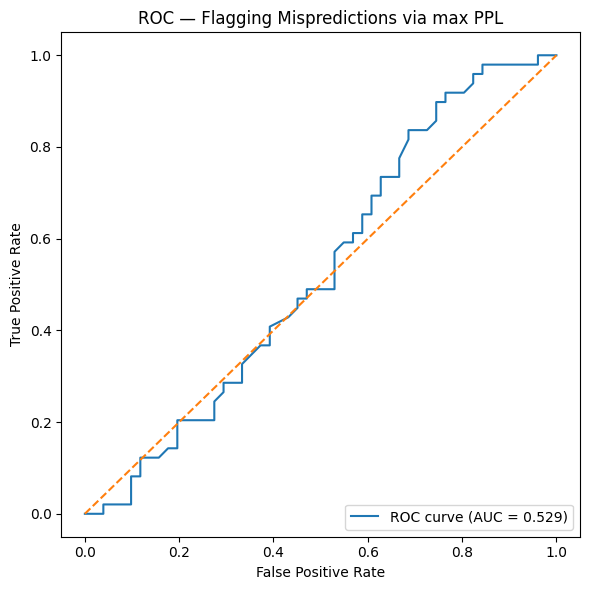

At best_thresh: TP=44, FP=39, FN=5, TN=12, Precision=0.5301, Recall=0.8980, F1=0.6667


In [83]:
# --- ROC curve & AUC (mispred = positive class) ---
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

y_true  = is_mispred.astype(int)   # 1 = mispredicted, 0 = correct
y_score = max_ppl.astype(float)    # continuous "risk" score

fpr, tpr, thresh = roc_curve(y_true, y_score, pos_label=1)
roc_auc = auc(fpr, tpr)
print(f"\nROC-AUC (mispred as positive): {roc_auc:.4f}")

# Optional: pick an operating point (Youden's J = TPR - FPR)
j_idx = np.argmax(tpr - fpr)
best_thresh = thresh[j_idx]
print(f"Best threshold by Youden's J: {best_thresh:.6f} | TPR={tpr[j_idx]:.3f}, FPR={fpr[j_idx]:.3f}")

# Plot
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — Flagging Mispredictions via max PPL")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# (Optional) Evaluate confusion metrics at the chosen threshold to match your table
def eval_at(th):
    mask = (y_score > th)
    TP = int(((mask == 1) & (y_true == 1)).sum())
    FP = int(((mask == 1) & (y_true == 0)).sum())
    FN = int(((mask == 0) & (y_true == 1)).sum())
    TN = int(((mask == 0) & (y_true == 0)).sum())
    prec = TP / (TP + FP) if (TP + FP) else 0.0
    rec  = TP / (TP + FN) if (TP + FN) else 0.0
    f1   = (2*prec*rec)/(prec+rec) if (prec+rec) else 0.0
    return TP, FP, FN, TN, prec, rec, f1

TP, FP, FN, TN, prec, rec, f1 = eval_at(best_thresh)
print(f"At best_thresh: TP={TP}, FP={FP}, FN={FN}, TN={TN}, Precision={prec:.4f}, Recall={rec:.4f}, F1={f1:.4f}")


=== Metrics at Selected Perplexity Thresholds ===
 Threshold (PPL > th)  TP  FP  FN  TN  Precision  Recall     F1
             1.000000  49  51   0   0     0.4900  1.0000 0.6577
             1.000028  44  39   5  12     0.5301  0.8980 0.6667
             1.000100  40  35   9  16     0.5333  0.8163 0.6452
             1.000200  36  34  13  17     0.5143  0.7347 0.6050
             1.000300  34  32  15  19     0.5152  0.6939 0.5913
             1.000400  34  32  15  19     0.5152  0.6939 0.5913
             1.000500  34  31  15  20     0.5231  0.6939 0.5965
             1.000600  33  31  16  20     0.5156  0.6735 0.5841
             1.000700  33  31  16  20     0.5156  0.6735 0.5841
             1.000800  33  31  16  20     0.5156  0.6735 0.5841
             1.000900  33  31  16  20     0.5156  0.6735 0.5841
             1.001000  32  31  17  20     0.5079  0.6531 0.5714


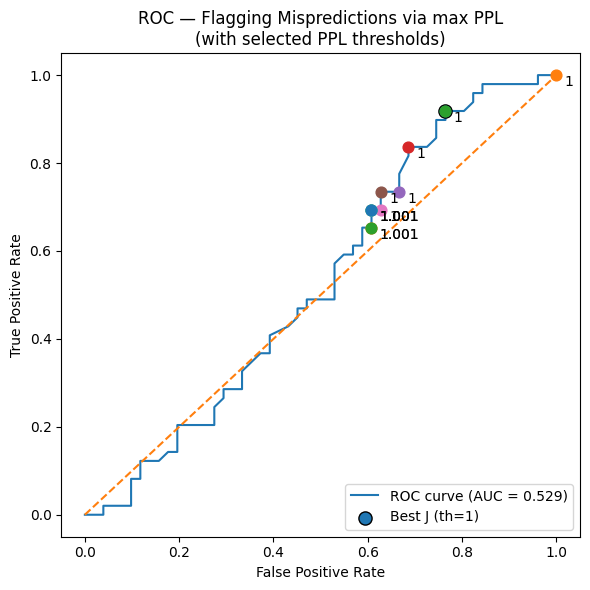

In [84]:
import pandas as pd
import numpy as np

# --- Choose thresholds to report/mark (include your table's values + best J) ---
chosen_ths = [1.00, 1.0001, 1.0002, 1.0003, 1.0004, 1.0005, 1.0006, 1.0007, 1.0008, 1.0009, 1.001]
# chosen_ths = [1.00, 1.0005, 1.001, 1.002, 1.003, 1.004, 1.005, 1.006, 1.007, 1.008, 1.009, 1.01, 1.02, 1.05]
chosen_ths.append(float(best_thresh))
chosen_ths = sorted(set(chosen_ths))

# --- Compute metrics at each chosen threshold ---
rows = []
for th in chosen_ths:
    TP, FP, FN, TN, prec, rec, f1 = eval_at(th)
    rows.append({
        "Threshold (PPL > th)": th,
        "TP": TP, "FP": FP, "FN": FN, "TN": TN,
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1": round(f1, 4),
    })

df_thresh = pd.DataFrame(rows)
print("\n=== Metrics at Selected Perplexity Thresholds ===")
print(df_thresh.to_string(index=False))

# --- Build a (fpr,tpr,threshold) DataFrame (filter out inf) for plotting helpers ---
roc_df = pd.DataFrame({"FPR": fpr, "TPR": tpr, "th": thresh})
roc_df = roc_df[np.isfinite(roc_df["th"])]

# --- Plot again with dots + labels for the chosen thresholds (nearest ROC points) ---
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--")

# mark best J
plt.scatter([fpr[j_idx]], [tpr[j_idx]], s=90, marker="o", edgecolors="k", zorder=3,
            label=f"Best J (th={best_thresh:.4g})")

# mark selected thresholds
for th in chosen_ths:
    # find nearest ROC threshold index
    idx = int(np.argmin(np.abs(thresh - th)))
    x, y = fpr[idx], tpr[idx]
    plt.scatter([x], [y], s=60, zorder=3)
    plt.annotate(f"{th:.4g}", (x, y), textcoords="offset points", xytext=(6, -8))

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC — Flagging Mispredictions via max PPL\n(with selected PPL thresholds)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


### Round 5 - (Train : 500, Test : 500)

In [19]:
# === Batch 3-shot (k=3) few-shot labeling for up to 500 posts WITH per-label OUTPUT perplexity (no ground truth) ===
import pandas as pd, json, time, copy, re
from pathlib import Path

# -------- Paths --------
PERP_DIR        = Path("/home/ubuntu/tw_rp_main/Perplexity Files")
PERP_DIR.mkdir(parents=True, exist_ok=True)

INPUT_CSV       = "/home/ubuntu/tw_rp_main/jupyter-notebooks/training_sets/train_20251002_043005.csv"
OUTPUT_CSV      = PERP_DIR / "predicted_labels_with_label_PPL_500_k3_R5.csv"
EXAMPLES_JSON   = Path("/home/ubuntu/tw_rp_main/used_examples/used_examples_for_500_posts_K_3_R5.json")

# Ensure used_examples dir exists
EXAMPLES_JSON.parent.mkdir(parents=True, exist_ok=True)

YESNO_RE = re.compile(r"\b(YES|NO)\b", re.IGNORECASE)

# Label order
LABELS_ORDER = [
    "Abuse",
    "Aggression",
    "Sexual",
    "Medical",
    "Mental Health",
    "Discrimination",
    "Pregnancy",
    "Not Applicable",
]

# --- taxonomy definitions fallback ---
if 'definitions' not in globals():
    definitions = {lbl: "" for lbl in LABELS_ORDER}

labels = LABELS_ORDER
collected_examples_per_label = {}

def extract_yes_no(resp) -> str:
    """Coerce model output to YES/NO; accepts dicts and strings."""
    if resp is None:
        return "NO"
    if isinstance(resp, dict):
        if "text" in resp and isinstance(resp["text"], str):
            resp = resp["text"]
        elif "content" in resp and isinstance(resp["content"], str):
            resp = resp["content"]
        else:
            resp = str(resp)
    if not isinstance(resp, str):
        resp = str(resp)
    line = resp.strip().splitlines()[0] if resp.strip() else ""
    m = YESNO_RE.search(line)
    if m:
        return "YES" if m.group(1).upper() == "YES" else "NO"
    tok = line.upper().split()[:1]
    return "YES" if (tok and tok[0] == "YES") else "NO"

def tiny_throttle(sec=0.35):
    try:
        time.sleep(sec)
    except Exception:
        pass

# --- load input posts ---
df_in = pd.read_csv(INPUT_CSV)
if not {'title','selftext'}.issubset(df_in.columns):
    raise KeyError("INPUT_CSV must contain 'title' and 'body' columns.")

# Dynamically choose up to 500 rows
N_POSTS = min(500, len(df_in))
subset = df_in[['title','selftext']].iloc[:N_POSTS].fillna('').astype(str)
TOTAL = len(subset)

rows_out = []
all_used_examples = []

for i, (_, row) in enumerate(subset.iterrows(), start=1):
    title = row['title']
    body  = row['selftext']

    collected_examples_per_label = {}

    # Populate cosine neighbors (does not change prompt text)
    _ = make_multishot_prompt_cosine(
        k=3,
        title=title,
        body=body,
        current_index=None,
        include_defs=True,
        debug=False
    )

    yes_labels = []
    per_label_ppl = {}
    per_label_lines = []

    for idx_lbl, lbl in enumerate(LABELS_ORDER, start=1):
        prompt = make_prompt_for_label(
            label_name=lbl,
            k=3,
            title=title,
            body=body,
            current_index=None,
            debug=False
        )

        resp = getTriggerWarningsLLMResponse(
            prompt,
            mode="binary",
            max_tokens=4,
            temperature=0.0,
            verbose=False
        )

        ans = extract_yes_no(resp)
        per_label_ppl[lbl] = float(resp.get("ppl", float("nan")))

        if ans not in ("YES", "NO"):
            resp2 = getTriggerWarningsLLMResponse(
                prompt,
                mode="binary",
                max_tokens=8,
                temperature=0.0,
                verbose=False
            )
            ans = extract_yes_no(resp2)
            per_label_ppl[lbl] = float(resp2.get("ppl", per_label_ppl[lbl]))

        if ans == "YES":
            yes_labels.append(lbl)

        per_label_lines.append(f"[post {i}/{TOTAL}] label {idx_lbl}/8: {lbl}")
        dbg = (resp.get("text","") or "")[:120].replace("\n"," ")
        per_label_lines.append(f"Post {i}, Label '{lbl}': {dbg!r} -> {ans}, PPL_out={per_label_ppl[lbl]:.4f}")

        tiny_throttle(0.12)

    if not yes_labels:
        yes_labels = ["Not Applicable"]

    # ---- YES-only summary ----
    yes_ppl_items, yes_ppl_values = [], []
    for lbl in yes_labels:
        v = per_label_ppl.get(lbl, float("nan"))
        yes_ppl_items.append(f"{lbl}:{(f'{v:.4f}' if (v==v) else 'NaN')}")
        if v == v:
            yes_ppl_values.append(v)

    mean_yes = (sum(yes_ppl_values)/len(yes_ppl_values)) if yes_ppl_values else float("nan")
    max_yes  = max(yes_ppl_values) if yes_ppl_values else float("nan")

    mean_str = f"{mean_yes:.4f}" if (mean_yes==mean_yes) else "NaN"
    max_str  = f"{max_yes:.4f}"  if (max_yes==max_yes) else "NaN"

    # Print progress
    print(f"{i}. YES labels: {yes_labels} | YES-PPLs[{', '.join(yes_ppl_items)}] |")
    print(f"=== Working on post {i}/{TOTAL} ===")
    for line in per_label_lines:
        print(line)
    print(f"meanPPL_yes={mean_str} | maxPPL_yes={max_str}")

    out_row = {
        "title": title,
        "body": body,
        "PredictedLabels": json.dumps(yes_labels, ensure_ascii=False)
    }
    for lbl in LABELS_ORDER:
        out_row[f"PPL_{lbl}"] = per_label_ppl.get(lbl, float("nan"))
    rows_out.append(out_row)

    snapshot = copy.deepcopy(collected_examples_per_label) if 'collected_examples_per_label' in globals() else {}
    all_used_examples.append({
        "post_index_1_based": i,
        "title": title,
        "body": body,
        "examples_by_label": snapshot
    })

# --- save CSV ---
df_out = pd.DataFrame(rows_out)
df_out.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")
print(f"\n✅ Saved predicted labels + per-label OUTPUT PPL to {OUTPUT_CSV}")

# --- save used examples JSON ---
with open(EXAMPLES_JSON, "w", encoding="utf-8") as f:
    json.dump(all_used_examples, f, indent=2, ensure_ascii=False)
print(f"✅ Saved used examples (cosine-picked) to {EXAMPLES_JSON}")


1. YES labels: ['Mental Health', 'Pregnancy'] | YES-PPLs[Mental Health:1.0000, Pregnancy:1.0000] |
=== Working on post 1/500 ===
[post 1/500] label 1/8: Abuse
Post 1, Label 'Abuse': 'NO' -> NO, PPL_out=1.0000
[post 1/500] label 2/8: Aggression
Post 1, Label 'Aggression': 'NO' -> NO, PPL_out=1.0000
[post 1/500] label 3/8: Sexual
Post 1, Label 'Sexual': 'NO' -> NO, PPL_out=1.0000
[post 1/500] label 4/8: Medical
Post 1, Label 'Medical': 'NO' -> NO, PPL_out=1.0000
[post 1/500] label 5/8: Mental Health
Post 1, Label 'Mental Health': 'YES' -> YES, PPL_out=1.0000
[post 1/500] label 6/8: Discrimination
Post 1, Label 'Discrimination': 'NO' -> NO, PPL_out=1.0000
[post 1/500] label 7/8: Pregnancy
Post 1, Label 'Pregnancy': 'YES' -> YES, PPL_out=1.0000
[post 1/500] label 8/8: Not Applicable
Post 1, Label 'Not Applicable': 'NO' -> NO, PPL_out=1.0000
meanPPL_yes=1.0000 | maxPPL_yes=1.0000
2. YES labels: ['Abuse', 'Aggression', 'Mental Health', 'Pregnancy'] | YES-PPLs[Abuse:1.0388, Aggression:1.0025,

In [20]:
# === Split posts above/below a PPL threshold & export IDs for re-annotation ===
import pandas as pd, ast, re
from pathlib import Path

# ---------- Inputs ----------
PRED_PATH = "/home/ubuntu/tw_rp_main/Perplexity Files/predicted_labels_with_label_PPL_500_k3_R5.csv"
OUT_DIR   = Path("/home/ubuntu/tw_rp_main/Perplexity Files/reannotation_batch_1")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------- Config ----------
SCORE_COL      = "max_ppl"   # choose: "max_ppl" or "mean_yes_ppl"
ABS_THRESHOLD  = 1.0002        # set a numeric cutoff (e.g., 1.02). If None, QUANTILE will be used.
QUANTILE       = None        # e.g., 0.90 to flag top 10% worst. Ignored if ABS_THRESHOLD is set.

# ---------- Helpers ----------
def parse_listlike(text):
    if isinstance(text, list): return [str(t).strip() for t in text]
    if pd.isna(text): return []
    s = str(text).strip()
    try:
        v = ast.literal_eval(s)
        if isinstance(v, list): return [str(t).strip() for t in v]
        if isinstance(v, str): s = v
    except Exception:
        pass
    s = s.strip("[]()")
    return [p.strip() for p in re.split(r"[,\|;/]", s) if p.strip()]

def ensure_scores(df: pd.DataFrame) -> pd.DataFrame:
    # Build max_ppl from all PPL_* columns
    ppl_cols = [c for c in df.columns if c.startswith("PPL_")]
    if not ppl_cols:
        raise RuntimeError("No PPL_* columns found in the predictions file.")
    if "max_ppl" not in df.columns:
        df["max_ppl"] = df[ppl_cols].max(axis=1)

    # Build mean_yes_ppl if needed
    if "mean_yes_ppl" not in df.columns:
        def mean_yes_ppl_row(row):
            yes = parse_listlike(row.get("PredictedLabels", ""))
            if not yes: return float("nan")
            vals = []
            for lbl in yes:
                col = f"PPL_{lbl}"
                if col in row.index:
                    try: vals.append(float(row[col]))
                    except: pass
            return (sum(vals)/len(vals)) if vals else float("nan")
        df["mean_yes_ppl"] = df.apply(mean_yes_ppl_row, axis=1)
    return df

def pick_id_column(df: pd.DataFrame) -> str:
    """Return the best available ID-like column or create a fallback text key."""
    candidates = [c for c in ["post_id","id","ID","PostID","Index","unique_key"] if c in df.columns]
    if candidates:
        return candidates[0]
    # build a fallback key from text (stable enough for re-annotation join)
    norm = lambda s: re.sub(r"\s+", " ", ("" if pd.isna(s) else str(s)).strip().lower())
    df["_text_key"] = df.get("title","").apply(norm) + " || " + df.get("body","").apply(norm)
    return "_text_key"

# ---------- Load predictions ----------
df = pd.read_csv(PRED_PATH)
df.columns = [c.strip() for c in df.columns]
if "PredictedLabels" not in df.columns:
    raise RuntimeError("Predictions file must contain 'PredictedLabels'.")

df = ensure_scores(df)
id_col = pick_id_column(df)

# ---------- Choose threshold ----------
series = df[SCORE_COL].astype(float)
if ABS_THRESHOLD is not None:
    thr = float(ABS_THRESHOLD)
    rule_label = f"{SCORE_COL} >= {thr:.6f}"
else:
    q = float(QUANTILE) if QUANTILE is not None else 0.90
    thr = series.quantile(q)
    rule_label = f"{SCORE_COL} >= {thr:.6f}  (>= {int(q*100)}th percentile)"

# ---------- Split above/below ----------
mask_flag   = series >= thr
flagged_df  = df[mask_flag].copy()
not_flagged = df[~mask_flag].copy()

# ---------- Minimal columns for the re-annotation file ----------
keep_cols = [id_col, "title", "body", "PredictedLabels", SCORE_COL]
keep_cols = [c for c in keep_cols if c in df.columns]  # guard missing
flagged_min = flagged_df[keep_cols].copy()
not_flagged_min = not_flagged[keep_cols].copy()

# --- after computing `not_flagged` and `not_flagged_min` ---

# Save minimal + FULL versions
flag_path        = OUT_DIR / f"flagged_for_reannotation_{SCORE_COL}_Round5.csv"
ok_path_min      = OUT_DIR / f"not_flagged_{SCORE_COL}_Round5.csv"               # minimal (already present)

flagged_min.to_csv(flag_path, index=False)
not_flagged_min.to_csv(ok_path_min, index=False)

# --- Report ---
total = len(df)
n_flag = len(flagged_df)
n_ok   = len(not_flagged)
pct = (n_flag / total * 100.0) if total else 0.0

print("\n=== Re-annotation Batch Summary ===")
print(f"Scoring column:      {SCORE_COL}")
print(f"Threshold rule:      {rule_label}")
print(f"Total posts:         {total}")
print(f"Flagged (>= thr):    {n_flag}  ({pct:.2f}%)")
print(f"Below threshold:     {n_ok}  ({100.0 - pct:.2f}%)")
print(f"\nSaved flagged CSV:           {flag_path}")
print(f"Saved non-flagged (minimal): {ok_path_min}")



=== Re-annotation Batch Summary ===
Scoring column:      max_ppl
Threshold rule:      max_ppl >= 1.000200
Total posts:         500
Flagged (>= thr):    412  (82.40%)
Below threshold:     88  (17.60%)

Saved flagged CSV:           /home/ubuntu/tw_rp_main/Perplexity Files/reannotation_batch_1/flagged_for_reannotation_max_ppl_Round5.csv
Saved non-flagged (minimal): /home/ubuntu/tw_rp_main/Perplexity Files/reannotation_batch_1/not_flagged_max_ppl_Round5.csv


### Round NA - (Train : 500, Test : 26, 56, 115)

In [39]:
# ---- Cell 2 ----
# === Batch 3-shot (k=3) few-shot labeling for up to 500 posts WITH per-label OUTPUT perplexity (no ground truth) ===
import pandas as pd, json, time, copy, re
from pathlib import Path

# -------- Paths --------
PERP_DIR        = Path("/home/ubuntu/tw_rp_main/Perplexity Files")
PERP_DIR.mkdir(parents=True, exist_ok=True)

INPUT_CSV       = "/home/ubuntu/tw_rp_main/datasets/NA.csv"
OUTPUT_CSV      = PERP_DIR / "predicted_labels_with_label_PPL_500_k3_NA.csv"
EXAMPLES_JSON   = Path("/home/ubuntu/tw_rp_main/used_examples/used_examples_for_500_posts_K_3_NA.json")
EXAMPLES_JSON.parent.mkdir(parents=True, exist_ok=True)

YESNO_RE = re.compile(r"\b(YES|NO)\b", re.IGNORECASE)

# Label order
LABELS_ORDER = [
    "Abuse",
    "Aggression",
    "Sexual",
    "Medical",
    "Mental Health",
    "Discrimination",
    "Pregnancy",
    "Not Applicable",
]

# --- taxonomy definitions fallback ---
if 'definitions' not in globals():
    definitions = {lbl: "" for lbl in LABELS_ORDER}

labels = LABELS_ORDER
REAL_LABELS = [l for l in LABELS_ORDER if l != "Not Applicable"]

collected_examples_per_label = {}

def extract_yes_no(resp) -> str:
    """Coerce model output to YES/NO; accepts dicts and strings."""
    if resp is None:
        return "NO"
    if isinstance(resp, dict):
        if "text" in resp and isinstance(resp["text"], str):
            resp = resp["text"]
        elif "content" in resp and isinstance(resp["content"], str):
            resp = resp["content"]
        else:
            resp = str(resp)
    if not isinstance(resp, str):
        resp = str(resp)
    line = resp.strip().splitlines()[0] if resp.strip() else ""
    m = YESNO_RE.search(line)
    if m:
        return "YES" if m.group(1).upper() == "YES" else "NO"
    tok = line.upper().split()[:1]
    return "YES" if (tok and tok[0] == "YES") else "NO"

def tiny_throttle(sec=0.12):
    try:
        time.sleep(sec)
    except Exception:
        pass

# --- load input posts ---
df_in = pd.read_csv(INPUT_CSV)

# Resolve columns (case-insensitive + aliases)
TITLE_CANDS = ["title","post_title","headline","subject"]
BODY_CANDS  = ["selftext","body","text","description","content"]

def _find_col(df_, cands, kind):
    for c in cands:
        if c in df_.columns: return c
    lower = {c.lower(): c for c in df_.columns}
    for c in cands:
        if c.lower() in lower: return lower[c.lower()]
    raise KeyError(f"No {kind} column found. Tried {cands}. Available: {list(df_.columns)}")

TITLE_COL = _find_col(df_in, TITLE_CANDS, "TITLE")
BODY_COL  = _find_col(df_in, BODY_CANDS,  "BODY")

# Dynamically choose up to 500 rows
N_POSTS = min(500, len(df_in))
subset = df_in[[TITLE_COL, BODY_COL]].iloc[:N_POSTS].fillna('').astype(str)
TOTAL = len(subset)

# ---------- Domain Gate (heuristic + optional LLM confirm) ----------
A_MS_RE = re.compile(
    r"\b(abortion|abort(ed|ing)?|miscarriage|termination of pregnancy|pregnancy termination|rape|sexual\s+violence|sexual\s+assault|SA\b)\b",
    re.IGNORECASE
)

def domain_gate_llm(title: str, body: str) -> str:
    """
    Call your LLM to confirm domain if heuristic says NO.
    Requires `getTriggerWarningsLLMResponse` to be available in the environment.
    """
    prompt = (
        "You are a strict gatekeeper.\n"
        "Question: Is this post CLEARLY about abortion, miscarriage, or sexual violence (A/M/SV)?\n"
        "Answer strictly YES or NO.\n\n"
        f"Title: {title.strip()}\n\n"
        f"Description: {body.strip()}\n\n"
        "Answer:"
    )
    resp = getTriggerWarningsLLMResponse(
        prompt, mode="binary", max_tokens=3, temperature=0.0, verbose=False
    )
    return extract_yes_no(resp)  # "YES" / "NO"

rows_out = []
all_used_examples = []

for i, (_, row) in enumerate(subset.iterrows(), start=1):
    title = row[TITLE_COL]
    body  = row[BODY_COL]

    collected_examples_per_label = {}

    # ---------- Domain Gate ----------
    gate_heur = "YES" if A_MS_RE.search(f"{title}\n{body}") else "NO"
    gate = gate_heur if gate_heur == "YES" else domain_gate_llm(title, body)

    yes_labels = []
    per_label_ppl = {}
    per_label_lines = []

    if gate == "NO":
        # Outside domain → ONLY NA; skip evaluating other labels entirely
        for lbl in LABELS_ORDER:
            per_label_ppl[lbl] = float("nan")
        yes_labels = ["Not Applicable"]

        print(f"{i}. DOMAIN=NO → YES labels: {yes_labels}")
        out_row = {
            "title": title,
            "body": body,
            "PredictedLabels": json.dumps(yes_labels, ensure_ascii=False)
        }
        for lbl in LABELS_ORDER:
            out_row[f"PPL_{lbl}"] = per_label_ppl.get(lbl, float("nan"))
        rows_out.append(out_row)

        # Still record structure for examples (empty)
        all_used_examples.append({
            "post_index_1_based": i,
            "title": title,
            "body": body,
            "examples_by_label": {}
        })
        continue  # next post

    # ---------- DOMAIN = YES ----------
    # Force NA = NO by not evaluating it at all; only the seven real labels
    _ = make_multishot_prompt_cosine(
        k=3,
        title=title,
        body=body,
        current_index=None,
        include_defs=True,
        debug=False
    )

    for idx_lbl, lbl in enumerate(REAL_LABELS, start=1):
        prompt = make_prompt_for_label(
            label_name=lbl,
            k=3,
            title=title,
            body=body,
            current_index=None,
            debug=False
        )

        resp = getTriggerWarningsLLMResponse(
            prompt,
            mode="binary",
            max_tokens=4,
            temperature=0.0,
            verbose=False
        )

        ans = extract_yes_no(resp)
        per_label_ppl[lbl] = float(resp.get("ppl", float("nan")))

        if ans not in ("YES", "NO"):
            resp2 = getTriggerWarningsLLMResponse(
                prompt,
                mode="binary",
                max_tokens=8,
                temperature=0.0,
                verbose=False
            )
            ans = extract_yes_no(resp2)
            per_label_ppl[lbl] = float(resp2.get("ppl", per_label_ppl[lbl]))

        if ans == "YES":
            yes_labels.append(lbl)

        per_label_lines.append(f"[post {i}/{TOTAL}] label {idx_lbl}/7: {lbl}")
        dbg = (resp.get("text","") or "")[:120].replace("\n"," ")
        per_label_lines.append(f"Post {i}, Label '{lbl}': {dbg!r} -> {ans}, PPL_out={per_label_ppl[lbl]:.4f}")

        tiny_throttle(0.12)

    # In-domain + no matches → keep empty; DO NOT add NA
    # (Optional) If you prefer a fallback, you could set NA here, but that would break exclusivity.

    # ---- YES-only summary ----
    yes_ppl_items, yes_ppl_values = [], []
    for lbl in yes_labels:
        v = per_label_ppl.get(lbl, float("nan"))
        yes_ppl_items.append(f"{lbl}:{(f'{v:.4f}' if (v==v) else 'NaN')}")
        if v == v:
            yes_ppl_values.append(v)

    mean_yes = (sum(yes_ppl_values)/len(yes_ppl_values)) if yes_ppl_values else float("nan")
    max_yes  = max(yes_ppl_values) if yes_ppl_values else float("nan")

    mean_str = f"{mean_yes:.4f}" if (mean_yes==mean_yes) else "NaN"
    max_str  = f"{max_yes:.4f}"  if (max_yes==max_yes) else "NaN"

    # Print progress
    print(f"{i}. DOMAIN=YES → YES labels: {yes_labels} | YES-PPLs[{', '.join(yes_ppl_items)}] |")
    print(f"=== Working on post {i}/{TOTAL} ===")
    for line in per_label_lines:
        print(line)
    print(f"meanPPL_yes={mean_str} | maxPPL_yes={max_str}")

    out_row = {
        "title": title,
        "body": body,
        "PredictedLabels": json.dumps(yes_labels, ensure_ascii=False)
    }
    for lbl in LABELS_ORDER:
        out_row[f"PPL_{lbl}"] = per_label_ppl.get(lbl, float("nan"))
    rows_out.append(out_row)

    snapshot = copy.deepcopy(collected_examples_per_label) if 'collected_examples_per_label' in globals() else {}
    all_used_examples.append({
        "post_index_1_based": i,
        "title": title,
        "body": body,
        "examples_by_label": snapshot
    })

# --- save CSV ---
df_out = pd.DataFrame(rows_out)
df_out.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")
print(f"\n✅ Saved predicted labels + per-label OUTPUT PPL to {OUTPUT_CSV}")

# --- save used examples JSON ---
with open(EXAMPLES_JSON, "w", encoding="utf-8") as f:
    json.dump(all_used_examples, f, indent=2, ensure_ascii=False)
print(f"✅ Saved used examples (cosine-picked) to {EXAMPLES_JSON}")


1. DOMAIN=NO → YES labels: ['Not Applicable']
2. DOMAIN=NO → YES labels: ['Not Applicable']
3. DOMAIN=NO → YES labels: ['Not Applicable']
4. DOMAIN=NO → YES labels: ['Not Applicable']
5. DOMAIN=NO → YES labels: ['Not Applicable']
6. DOMAIN=NO → YES labels: ['Not Applicable']
7. DOMAIN=NO → YES labels: ['Not Applicable']
8. DOMAIN=NO → YES labels: ['Not Applicable']
9. DOMAIN=NO → YES labels: ['Not Applicable']
10. DOMAIN=NO → YES labels: ['Not Applicable']
11. DOMAIN=NO → YES labels: ['Not Applicable']
12. DOMAIN=NO → YES labels: ['Not Applicable']
13. DOMAIN=NO → YES labels: ['Not Applicable']
14. DOMAIN=NO → YES labels: ['Not Applicable']
15. DOMAIN=NO → YES labels: ['Not Applicable']
16. DOMAIN=NO → YES labels: ['Not Applicable']
17. DOMAIN=NO → YES labels: ['Not Applicable']
18. DOMAIN=YES → YES labels: ['Pregnancy'] | YES-PPLs[Pregnancy:1.1738] |
=== Working on post 18/26 ===
[post 18/26] label 1/7: Abuse
Post 18, Label 'Abuse': 'NO' -> NO, PPL_out=1.0000
[post 18/26] label 2/7: A

In [45]:
# ---- Cell 2 ----
# === Batch 3-shot (k=3) few-shot labeling for up to 500 posts WITH per-label OUTPUT perplexity (no ground truth) ===
import pandas as pd, json, time, copy, re
from pathlib import Path

# -------- Paths --------
PERP_DIR        = Path("/home/ubuntu/tw_rp_main/Perplexity Files")
PERP_DIR.mkdir(parents=True, exist_ok=True)

INPUT_CSV       = "/home/ubuntu/tw_rp_main/datasets/NALabelCo.csv"
OUTPUT_CSV      = PERP_DIR / "predicted_labels_with_label_PPL_500_k3_NA_R2.csv"
EXAMPLES_JSON   = Path("/home/ubuntu/tw_rp_main/used_examples/used_examples_for_500_posts_K_3_NA_R2.json")
EXAMPLES_JSON.parent.mkdir(parents=True, exist_ok=True)

YESNO_RE = re.compile(r"\b(YES|NO)\b", re.IGNORECASE)

# Label order
LABELS_ORDER = [
    "Abuse",
    "Aggression",
    "Sexual",
    "Medical",
    "Mental Health",
    "Discrimination",
    "Pregnancy",
    "Not Applicable",
]

# --- taxonomy definitions fallback ---
if 'definitions' not in globals():
    definitions = {lbl: "" for lbl in LABELS_ORDER}

labels = LABELS_ORDER
REAL_LABELS = [l for l in LABELS_ORDER if l != "Not Applicable"]

collected_examples_per_label = {}

def extract_yes_no(resp) -> str:
    """Coerce model output to YES/NO; accepts dicts and strings."""
    if resp is None:
        return "NO"
    if isinstance(resp, dict):
        if "text" in resp and isinstance(resp["text"], str):
            resp = resp["text"]
        elif "content" in resp and isinstance(resp["content"], str):
            resp = resp["content"]
        else:
            resp = str(resp)
    if not isinstance(resp, str):
        resp = str(resp)
    line = resp.strip().splitlines()[0] if resp.strip() else ""
    m = YESNO_RE.search(line)
    if m:
        return "YES" if m.group(1).upper() == "YES" else "NO"
    tok = line.upper().split()[:1]
    return "YES" if (tok and tok[0] == "YES") else "NO"

def tiny_throttle(sec=0.12):
    try:
        time.sleep(sec)
    except Exception:
        pass

# --- load input posts ---
df_in = pd.read_csv(INPUT_CSV)

# Resolve columns (case-insensitive + aliases)
TITLE_CANDS = ["title","post_title","headline","subject"]
BODY_CANDS  = ["selftext","body","text","description","content"]

def _find_col(df_, cands, kind):
    for c in cands:
        if c in df_.columns: return c
    lower = {c.lower(): c for c in df_.columns}
    for c in cands:
        if c.lower() in lower: return lower[c.lower()]
    raise KeyError(f"No {kind} column found. Tried {cands}. Available: {list(df_.columns)}")

TITLE_COL = _find_col(df_in, TITLE_CANDS, "TITLE")
BODY_COL  = _find_col(df_in, BODY_CANDS,  "BODY")

# Dynamically choose up to 500 rows
N_POSTS = min(500, len(df_in))
subset = df_in[[TITLE_COL, BODY_COL]].iloc[:N_POSTS].fillna('').astype(str)
TOTAL = len(subset)

# ---------- Domain Gate (heuristic + optional LLM confirm) ----------
A_MS_RE = re.compile(
    r"\b(abortion|abort(ed|ing)?|miscarriage|termination of pregnancy|pregnancy termination|rape|sexual\s+violence|sexual\s+assault|SA\b)\b",
    re.IGNORECASE
)

def domain_gate_llm(title: str, body: str) -> str:
    """
    Call your LLM to confirm domain if heuristic says NO.
    Requires `getTriggerWarningsLLMResponse` to be available in the environment.
    """
    prompt = (
        "You are a strict gatekeeper.\n"
        "Question: Is this post CLEARLY about abortion, miscarriage, or sexual violence (A/M/SV)?\n"
        "Answer strictly YES or NO.\n\n"
        f"Title: {title.strip()}\n\n"
        f"Description: {body.strip()}\n\n"
        "Answer:"
    )
    resp = getTriggerWarningsLLMResponse(
        prompt, mode="binary", max_tokens=3, temperature=0.0, verbose=False
    )
    return extract_yes_no(resp)  # "YES" / "NO"

rows_out = []
all_used_examples = []

for i, (_, row) in enumerate(subset.iterrows(), start=1):
    title = row[TITLE_COL]
    body  = row[BODY_COL]

    collected_examples_per_label = {}

    # ---------- Domain Gate ----------
    gate_heur = "YES" if A_MS_RE.search(f"{title}\n{body}") else "NO"
    gate = gate_heur if gate_heur == "YES" else domain_gate_llm(title, body)

    yes_labels = []
    per_label_ppl = {}
    per_label_lines = []

    if gate == "NO":
        # Outside domain → ONLY NA; skip evaluating other labels entirely
        for lbl in LABELS_ORDER:
            per_label_ppl[lbl] = float("nan")
        yes_labels = ["Not Applicable"]

        print(f"{i}. DOMAIN=NO → YES labels: {yes_labels}")
        out_row = {
            "title": title,
            "body": body,
            "PredictedLabels": json.dumps(yes_labels, ensure_ascii=False)
        }
        for lbl in LABELS_ORDER:
            out_row[f"PPL_{lbl}"] = per_label_ppl.get(lbl, float("nan"))
        rows_out.append(out_row)

        # Still record structure for examples (empty)
        all_used_examples.append({
            "post_index_1_based": i,
            "title": title,
            "body": body,
            "examples_by_label": {}
        })
        continue  # next post

    # ---------- DOMAIN = YES ----------
    # Force NA = NO by not evaluating it at all; only the seven real labels
    _ = make_multishot_prompt_cosine(
        k=3,
        title=title,
        body=body,
        current_index=None,
        include_defs=True,
        debug=False
    )

    for idx_lbl, lbl in enumerate(REAL_LABELS, start=1):
        prompt = make_prompt_for_label(
            label_name=lbl,
            k=3,
            title=title,
            body=body,
            current_index=None,
            debug=False
        )

        resp = getTriggerWarningsLLMResponse(
            prompt,
            mode="binary",
            max_tokens=4,
            temperature=0.0,
            verbose=False
        )

        ans = extract_yes_no(resp)
        per_label_ppl[lbl] = float(resp.get("ppl", float("nan")))

        if ans not in ("YES", "NO"):
            resp2 = getTriggerWarningsLLMResponse(
                prompt,
                mode="binary",
                max_tokens=8,
                temperature=0.0,
                verbose=False
            )
            ans = extract_yes_no(resp2)
            per_label_ppl[lbl] = float(resp2.get("ppl", per_label_ppl[lbl]))

        if ans == "YES":
            yes_labels.append(lbl)

        per_label_lines.append(f"[post {i}/{TOTAL}] label {idx_lbl}/7: {lbl}")
        dbg = (resp.get("text","") or "")[:120].replace("\n"," ")
        per_label_lines.append(f"Post {i}, Label '{lbl}': {dbg!r} -> {ans}, PPL_out={per_label_ppl[lbl]:.4f}")

        tiny_throttle(0.12)

    # In-domain + no matches → keep empty; DO NOT add NA
    # (Optional) If you prefer a fallback, you could set NA here, but that would break exclusivity.

    # ---- YES-only summary ----
    yes_ppl_items, yes_ppl_values = [], []
    for lbl in yes_labels:
        v = per_label_ppl.get(lbl, float("nan"))
        yes_ppl_items.append(f"{lbl}:{(f'{v:.4f}' if (v==v) else 'NaN')}")
        if v == v:
            yes_ppl_values.append(v)

    mean_yes = (sum(yes_ppl_values)/len(yes_ppl_values)) if yes_ppl_values else float("nan")
    max_yes  = max(yes_ppl_values) if yes_ppl_values else float("nan")

    mean_str = f"{mean_yes:.4f}" if (mean_yes==mean_yes) else "NaN"
    max_str  = f"{max_yes:.4f}"  if (max_yes==max_yes) else "NaN"

    # Print progress
    print(f"{i}. DOMAIN=YES → YES labels: {yes_labels} | YES-PPLs[{', '.join(yes_ppl_items)}] |")
    print(f"=== Working on post {i}/{TOTAL} ===")
    for line in per_label_lines:
        print(line)
    print(f"meanPPL_yes={mean_str} | maxPPL_yes={max_str}")

    out_row = {
        "title": title,
        "body": body,
        "PredictedLabels": json.dumps(yes_labels, ensure_ascii=False)
    }
    for lbl in LABELS_ORDER:
        out_row[f"PPL_{lbl}"] = per_label_ppl.get(lbl, float("nan"))
    rows_out.append(out_row)

    snapshot = copy.deepcopy(collected_examples_per_label) if 'collected_examples_per_label' in globals() else {}
    all_used_examples.append({
        "post_index_1_based": i,
        "title": title,
        "body": body,
        "examples_by_label": snapshot
    })

# --- save CSV ---
df_out = pd.DataFrame(rows_out)
df_out.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")
print(f"\n✅ Saved predicted labels + per-label OUTPUT PPL to {OUTPUT_CSV}")

# --- save used examples JSON ---
with open(EXAMPLES_JSON, "w", encoding="utf-8") as f:
    json.dump(all_used_examples, f, indent=2, ensure_ascii=False)
print(f"✅ Saved used examples (cosine-picked) to {EXAMPLES_JSON}")


1. DOMAIN=NO → YES labels: ['Not Applicable']
2. DOMAIN=NO → YES labels: ['Not Applicable']
3. DOMAIN=NO → YES labels: ['Not Applicable']
4. DOMAIN=NO → YES labels: ['Not Applicable']
5. DOMAIN=NO → YES labels: ['Not Applicable']
6. DOMAIN=NO → YES labels: ['Not Applicable']
7. DOMAIN=NO → YES labels: ['Not Applicable']
8. DOMAIN=NO → YES labels: ['Not Applicable']
9. DOMAIN=NO → YES labels: ['Not Applicable']
10. DOMAIN=NO → YES labels: ['Not Applicable']
11. DOMAIN=NO → YES labels: ['Not Applicable']
12. DOMAIN=NO → YES labels: ['Not Applicable']
13. DOMAIN=NO → YES labels: ['Not Applicable']
14. DOMAIN=NO → YES labels: ['Not Applicable']
15. DOMAIN=NO → YES labels: ['Not Applicable']
16. DOMAIN=NO → YES labels: ['Not Applicable']
17. DOMAIN=NO → YES labels: ['Not Applicable']
18. DOMAIN=YES → YES labels: ['Pregnancy'] | YES-PPLs[Pregnancy:1.1738] |
=== Working on post 18/56 ===
[post 18/56] label 1/7: Abuse
Post 18, Label 'Abuse': 'NO' -> NO, PPL_out=1.0000
[post 18/56] label 2/7: A

In [56]:
# ---- Cell 2 ----
# === Batch 3-shot (k=3) few-shot labeling for up to 500 posts WITH per-label OUTPUT perplexity (no ground truth) ===
import pandas as pd, json, time, copy, re
from pathlib import Path

# -------- Paths --------
PERP_DIR        = Path("/home/ubuntu/tw_rp_main/Perplexity Files")
PERP_DIR.mkdir(parents=True, exist_ok=True)

INPUT_CSV       = "/home/ubuntu/tw_rp_main/datasets/NAFinal.csv"
OUTPUT_CSV      = PERP_DIR / "predicted_labels_with_label_PPL_500_k3_NA_Final.csv"
EXAMPLES_JSON   = Path("/home/ubuntu/tw_rp_main/used_examples/used_examples_for_500_posts_K_3_NA_Final.json")
EXAMPLES_JSON.parent.mkdir(parents=True, exist_ok=True)

YESNO_RE = re.compile(r"\b(YES|NO)\b", re.IGNORECASE)

# Label order
LABELS_ORDER = [
    "Abuse",
    "Aggression",
    "Sexual",
    "Medical",
    "Mental Health",
    "Discrimination",
    "Pregnancy",
    "Not Applicable",
]

# --- taxonomy definitions fallback ---
if 'definitions' not in globals():
    definitions = {lbl: "" for lbl in LABELS_ORDER}

labels = LABELS_ORDER
REAL_LABELS = [l for l in LABELS_ORDER if l != "Not Applicable"]

collected_examples_per_label = {}

def extract_yes_no(resp) -> str:
    """Coerce model output to YES/NO; accepts dicts and strings."""
    if resp is None:
        return "NO"
    if isinstance(resp, dict):
        if "text" in resp and isinstance(resp["text"], str):
            resp = resp["text"]
        elif "content" in resp and isinstance(resp["content"], str):
            resp = resp["content"]
        else:
            resp = str(resp)
    if not isinstance(resp, str):
        resp = str(resp)
    line = resp.strip().splitlines()[0] if resp.strip() else ""
    m = YESNO_RE.search(line)
    if m:
        return "YES" if m.group(1).upper() == "YES" else "NO"
    tok = line.upper().split()[:1]
    return "YES" if (tok and tok[0] == "YES") else "NO"

def tiny_throttle(sec=0.12):
    try:
        time.sleep(sec)
    except Exception:
        pass

# --- load input posts ---
df_in = pd.read_csv(INPUT_CSV)

# Resolve columns (case-insensitive + aliases)
TITLE_CANDS = ["title","post_title","headline","subject"]
BODY_CANDS  = ["selftext","body","text","description","content"]

def _find_col(df_, cands, kind):
    for c in cands:
        if c in df_.columns: return c
    lower = {c.lower(): c for c in df_.columns}
    for c in cands:
        if c.lower() in lower: return lower[c.lower()]
    raise KeyError(f"No {kind} column found. Tried {cands}. Available: {list(df_.columns)}")

TITLE_COL = _find_col(df_in, TITLE_CANDS, "TITLE")
BODY_COL  = _find_col(df_in, BODY_CANDS,  "BODY")

# Dynamically choose up to 500 rows
N_POSTS = min(500, len(df_in))
subset = df_in[[TITLE_COL, BODY_COL]].iloc[:N_POSTS].fillna('').astype(str)
TOTAL = len(subset)

# ---------- Domain Gate (heuristic + optional LLM confirm) ----------
A_MS_RE = re.compile(
    r"\b(abortion|abort(ed|ing)?|miscarriage|termination of pregnancy|pregnancy termination|rape|sexual\s+violence|sexual\s+assault|SA\b)\b",
    re.IGNORECASE
)

def domain_gate_llm(title: str, body: str) -> str:
    """
    Call your LLM to confirm domain if heuristic says NO.
    Requires `getTriggerWarningsLLMResponse` to be available in the environment.
    """
    prompt = (
        "You are a strict gatekeeper.\n"
        "Question: Is this post CLEARLY about abortion, miscarriage, or sexual violence (A/M/SV)?\n"
        "Answer strictly YES or NO.\n\n"
        f"Title: {title.strip()}\n\n"
        f"Description: {body.strip()}\n\n"
        "Answer:"
    )
    resp = getTriggerWarningsLLMResponse(
        prompt, mode="binary", max_tokens=3, temperature=0.0, verbose=False
    )
    return extract_yes_no(resp)  # "YES" / "NO"

rows_out = []
all_used_examples = []

for i, (_, row) in enumerate(subset.iterrows(), start=1):
    title = row[TITLE_COL]
    body  = row[BODY_COL]

    collected_examples_per_label = {}

    # ---------- Domain Gate ----------
    gate_heur = "YES" if A_MS_RE.search(f"{title}\n{body}") else "NO"
    gate = gate_heur if gate_heur == "YES" else domain_gate_llm(title, body)

    yes_labels = []
    per_label_ppl = {}
    per_label_lines = []

    if gate == "NO":
        # Outside domain → ONLY NA; skip evaluating other labels entirely
        for lbl in LABELS_ORDER:
            per_label_ppl[lbl] = float("nan")
        yes_labels = ["Not Applicable"]

        print(f"{i}. DOMAIN=NO → YES labels: {yes_labels}")
        out_row = {
            "title": title,
            "body": body,
            "PredictedLabels": json.dumps(yes_labels, ensure_ascii=False)
        }
        for lbl in LABELS_ORDER:
            out_row[f"PPL_{lbl}"] = per_label_ppl.get(lbl, float("nan"))
        rows_out.append(out_row)

        # Still record structure for examples (empty)
        all_used_examples.append({
            "post_index_1_based": i,
            "title": title,
            "body": body,
            "examples_by_label": {}
        })
        continue  # next post

    # ---------- DOMAIN = YES ----------
    # Force NA = NO by not evaluating it at all; only the seven real labels
    _ = make_multishot_prompt_cosine(
        k=3,
        title=title,
        body=body,
        current_index=None,
        include_defs=True,
        debug=False
    )

    for idx_lbl, lbl in enumerate(REAL_LABELS, start=1):
        prompt = make_prompt_for_label(
            label_name=lbl,
            k=3,
            title=title,
            body=body,
            current_index=None,
            debug=False
        )

        resp = getTriggerWarningsLLMResponse(
            prompt,
            mode="binary",
            max_tokens=4,
            temperature=0.0,
            verbose=False
        )

        ans = extract_yes_no(resp)
        per_label_ppl[lbl] = float(resp.get("ppl", float("nan")))

        if ans not in ("YES", "NO"):
            resp2 = getTriggerWarningsLLMResponse(
                prompt,
                mode="binary",
                max_tokens=8,
                temperature=0.0,
                verbose=False
            )
            ans = extract_yes_no(resp2)
            per_label_ppl[lbl] = float(resp2.get("ppl", per_label_ppl[lbl]))

        if ans == "YES":
            yes_labels.append(lbl)

        per_label_lines.append(f"[post {i}/{TOTAL}] label {idx_lbl}/7: {lbl}")
        dbg = (resp.get("text","") or "")[:120].replace("\n"," ")
        per_label_lines.append(f"Post {i}, Label '{lbl}': {dbg!r} -> {ans}, PPL_out={per_label_ppl[lbl]:.4f}")

        tiny_throttle(0.12)

    # In-domain + no matches → keep empty; DO NOT add NA
    # (Optional) If you prefer a fallback, you could set NA here, but that would break exclusivity.

    # ---- YES-only summary ----
    yes_ppl_items, yes_ppl_values = [], []
    for lbl in yes_labels:
        v = per_label_ppl.get(lbl, float("nan"))
        yes_ppl_items.append(f"{lbl}:{(f'{v:.4f}' if (v==v) else 'NaN')}")
        if v == v:
            yes_ppl_values.append(v)

    mean_yes = (sum(yes_ppl_values)/len(yes_ppl_values)) if yes_ppl_values else float("nan")
    max_yes  = max(yes_ppl_values) if yes_ppl_values else float("nan")

    mean_str = f"{mean_yes:.4f}" if (mean_yes==mean_yes) else "NaN"
    max_str  = f"{max_yes:.4f}"  if (max_yes==max_yes) else "NaN"

    # Print progress
    print(f"{i}. DOMAIN=YES → YES labels: {yes_labels} | YES-PPLs[{', '.join(yes_ppl_items)}] |")
    print(f"=== Working on post {i}/{TOTAL} ===")
    for line in per_label_lines:
        print(line)
    print(f"meanPPL_yes={mean_str} | maxPPL_yes={max_str}")

    out_row = {
        "title": title,
        "body": body,
        "PredictedLabels": json.dumps(yes_labels, ensure_ascii=False)
    }
    for lbl in LABELS_ORDER:
        out_row[f"PPL_{lbl}"] = per_label_ppl.get(lbl, float("nan"))
    rows_out.append(out_row)

    snapshot = copy.deepcopy(collected_examples_per_label) if 'collected_examples_per_label' in globals() else {}
    all_used_examples.append({
        "post_index_1_based": i,
        "title": title,
        "body": body,
        "examples_by_label": snapshot
    })

# --- save CSV ---
df_out = pd.DataFrame(rows_out)
df_out.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")
print(f"\n✅ Saved predicted labels + per-label OUTPUT PPL to {OUTPUT_CSV}")

# --- save used examples JSON ---
with open(EXAMPLES_JSON, "w", encoding="utf-8") as f:
    json.dump(all_used_examples, f, indent=2, ensure_ascii=False)
print(f"✅ Saved used examples (cosine-picked) to {EXAMPLES_JSON}")


1. DOMAIN=NO → YES labels: ['Not Applicable']
2. DOMAIN=NO → YES labels: ['Not Applicable']
3. DOMAIN=NO → YES labels: ['Not Applicable']
4. DOMAIN=NO → YES labels: ['Not Applicable']
5. DOMAIN=NO → YES labels: ['Not Applicable']
6. DOMAIN=NO → YES labels: ['Not Applicable']
7. DOMAIN=NO → YES labels: ['Not Applicable']
8. DOMAIN=NO → YES labels: ['Not Applicable']
9. DOMAIN=NO → YES labels: ['Not Applicable']
10. DOMAIN=NO → YES labels: ['Not Applicable']
11. DOMAIN=NO → YES labels: ['Not Applicable']
12. DOMAIN=NO → YES labels: ['Not Applicable']
13. DOMAIN=NO → YES labels: ['Not Applicable']
14. DOMAIN=NO → YES labels: ['Not Applicable']
15. DOMAIN=NO → YES labels: ['Not Applicable']
16. DOMAIN=NO → YES labels: ['Not Applicable']
17. DOMAIN=NO → YES labels: ['Not Applicable']
18. DOMAIN=YES → YES labels: ['Pregnancy'] | YES-PPLs[Pregnancy:1.0498] |
=== Working on post 18/115 ===
[post 18/115] label 1/7: Abuse
Post 18, Label 'Abuse': 'NO' -> NO, PPL_out=1.0000
[post 18/115] label 2/7

In [46]:
# === Split posts above/below a PPL threshold & export IDs for re-annotation ===
import pandas as pd, ast, re
from pathlib import Path

# ---------- Inputs ----------
PRED_PATH = "/home/ubuntu/tw_rp_main/Perplexity Files/predicted_labels_with_label_PPL_500_k3_NA_R2.csv"
OUT_DIR   = Path("/home/ubuntu/tw_rp_main/Perplexity Files/reannotation_batch_10010101")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------- Config ----------
SCORE_COL      = "max_ppl"   # choose: "max_ppl" or "mean_yes_ppl"
ABS_THRESHOLD  = 1.0002        # set a numeric cutoff (e.g., 1.02). If None, QUANTILE will be used.
QUANTILE       = None        # e.g., 0.90 to flag top 10% worst. Ignored if ABS_THRESHOLD is set.

# ---------- Helpers ----------
def parse_listlike(text):
    if isinstance(text, list): return [str(t).strip() for t in text]
    if pd.isna(text): return []
    s = str(text).strip()
    try:
        v = ast.literal_eval(s)
        if isinstance(v, list): return [str(t).strip() for t in v]
        if isinstance(v, str): s = v
    except Exception:
        pass
    s = s.strip("[]()")
    return [p.strip() for p in re.split(r"[,\|;/]", s) if p.strip()]

def ensure_scores(df: pd.DataFrame) -> pd.DataFrame:
    # Build max_ppl from all PPL_* columns
    ppl_cols = [c for c in df.columns if c.startswith("PPL_")]
    if not ppl_cols:
        raise RuntimeError("No PPL_* columns found in the predictions file.")
    if "max_ppl" not in df.columns:
        df["max_ppl"] = df[ppl_cols].max(axis=1)

    # Build mean_yes_ppl if needed
    if "mean_yes_ppl" not in df.columns:
        def mean_yes_ppl_row(row):
            yes = parse_listlike(row.get("PredictedLabels", ""))
            if not yes: return float("nan")
            vals = []
            for lbl in yes:
                col = f"PPL_{lbl}"
                if col in row.index:
                    try: vals.append(float(row[col]))
                    except: pass
            return (sum(vals)/len(vals)) if vals else float("nan")
        df["mean_yes_ppl"] = df.apply(mean_yes_ppl_row, axis=1)
    return df

def pick_id_column(df: pd.DataFrame) -> str:
    """Return the best available ID-like column or create a fallback text key."""
    candidates = [c for c in ["post_id","id","ID","PostID","Index","unique_key"] if c in df.columns]
    if candidates:
        return candidates[0]
    # build a fallback key from text (stable enough for re-annotation join)
    norm = lambda s: re.sub(r"\s+", " ", ("" if pd.isna(s) else str(s)).strip().lower())
    df["_text_key"] = df.get("title","").apply(norm) + " || " + df.get("body","").apply(norm)
    return "_text_key"

# ---------- Load predictions ----------
df = pd.read_csv(PRED_PATH)
df.columns = [c.strip() for c in df.columns]
if "PredictedLabels" not in df.columns:
    raise RuntimeError("Predictions file must contain 'PredictedLabels'.")

df = ensure_scores(df)
id_col = pick_id_column(df)

# ---------- Choose threshold ----------
series = df[SCORE_COL].astype(float)
if ABS_THRESHOLD is not None:
    thr = float(ABS_THRESHOLD)
    rule_label = f"{SCORE_COL} >= {thr:.6f}"
else:
    q = float(QUANTILE) if QUANTILE is not None else 0.90
    thr = series.quantile(q)
    rule_label = f"{SCORE_COL} >= {thr:.6f}  (>= {int(q*100)}th percentile)"

# ---------- Split above/below ----------
mask_flag   = series >= thr
flagged_df  = df[mask_flag].copy()
not_flagged = df[~mask_flag].copy()

# ---------- Minimal columns for the re-annotation file ----------
keep_cols = [id_col, "title", "body", "PredictedLabels", SCORE_COL]
keep_cols = [c for c in keep_cols if c in df.columns]  # guard missing
flagged_min = flagged_df[keep_cols].copy()
not_flagged_min = not_flagged[keep_cols].copy()

# --- after computing `not_flagged` and `not_flagged_min` ---

# Save minimal + FULL versions
flag_path        = OUT_DIR / f"flagged_for_reannotation_{SCORE_COL}_Round5.csv"
ok_path_min      = OUT_DIR / f"not_flagged_{SCORE_COL}_Round5.csv"               # minimal (already present)

flagged_min.to_csv(flag_path, index=False)
not_flagged_min.to_csv(ok_path_min, index=False)

# --- Report ---
total = len(df)
n_flag = len(flagged_df)
n_ok   = len(not_flagged)
pct = (n_flag / total * 100.0) if total else 0.0

print("\n=== Re-annotation Batch Summary ===")
print(f"Scoring column:      {SCORE_COL}")
print(f"Threshold rule:      {rule_label}")
print(f"Total posts:         {total}")
print(f"Flagged (>= thr):    {n_flag}  ({pct:.2f}%)")
print(f"Below threshold:     {n_ok}  ({100.0 - pct:.2f}%)")
print(f"\nSaved flagged CSV:           {flag_path}")
print(f"Saved non-flagged (minimal): {ok_path_min}")



=== Re-annotation Batch Summary ===
Scoring column:      max_ppl
Threshold rule:      max_ppl >= 1.000200
Total posts:         56
Flagged (>= thr):    17  (30.36%)
Below threshold:     39  (69.64%)

Saved flagged CSV:           /home/ubuntu/tw_rp_main/Perplexity Files/reannotation_batch_10010101/flagged_for_reannotation_max_ppl_Round5.csv
Saved non-flagged (minimal): /home/ubuntu/tw_rp_main/Perplexity Files/reannotation_batch_10010101/not_flagged_max_ppl_Round5.csv


In [57]:
# === Split posts above/below a PPL threshold & export IDs for re-annotation ===
import pandas as pd, ast, re
from pathlib import Path

# ---------- Inputs ----------
PRED_PATH = "/home/ubuntu/tw_rp_main/Perplexity Files/predicted_labels_with_label_PPL_500_k3_NA_Final.csv"
OUT_DIR   = Path("/home/ubuntu/tw_rp_main/Perplexity Files/reannotation_batch_10010121")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------- Config ----------
SCORE_COL      = "max_ppl"   # choose: "max_ppl" or "mean_yes_ppl"
ABS_THRESHOLD  = 1.0002        # set a numeric cutoff (e.g., 1.02). If None, QUANTILE will be used.
QUANTILE       = None        # e.g., 0.90 to flag top 10% worst. Ignored if ABS_THRESHOLD is set.

# ---------- Helpers ----------
def parse_listlike(text):
    if isinstance(text, list): return [str(t).strip() for t in text]
    if pd.isna(text): return []
    s = str(text).strip()
    try:
        v = ast.literal_eval(s)
        if isinstance(v, list): return [str(t).strip() for t in v]
        if isinstance(v, str): s = v
    except Exception:
        pass
    s = s.strip("[]()")
    return [p.strip() for p in re.split(r"[,\|;/]", s) if p.strip()]

def ensure_scores(df: pd.DataFrame) -> pd.DataFrame:
    # Build max_ppl from all PPL_* columns
    ppl_cols = [c for c in df.columns if c.startswith("PPL_")]
    if not ppl_cols:
        raise RuntimeError("No PPL_* columns found in the predictions file.")
    if "max_ppl" not in df.columns:
        df["max_ppl"] = df[ppl_cols].max(axis=1)

    # Build mean_yes_ppl if needed
    if "mean_yes_ppl" not in df.columns:
        def mean_yes_ppl_row(row):
            yes = parse_listlike(row.get("PredictedLabels", ""))
            if not yes: return float("nan")
            vals = []
            for lbl in yes:
                col = f"PPL_{lbl}"
                if col in row.index:
                    try: vals.append(float(row[col]))
                    except: pass
            return (sum(vals)/len(vals)) if vals else float("nan")
        df["mean_yes_ppl"] = df.apply(mean_yes_ppl_row, axis=1)
    return df

def pick_id_column(df: pd.DataFrame) -> str:
    """Return the best available ID-like column or create a fallback text key."""
    candidates = [c for c in ["post_id","id","ID","PostID","Index","unique_key"] if c in df.columns]
    if candidates:
        return candidates[0]
    # build a fallback key from text (stable enough for re-annotation join)
    norm = lambda s: re.sub(r"\s+", " ", ("" if pd.isna(s) else str(s)).strip().lower())
    df["_text_key"] = df.get("title","").apply(norm) + " || " + df.get("body","").apply(norm)
    return "_text_key"

# ---------- Load predictions ----------
df = pd.read_csv(PRED_PATH)
df.columns = [c.strip() for c in df.columns]
if "PredictedLabels" not in df.columns:
    raise RuntimeError("Predictions file must contain 'PredictedLabels'.")

df = ensure_scores(df)
id_col = pick_id_column(df)

# ---------- Choose threshold ----------
series = df[SCORE_COL].astype(float)
if ABS_THRESHOLD is not None:
    thr = float(ABS_THRESHOLD)
    rule_label = f"{SCORE_COL} >= {thr:.6f}"
else:
    q = float(QUANTILE) if QUANTILE is not None else 0.90
    thr = series.quantile(q)
    rule_label = f"{SCORE_COL} >= {thr:.6f}  (>= {int(q*100)}th percentile)"

# ---------- Split above/below ----------
mask_flag   = series >= thr
flagged_df  = df[mask_flag].copy()
not_flagged = df[~mask_flag].copy()

# ---------- Minimal columns for the re-annotation file ----------
keep_cols = [id_col, "title", "body", "PredictedLabels", SCORE_COL]
keep_cols = [c for c in keep_cols if c in df.columns]  # guard missing
flagged_min = flagged_df[keep_cols].copy()
not_flagged_min = not_flagged[keep_cols].copy()

# --- after computing `not_flagged` and `not_flagged_min` ---

# Save minimal + FULL versions
flag_path        = OUT_DIR / f"flagged_for_reannotation_{SCORE_COL}_Round5.csv"
ok_path_min      = OUT_DIR / f"not_flagged_{SCORE_COL}_Round5.csv"               # minimal (already present)

flagged_min.to_csv(flag_path, index=False)
not_flagged_min.to_csv(ok_path_min, index=False)

# --- Report ---
total = len(df)
n_flag = len(flagged_df)
n_ok   = len(not_flagged)
pct = (n_flag / total * 100.0) if total else 0.0

print("\n=== Re-annotation Batch Summary ===")
print(f"Scoring column:      {SCORE_COL}")
print(f"Threshold rule:      {rule_label}")
print(f"Total posts:         {total}")
print(f"Flagged (>= thr):    {n_flag}  ({pct:.2f}%)")
print(f"Below threshold:     {n_ok}  ({100.0 - pct:.2f}%)")
print(f"\nSaved flagged CSV:           {flag_path}")
print(f"Saved non-flagged (minimal): {ok_path_min}")



=== Re-annotation Batch Summary ===
Scoring column:      max_ppl
Threshold rule:      max_ppl >= 1.000200
Total posts:         115
Flagged (>= thr):    60  (52.17%)
Below threshold:     55  (47.83%)

Saved flagged CSV:           /home/ubuntu/tw_rp_main/Perplexity Files/reannotation_batch_10010121/flagged_for_reannotation_max_ppl_Round5.csv
Saved non-flagged (minimal): /home/ubuntu/tw_rp_main/Perplexity Files/reannotation_batch_10010121/not_flagged_max_ppl_Round5.csv


### Round 6 (Train : 1000, Test : 500)

In [12]:
# ---- Cell 2 ----
# === Batch 3-shot (k=3) few-shot labeling for up to 500 posts WITH per-label OUTPUT perplexity (no ground truth) ===
import pandas as pd, json, time, copy, re
from pathlib import Path

# -------- Paths --------
PERP_DIR        = Path("/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files")
PERP_DIR.mkdir(parents=True, exist_ok=True)

INPUT_CSV       = "/home/ubuntu/TW_MultiLabel_SMP/jupyter-notebooks/training_sets/train_20251007_153631.csv"
OUTPUT_CSV      = PERP_DIR / "predicted_labels_with_label_PPL_500_k3_R6_Final.csv"
EXAMPLES_JSON   = Path("//home/ubuntu/TW_MultiLabel_SMP/used_examples/used_examples_for_500_posts_K_3_r6_Final.json")
EXAMPLES_JSON.parent.mkdir(parents=True, exist_ok=True)

YESNO_RE = re.compile(r"\b(YES|NO)\b", re.IGNORECASE)

# Label order
LABELS_ORDER = [
    "Abuse",
    "Aggression",
    "Sexual",
    "Medical",
    "Mental Health",
    "Discrimination",
    "Pregnancy",
    "Not Applicable",
]

# --- taxonomy definitions fallback ---
if 'definitions' not in globals():
    definitions = {lbl: "" for lbl in LABELS_ORDER}

labels = LABELS_ORDER
REAL_LABELS = [l for l in LABELS_ORDER if l != "Not Applicable"]

collected_examples_per_label = {}

def extract_yes_no(resp) -> str:
    """Coerce model output to YES/NO; accepts dicts and strings."""
    if resp is None:
        return "NO"
    if isinstance(resp, dict):
        if "text" in resp and isinstance(resp["text"], str):
            resp = resp["text"]
        elif "content" in resp and isinstance(resp["content"], str):
            resp = resp["content"]
        else:
            resp = str(resp)
    if not isinstance(resp, str):
        resp = str(resp)
    line = resp.strip().splitlines()[0] if resp.strip() else ""
    m = YESNO_RE.search(line)
    if m:
        return "YES" if m.group(1).upper() == "YES" else "NO"
    tok = line.upper().split()[:1]
    return "YES" if (tok and tok[0] == "YES") else "NO"

def tiny_throttle(sec=0.12):
    try:
        time.sleep(sec)
    except Exception:
        pass

# --- load input posts ---
df_in = pd.read_csv(INPUT_CSV)

# Resolve columns (case-insensitive + aliases)
TITLE_CANDS = ["title","post_title","headline","subject"]
BODY_CANDS  = ["selftext","body","text","description","content"]

def _find_col(df_, cands, kind):
    for c in cands:
        if c in df_.columns: return c
    lower = {c.lower(): c for c in df_.columns}
    for c in cands:
        if c.lower() in lower: return lower[c.lower()]
    raise KeyError(f"No {kind} column found. Tried {cands}. Available: {list(df_.columns)}")

TITLE_COL = _find_col(df_in, TITLE_CANDS, "TITLE")
BODY_COL  = _find_col(df_in, BODY_CANDS,  "BODY")

# Dynamically choose up to 500 rows
N_POSTS = min(500, len(df_in))
subset = df_in[[TITLE_COL, BODY_COL]].iloc[:N_POSTS].fillna('').astype(str)
TOTAL = len(subset)

# ---------- Domain Gate (heuristic + optional LLM confirm) ----------
A_MS_RE = re.compile(
    r"\b(abortion|abort(ed|ing)?|miscarriage|termination of pregnancy|pregnancy termination|rape|sexual\s+violence|sexual\s+assault|SA\b)\b",
    re.IGNORECASE
)

def domain_gate_llm(title: str, body: str) -> str:
    """
    Call your LLM to confirm domain if heuristic says NO.
    Requires `getTriggerWarningsLLMResponse` to be available in the environment.
    """
    prompt = (
        "You are a strict gatekeeper.\n"
        "Question: Is this post CLEARLY about abortion, miscarriage, or sexual violence (A/M/SV)?\n"
        "Answer strictly YES or NO.\n\n"
        f"Title: {title.strip()}\n\n"
        f"Description: {body.strip()}\n\n"
        "Answer:"
    )
    resp = getTriggerWarningsLLMResponse(
        prompt, mode="binary", max_tokens=3, temperature=0.0, verbose=False
    )
    return extract_yes_no(resp)  # "YES" / "NO"

rows_out = []
all_used_examples = []

for i, (_, row) in enumerate(subset.iterrows(), start=1):
    title = row[TITLE_COL]
    body  = row[BODY_COL]

    collected_examples_per_label = {}

    # ---------- Domain Gate ----------
    gate_heur = "YES" if A_MS_RE.search(f"{title}\n{body}") else "NO"
    gate = gate_heur if gate_heur == "YES" else domain_gate_llm(title, body)

    yes_labels = []
    per_label_ppl = {}
    per_label_lines = []

    if gate == "NO":
        # Outside domain → ONLY NA; skip evaluating other labels entirely
        for lbl in LABELS_ORDER:
            per_label_ppl[lbl] = float("nan")
        yes_labels = ["Not Applicable"]

        print(f"{i}. DOMAIN=NO → YES labels: {yes_labels}")
        out_row = {
            "title": title,
            "body": body,
            "PredictedLabels": json.dumps(yes_labels, ensure_ascii=False)
        }
        for lbl in LABELS_ORDER:
            out_row[f"PPL_{lbl}"] = per_label_ppl.get(lbl, float("nan"))
        rows_out.append(out_row)

        # Still record structure for examples (empty)
        all_used_examples.append({
            "post_index_1_based": i,
            "title": title,
            "body": body,
            "examples_by_label": {}
        })
        continue  # next post

    # ---------- DOMAIN = YES ----------
    # Force NA = NO by not evaluating it at all; only the seven real labels
    _ = make_multishot_prompt_cosine(
        k=3,
        title=title,
        body=body,
        current_index=None,
        include_defs=True,
        debug=False
    )

    for idx_lbl, lbl in enumerate(REAL_LABELS, start=1):
        prompt = make_prompt_for_label(
            label_name=lbl,
            k=3,
            title=title,
            body=body,
            current_index=None,
            debug=False
        )

        resp = getTriggerWarningsLLMResponse(
            prompt,
            mode="binary",
            max_tokens=4,
            temperature=0.0,
            verbose=False
        )

        ans = extract_yes_no(resp)
        per_label_ppl[lbl] = float(resp.get("ppl", float("nan")))

        if ans not in ("YES", "NO"):
            resp2 = getTriggerWarningsLLMResponse(
                prompt,
                mode="binary",
                max_tokens=8,
                temperature=0.0,
                verbose=False
            )
            ans = extract_yes_no(resp2)
            per_label_ppl[lbl] = float(resp2.get("ppl", per_label_ppl[lbl]))

        if ans == "YES":
            yes_labels.append(lbl)

        per_label_lines.append(f"[post {i}/{TOTAL}] label {idx_lbl}/7: {lbl}")
        dbg = (resp.get("text","") or "")[:120].replace("\n"," ")
        per_label_lines.append(f"Post {i}, Label '{lbl}': {dbg!r} -> {ans}, PPL_out={per_label_ppl[lbl]:.4f}")

        tiny_throttle(0.12)

    # In-domain + no matches → keep empty; DO NOT add NA
    # (Optional) If you prefer a fallback, you could set NA here, but that would break exclusivity.

    # ---- YES-only summary ----
    yes_ppl_items, yes_ppl_values = [], []
    for lbl in yes_labels:
        v = per_label_ppl.get(lbl, float("nan"))
        yes_ppl_items.append(f"{lbl}:{(f'{v:.4f}' if (v==v) else 'NaN')}")
        if v == v:
            yes_ppl_values.append(v)

    mean_yes = (sum(yes_ppl_values)/len(yes_ppl_values)) if yes_ppl_values else float("nan")
    max_yes  = max(yes_ppl_values) if yes_ppl_values else float("nan")

    mean_str = f"{mean_yes:.4f}" if (mean_yes==mean_yes) else "NaN"
    max_str  = f"{max_yes:.4f}"  if (max_yes==max_yes) else "NaN"

    # Print progress
    print(f"{i}. DOMAIN=YES → YES labels: {yes_labels} | YES-PPLs[{', '.join(yes_ppl_items)}] |")
    print(f"=== Working on post {i}/{TOTAL} ===")
    for line in per_label_lines:
        print(line)
    print(f"meanPPL_yes={mean_str} | maxPPL_yes={max_str}")

    out_row = {
        "title": title,
        "body": body,
        "PredictedLabels": json.dumps(yes_labels, ensure_ascii=False)
    }
    for lbl in LABELS_ORDER:
        out_row[f"PPL_{lbl}"] = per_label_ppl.get(lbl, float("nan"))
    rows_out.append(out_row)

    snapshot = copy.deepcopy(collected_examples_per_label) if 'collected_examples_per_label' in globals() else {}
    all_used_examples.append({
        "post_index_1_based": i,
        "title": title,
        "body": body,
        "examples_by_label": snapshot
    })

# --- save CSV ---
df_out = pd.DataFrame(rows_out)
df_out.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")
print(f"\n✅ Saved predicted labels + per-label OUTPUT PPL to {OUTPUT_CSV}")

# --- save used examples JSON ---
with open(EXAMPLES_JSON, "w", encoding="utf-8") as f:
    json.dump(all_used_examples, f, indent=2, ensure_ascii=False)
print(f"✅ Saved used examples (cosine-picked) to {EXAMPLES_JSON}")


1. DOMAIN=YES → YES labels: ['Sexual', 'Medical', 'Mental Health', 'Pregnancy'] | YES-PPLs[Sexual:1.3679, Medical:1.7788, Mental Health:1.0000, Pregnancy:1.0000] |
=== Working on post 1/500 ===
[post 1/500] label 1/7: Abuse
Post 1, Label 'Abuse': 'NO' -> NO, PPL_out=1.2231
[post 1/500] label 2/7: Aggression
Post 1, Label 'Aggression': 'NO' -> NO, PPL_out=1.0000
[post 1/500] label 3/7: Sexual
Post 1, Label 'Sexual': 'YES' -> YES, PPL_out=1.3679
[post 1/500] label 4/7: Medical
Post 1, Label 'Medical': 'YES' -> YES, PPL_out=1.7788
[post 1/500] label 5/7: Mental Health
Post 1, Label 'Mental Health': 'YES' -> YES, PPL_out=1.0000
[post 1/500] label 6/7: Discrimination
Post 1, Label 'Discrimination': 'NO' -> NO, PPL_out=1.0000
[post 1/500] label 7/7: Pregnancy
Post 1, Label 'Pregnancy': 'YES' -> YES, PPL_out=1.0000
meanPPL_yes=1.2867 | maxPPL_yes=1.7788
2. DOMAIN=YES → YES labels: ['Pregnancy'] | YES-PPLs[Pregnancy:1.0000] |
=== Working on post 2/500 ===
[post 2/500] label 1/7: Abuse
Post 2, 

In [13]:
# === Split posts above/below a PPL threshold & export IDs for re-annotation ===
import pandas as pd, ast, re
from pathlib import Path

# ---------- Inputs ----------
PRED_PATH = "/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/predicted_labels_with_label_PPL_500_k3_R6_Final.csv"
OUT_DIR   = Path("/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/reannotation_batch_10010131")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------- Config ----------
SCORE_COL      = "max_ppl"   # choose: "max_ppl" or "mean_yes_ppl"
ABS_THRESHOLD  = 1.0002        # set a numeric cutoff (e.g., 1.02). If None, QUANTILE will be used.
QUANTILE       = None        # e.g., 0.90 to flag top 10% worst. Ignored if ABS_THRESHOLD is set.

# ---------- Helpers ----------
def parse_listlike(text):
    if isinstance(text, list): return [str(t).strip() for t in text]
    if pd.isna(text): return []
    s = str(text).strip()
    try:
        v = ast.literal_eval(s)
        if isinstance(v, list): return [str(t).strip() for t in v]
        if isinstance(v, str): s = v
    except Exception:
        pass
    s = s.strip("[]()")
    return [p.strip() for p in re.split(r"[,\|;/]", s) if p.strip()]

def ensure_scores(df: pd.DataFrame) -> pd.DataFrame:
    # Build max_ppl from all PPL_* columns
    ppl_cols = [c for c in df.columns if c.startswith("PPL_")]
    if not ppl_cols:
        raise RuntimeError("No PPL_* columns found in the predictions file.")
    if "max_ppl" not in df.columns:
        df["max_ppl"] = df[ppl_cols].max(axis=1)

    # Build mean_yes_ppl if needed
    if "mean_yes_ppl" not in df.columns:
        def mean_yes_ppl_row(row):
            yes = parse_listlike(row.get("PredictedLabels", ""))
            if not yes: return float("nan")
            vals = []
            for lbl in yes:
                col = f"PPL_{lbl}"
                if col in row.index:
                    try: vals.append(float(row[col]))
                    except: pass
            return (sum(vals)/len(vals)) if vals else float("nan")
        df["mean_yes_ppl"] = df.apply(mean_yes_ppl_row, axis=1)
    return df

def pick_id_column(df: pd.DataFrame) -> str:
    """Return the best available ID-like column or create a fallback text key."""
    candidates = [c for c in ["post_id","id","ID","PostID","Index","unique_key"] if c in df.columns]
    if candidates:
        return candidates[0]
    # build a fallback key from text (stable enough for re-annotation join)
    norm = lambda s: re.sub(r"\s+", " ", ("" if pd.isna(s) else str(s)).strip().lower())
    df["_text_key"] = df.get("title","").apply(norm) + " || " + df.get("body","").apply(norm)
    return "_text_key"

# ---------- Load predictions ----------
df = pd.read_csv(PRED_PATH)
df.columns = [c.strip() for c in df.columns]
if "PredictedLabels" not in df.columns:
    raise RuntimeError("Predictions file must contain 'PredictedLabels'.")

df = ensure_scores(df)
id_col = pick_id_column(df)

# ---------- Choose threshold ----------
series = df[SCORE_COL].astype(float)
if ABS_THRESHOLD is not None:
    thr = float(ABS_THRESHOLD)
    rule_label = f"{SCORE_COL} >= {thr:.6f}"
else:
    q = float(QUANTILE) if QUANTILE is not None else 0.90
    thr = series.quantile(q)
    rule_label = f"{SCORE_COL} >= {thr:.6f}  (>= {int(q*100)}th percentile)"

# ---------- Split above/below ----------
mask_flag   = series >= thr
flagged_df  = df[mask_flag].copy()
not_flagged = df[~mask_flag].copy()

# ---------- Minimal columns for the re-annotation file ----------
keep_cols = [id_col, "title", "body", "PredictedLabels", SCORE_COL]
keep_cols = [c for c in keep_cols if c in df.columns]  # guard missing
flagged_min = flagged_df[keep_cols].copy()
not_flagged_min = not_flagged[keep_cols].copy()

# --- after computing `not_flagged` and `not_flagged_min` ---

# Save minimal + FULL versions
flag_path        = OUT_DIR / f"flagged_for_reannotation_{SCORE_COL}_Round5.csv"
ok_path_min      = OUT_DIR / f"not_flagged_{SCORE_COL}_Round5.csv"               # minimal (already present)

flagged_min.to_csv(flag_path, index=False)
not_flagged_min.to_csv(ok_path_min, index=False)

# --- Report ---
total = len(df)
n_flag = len(flagged_df)
n_ok   = len(not_flagged)
pct = (n_flag / total * 100.0) if total else 0.0

print("\n=== Re-annotation Batch Summary ===")
print(f"Scoring column:      {SCORE_COL}")
print(f"Threshold rule:      {rule_label}")
print(f"Total posts:         {total}")
print(f"Flagged (>= thr):    {n_flag}  ({pct:.2f}%)")
print(f"Below threshold:     {n_ok}  ({100.0 - pct:.2f}%)")
print(f"\nSaved flagged CSV:           {flag_path}")
print(f"Saved non-flagged (minimal): {ok_path_min}")


=== Re-annotation Batch Summary ===
Scoring column:      max_ppl
Threshold rule:      max_ppl >= 1.000200
Total posts:         500
Flagged (>= thr):    318  (63.60%)
Below threshold:     182  (36.40%)

Saved flagged CSV:           /home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/reannotation_batch_10010131/flagged_for_reannotation_max_ppl_Round5.csv
Saved non-flagged (minimal): /home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/reannotation_batch_10010131/not_flagged_max_ppl_Round5.csv


In [47]:
# ---- Cell 2 ----
# === Batch 3-shot (k=3) few-shot labeling for up to 500 posts WITH per-label OUTPUT perplexity (no ground truth) ===
import pandas as pd, json, time, copy, re
from pathlib import Path

# -------- Paths --------
PERP_DIR        = Path("/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files")
PERP_DIR.mkdir(parents=True, exist_ok=True)

INPUT_CSV       = "/home/ubuntu/TW_MultiLabel_SMP/datasets/Fixing_Empty.csv"
OUTPUT_CSV      = PERP_DIR / "predicted_labels_with_label_PPL_10_k3_R6_Final.csv"
EXAMPLES_JSON   = Path("//home/ubuntu/TW_MultiLabel_SMP/used_examples/used_examples_for_10_posts_K_3_r6_Final.json")
EXAMPLES_JSON.parent.mkdir(parents=True, exist_ok=True)

YESNO_RE = re.compile(r"\b(YES|NO)\b", re.IGNORECASE)

# Label order
LABELS_ORDER = [
    "Abuse",
    "Aggression",
    "Sexual",
    "Medical",
    "Mental Health",
    "Discrimination",
    "Pregnancy",
    "Not Applicable",
]

# --- taxonomy definitions fallback ---
if 'definitions' not in globals():
    definitions = {lbl: "" for lbl in LABELS_ORDER}

labels = LABELS_ORDER
REAL_LABELS = [l for l in LABELS_ORDER if l != "Not Applicable"]

collected_examples_per_label = {}

def extract_yes_no(resp) -> str:
    """Coerce model output to YES/NO; accepts dicts and strings."""
    if resp is None:
        return "NO"
    if isinstance(resp, dict):
        if "text" in resp and isinstance(resp["text"], str):
            resp = resp["text"]
        elif "content" in resp and isinstance(resp["content"], str):
            resp = resp["content"]
        else:
            resp = str(resp)
    if not isinstance(resp, str):
        resp = str(resp)
    line = resp.strip().splitlines()[0] if resp.strip() else ""
    m = YESNO_RE.search(line)
    if m:
        return "YES" if m.group(1).upper() == "YES" else "NO"
    tok = line.upper().split()[:1]
    return "YES" if (tok and tok[0] == "YES") else "NO"

def tiny_throttle(sec=0.12):
    try:
        time.sleep(sec)
    except Exception:
        pass

# --- load input posts ---
df_in = pd.read_csv(INPUT_CSV)

# Resolve columns (case-insensitive + aliases)
TITLE_CANDS = ["title","post_title","headline","subject"]
BODY_CANDS  = ["selftext","body","text","description","content"]

def _find_col(df_, cands, kind):
    for c in cands:
        if c in df_.columns: return c
    lower = {c.lower(): c for c in df_.columns}
    for c in cands:
        if c.lower() in lower: return lower[c.lower()]
    raise KeyError(f"No {kind} column found. Tried {cands}. Available: {list(df_.columns)}")

TITLE_COL = _find_col(df_in, TITLE_CANDS, "TITLE")
BODY_COL  = _find_col(df_in, BODY_CANDS,  "BODY")

# Dynamically choose up to 500 rows
N_POSTS = min(500, len(df_in))
subset = df_in[[TITLE_COL, BODY_COL]].iloc[:N_POSTS].fillna('').astype(str)
TOTAL = len(subset)

# ---------- Domain Gate (heuristic + optional LLM confirm) ----------
A_MS_RE = re.compile(
    r"\b(abortion|abort(ed|ing)?|miscarriage|termination of pregnancy|pregnancy termination|rape|sexual\s+violence|sexual\s+assault|SA\b)\b",
    re.IGNORECASE
)

def domain_gate_llm(title: str, body: str) -> str:
    """
    Call your LLM to confirm domain if heuristic says NO.
    Requires `getTriggerWarningsLLMResponse` to be available in the environment.
    """
    prompt = (
        "You are a strict gatekeeper.\n"
        "Question: Is this post CLEARLY about abortion, miscarriage, or sexual violence (A/M/SV)?\n"
        "Answer strictly YES or NO.\n\n"
        f"Title: {title.strip()}\n\n"
        f"Description: {body.strip()}\n\n"
        "Answer:"
    )
    resp = getTriggerWarningsLLMResponse(
        prompt, mode="binary", max_tokens=3, temperature=0.0, verbose=False
    )
    return extract_yes_no(resp)  # "YES" / "NO"

rows_out = []
all_used_examples = []

for i, (_, row) in enumerate(subset.iterrows(), start=1):
    title = row[TITLE_COL]
    body  = row[BODY_COL]

    collected_examples_per_label = {}

    # ---------- Domain Gate ----------
    gate_heur = "YES" if A_MS_RE.search(f"{title}\n{body}") else "NO"
    gate = gate_heur if gate_heur == "YES" else domain_gate_llm(title, body)

    yes_labels = []
    per_label_ppl = {}
    per_label_lines = []

    if gate == "NO":
        # Outside domain → ONLY NA; skip evaluating other labels entirely
        for lbl in LABELS_ORDER:
            per_label_ppl[lbl] = float("nan")
        yes_labels = ["Not Applicable"]

        print(f"{i}. DOMAIN=NO → YES labels: {yes_labels}")
        out_row = {
            "title": title,
            "body": body,
            "PredictedLabels": json.dumps(yes_labels, ensure_ascii=False)
        }
        for lbl in LABELS_ORDER:
            out_row[f"PPL_{lbl}"] = per_label_ppl.get(lbl, float("nan"))
        rows_out.append(out_row)

        # Still record structure for examples (empty)
        all_used_examples.append({
            "post_index_1_based": i,
            "title": title,
            "body": body,
            "examples_by_label": {}
        })
        continue  # next post

    # ---------- DOMAIN = YES ----------
    # Force NA = NO by not evaluating it at all; only the seven real labels
    _ = make_multishot_prompt_cosine(
        k=3,
        title=title,
        body=body,
        current_index=None,
        include_defs=True,
        debug=False
    )

    for idx_lbl, lbl in enumerate(REAL_LABELS, start=1):
        prompt = make_prompt_for_label(
            label_name=lbl,
            k=3,
            title=title,
            body=body,
            current_index=None,
            debug=False
        )

        resp = getTriggerWarningsLLMResponse(
            prompt,
            mode="binary",
            max_tokens=4,
            temperature=0.0,
            verbose=False
        )

        ans = extract_yes_no(resp)
        per_label_ppl[lbl] = float(resp.get("ppl", float("nan")))

        if ans not in ("YES", "NO"):
            resp2 = getTriggerWarningsLLMResponse(
                prompt,
                mode="binary",
                max_tokens=8,
                temperature=0.0,
                verbose=False
            )
            ans = extract_yes_no(resp2)
            per_label_ppl[lbl] = float(resp2.get("ppl", per_label_ppl[lbl]))

        if ans == "YES":
            yes_labels.append(lbl)

        per_label_lines.append(f"[post {i}/{TOTAL}] label {idx_lbl}/7: {lbl}")
        dbg = (resp.get("text","") or "")[:120].replace("\n"," ")
        per_label_lines.append(f"Post {i}, Label '{lbl}': {dbg!r} -> {ans}, PPL_out={per_label_ppl[lbl]:.4f}")

        tiny_throttle(0.12)

    # In-domain + no matches → keep empty; DO NOT add NA
    # (Optional) If you prefer a fallback, you could set NA here, but that would break exclusivity.

    if not yes_labels:
        yes_labels = ["Not Applicable"]

    # ---- YES-only summary ----
    yes_ppl_items, yes_ppl_values = [], []
    for lbl in yes_labels:
        v = per_label_ppl.get(lbl, float("nan"))
        yes_ppl_items.append(f"{lbl}:{(f'{v:.4f}' if (v==v) else 'NaN')}")
        if v == v:
            yes_ppl_values.append(v)

    mean_yes = (sum(yes_ppl_values)/len(yes_ppl_values)) if yes_ppl_values else float("nan")
    max_yes  = max(yes_ppl_values) if yes_ppl_values else float("nan")

    mean_str = f"{mean_yes:.4f}" if (mean_yes==mean_yes) else "NaN"
    max_str  = f"{max_yes:.4f}"  if (max_yes==max_yes) else "NaN"

    # Print progress
    print(f"{i}. DOMAIN=YES → YES labels: {yes_labels} | YES-PPLs[{', '.join(yes_ppl_items)}] |")
    print(f"=== Working on post {i}/{TOTAL} ===")
    for line in per_label_lines:
        print(line)
    print(f"meanPPL_yes={mean_str} | maxPPL_yes={max_str}")

    out_row = {
        "title": title,
        "body": body,
        "PredictedLabels": json.dumps(yes_labels, ensure_ascii=False)
    }
    for lbl in LABELS_ORDER:
        out_row[f"PPL_{lbl}"] = per_label_ppl.get(lbl, float("nan"))
    rows_out.append(out_row)

    snapshot = copy.deepcopy(collected_examples_per_label) if 'collected_examples_per_label' in globals() else {}
    all_used_examples.append({
        "post_index_1_based": i,
        "title": title,
        "body": body,
        "examples_by_label": snapshot
    })

# --- save CSV ---
df_out = pd.DataFrame(rows_out)
df_out.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")
print(f"\n✅ Saved predicted labels + per-label OUTPUT PPL to {OUTPUT_CSV}")

# --- save used examples JSON ---
with open(EXAMPLES_JSON, "w", encoding="utf-8") as f:
    json.dump(all_used_examples, f, indent=2, ensure_ascii=False)
print(f"✅ Saved used examples (cosine-picked) to {EXAMPLES_JSON}")


1. DOMAIN=YES → YES labels: ['Not Applicable'] | YES-PPLs[Not Applicable:NaN] |
=== Working on post 1/10 ===
[post 1/10] label 1/7: Abuse
Post 1, Label 'Abuse': 'NO' -> NO, PPL_out=1.0000
[post 1/10] label 2/7: Aggression
Post 1, Label 'Aggression': 'NO' -> NO, PPL_out=1.0000
[post 1/10] label 3/7: Sexual
Post 1, Label 'Sexual': 'NO' -> NO, PPL_out=1.0000
[post 1/10] label 4/7: Medical
Post 1, Label 'Medical': 'NO' -> NO, PPL_out=1.0000
[post 1/10] label 5/7: Mental Health
Post 1, Label 'Mental Health': 'NO' -> NO, PPL_out=1.0000
[post 1/10] label 6/7: Discrimination
Post 1, Label 'Discrimination': 'NO' -> NO, PPL_out=1.0111
[post 1/10] label 7/7: Pregnancy
Post 1, Label 'Pregnancy': 'NO' -> NO, PPL_out=1.0000
meanPPL_yes=NaN | maxPPL_yes=NaN
2. DOMAIN=YES → YES labels: ['Pregnancy'] | YES-PPLs[Pregnancy:1.0639] |
=== Working on post 2/10 ===
[post 2/10] label 1/7: Abuse
Post 2, Label 'Abuse': 'NO' -> NO, PPL_out=1.0000
[post 2/10] label 2/7: Aggression
Post 2, Label 'Aggression': 'NO'

In [49]:
# === Split posts above/below a PPL threshold & export IDs for re-annotation ===
import pandas as pd, ast, re
from pathlib import Path

# ---------- Inputs ----------
PRED_PATH = "/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/predicted_labels_with_label_PPL_10_k3_R6_Final.csv"
OUT_DIR   = Path("/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/reannotation_batch_1001011231")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------- Config ----------
SCORE_COL      = "max_ppl"   # choose: "max_ppl" or "mean_yes_ppl"
ABS_THRESHOLD  = 1.0002        # set a numeric cutoff (e.g., 1.02). If None, QUANTILE will be used.
QUANTILE       = None        # e.g., 0.90 to flag top 10% worst. Ignored if ABS_THRESHOLD is set.

# ---------- Helpers ----------
def parse_listlike(text):
    if isinstance(text, list): return [str(t).strip() for t in text]
    if pd.isna(text): return []
    s = str(text).strip()
    try:
        v = ast.literal_eval(s)
        if isinstance(v, list): return [str(t).strip() for t in v]
        if isinstance(v, str): s = v
    except Exception:
        pass
    s = s.strip("[]()")
    return [p.strip() for p in re.split(r"[,\|;/]", s) if p.strip()]

def ensure_scores(df: pd.DataFrame) -> pd.DataFrame:
    # Build max_ppl from all PPL_* columns
    ppl_cols = [c for c in df.columns if c.startswith("PPL_")]
    if not ppl_cols:
        raise RuntimeError("No PPL_* columns found in the predictions file.")
    if "max_ppl" not in df.columns:
        df["max_ppl"] = df[ppl_cols].max(axis=1)

    # Build mean_yes_ppl if needed
    if "mean_yes_ppl" not in df.columns:
        def mean_yes_ppl_row(row):
            yes = parse_listlike(row.get("PredictedLabels", ""))
            if not yes: return float("nan")
            vals = []
            for lbl in yes:
                col = f"PPL_{lbl}"
                if col in row.index:
                    try: vals.append(float(row[col]))
                    except: pass
            return (sum(vals)/len(vals)) if vals else float("nan")
        df["mean_yes_ppl"] = df.apply(mean_yes_ppl_row, axis=1)
    return df

def pick_id_column(df: pd.DataFrame) -> str:
    """Return the best available ID-like column or create a fallback text key."""
    candidates = [c for c in ["post_id","id","ID","PostID","Index","unique_key"] if c in df.columns]
    if candidates:
        return candidates[0]
    # build a fallback key from text (stable enough for re-annotation join)
    norm = lambda s: re.sub(r"\s+", " ", ("" if pd.isna(s) else str(s)).strip().lower())
    df["_text_key"] = df.get("title","").apply(norm) + " || " + df.get("body","").apply(norm)
    return "_text_key"

# ---------- Load predictions ----------
df = pd.read_csv(PRED_PATH)
df.columns = [c.strip() for c in df.columns]
if "PredictedLabels" not in df.columns:
    raise RuntimeError("Predictions file must contain 'PredictedLabels'.")

df = ensure_scores(df)
id_col = pick_id_column(df)

# ---------- Choose threshold ----------
series = df[SCORE_COL].astype(float)
if ABS_THRESHOLD is not None:
    thr = float(ABS_THRESHOLD)
    rule_label = f"{SCORE_COL} >= {thr:.6f}"
else:
    q = float(QUANTILE) if QUANTILE is not None else 0.90
    thr = series.quantile(q)
    rule_label = f"{SCORE_COL} >= {thr:.6f}  (>= {int(q*100)}th percentile)"

# ---------- Split above/below ----------
mask_flag   = series >= thr
flagged_df  = df[mask_flag].copy()
not_flagged = df[~mask_flag].copy()

# ---------- Minimal columns for the re-annotation file ----------
keep_cols = [id_col, "title", "body", "PredictedLabels", SCORE_COL]
keep_cols = [c for c in keep_cols if c in df.columns]  # guard missing
flagged_min = flagged_df[keep_cols].copy()
not_flagged_min = not_flagged[keep_cols].copy()

# --- after computing `not_flagged` and `not_flagged_min` ---

# Save minimal + FULL versions
flag_path        = OUT_DIR / f"flagged_for_reannotation_{SCORE_COL}_Round5.csv"
ok_path_min      = OUT_DIR / f"not_flagged_{SCORE_COL}_Round5.csv"               # minimal (already present)

flagged_min.to_csv(flag_path, index=False)
not_flagged_min.to_csv(ok_path_min, index=False)

# --- Report ---
total = len(df)
n_flag = len(flagged_df)
n_ok   = len(not_flagged)
pct = (n_flag / total * 100.0) if total else 0.0

print("\n=== Re-annotation Batch Summary ===")
print(f"Scoring column:      {SCORE_COL}")
print(f"Threshold rule:      {rule_label}")
print(f"Total posts:         {total}")
print(f"Flagged (>= thr):    {n_flag}  ({pct:.2f}%)")
print(f"Below threshold:     {n_ok}  ({100.0 - pct:.2f}%)")
print(f"\nSaved flagged CSV:           {flag_path}")
print(f"Saved non-flagged (minimal): {ok_path_min}")


=== Re-annotation Batch Summary ===
Scoring column:      max_ppl
Threshold rule:      max_ppl >= 1.000200
Total posts:         10
Flagged (>= thr):    9  (90.00%)
Below threshold:     1  (10.00%)

Saved flagged CSV:           /home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/reannotation_batch_1001011231/flagged_for_reannotation_max_ppl_Round5.csv
Saved non-flagged (minimal): /home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/reannotation_batch_1001011231/not_flagged_max_ppl_Round5.csv


### Round 7 (Train : 1500, Test : 500)

In [23]:
# === Batch 3-shot (k=3) few-shot labeling for 125 posts WITH per-label OUTPUT perplexity (no ground truth) ===
import pandas as pd, json, time, copy, re
from pathlib import Path

# -------- Paths --------
PERP_DIR        = Path("/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files")
PERP_DIR.mkdir(parents=True, exist_ok=True)

INPUT_CSV       = "/home/ubuntu/TW_MultiLabel_SMP/jupyter-notebooks/training_sets/train_20251010_022233.csv"  # your input posts
OUTPUT_CSV      = PERP_DIR / "predicted_labels_with_label_PPL_tr_1500_te_500_k3.csv"   # single file you asked for
EXAMPLES_JSON   = PERP_DIR / "used_examples_for_1500_posts_K_3.json"        # optional traceability

YESNO_RE = re.compile(r"\b(YES|NO)\b", re.IGNORECASE)

# Use this label order exactly as requested
LABELS_ORDER = [
    "Abuse",
    "Aggression",
    "Sexual",
    "Medical",
    "Mental Health",
    "Discrimination",
    "Pregnancy",
    "Not Applicable",
]

def extract_yes_no(resp) -> str:
    """Coerce model output to YES/NO; accepts dicts and strings."""
    if resp is None:
        return "NO"
    if isinstance(resp, dict):
        if "text" in resp and isinstance(resp["text"], str):
            resp = resp["text"]
        elif "content" in resp and isinstance(resp["content"], str):
            resp = resp["content"]
        else:
            resp = str(resp)
    if not isinstance(resp, str):
        resp = str(resp)
    line = resp.strip().splitlines()[0] if resp.strip() else ""
    m = YESNO_RE.search(line)
    if m:
        return "YES" if m.group(1).upper() == "YES" else "NO"
    tok = line.upper().split()[:1]
    return "YES" if (tok and tok[0] == "YES") else "NO"

def tiny_throttle(sec=0.35):
    try:
        import time; time.sleep(sec)
    except Exception:
        pass

# --- load input posts ---
df_in = pd.read_csv(INPUT_CSV)
if not {'title','body'}.issubset(df_in.columns):
    raise KeyError("INPUT_CSV must contain 'title' and 'body' columns.")
subset = df_in.iloc[:500][['title','body']].fillna('').astype(str)

rows_out = []
all_used_examples = []   # snapshot of cosine-chosen neighbors for transparency

for i, (_, row) in enumerate(subset.iterrows(), start=1):
    title = row['title']
    body  = row['body']

    # Populate cosine neighbors (Cell 1); DOES NOT change the prompt text
    _ = make_multishot_prompt_cosine(
        k=3,
        title=title,
        body=body,
        current_index=None,
        include_defs=True,
        debug=False
    )

    yes_labels = []
    per_label_ppl = {}
    # collect per-label debug lines to print later
    per_label_lines = []

    for idx_lbl, lbl in enumerate(LABELS_ORDER, start=1):
        prompt = make_prompt_for_label(
            label_name=lbl,
            k=3,
            title=title,
            body=body,
            current_index=None,
            debug=False
        )

        # Call Cell 2 helper (returns token logprobs for the YES/NO answer)
        resp = getTriggerWarningsLLMResponse(
            prompt,
            mode="binary",
            max_tokens=4,     # enough for YES/NO; if splits happen, Cell 2's PPL_MODE="avg" handles it
            temperature=0.0,
            verbose=False
        )

        ans = extract_yes_no(resp)
        per_label_ppl[lbl] = float(resp.get("ppl", float("nan")))   # self-confidence PPL from output logprobs

        # One quick retry if malformed
        if ans not in ("YES", "NO"):
            resp2 = getTriggerWarningsLLMResponse(
                prompt,
                mode="binary",
                max_tokens=8,
                temperature=0.0,
                verbose=False
            )
            ans = extract_yes_no(resp2)
            per_label_ppl[lbl] = float(resp2.get("ppl", per_label_ppl[lbl]))

        if ans == "YES":
            yes_labels.append(lbl)

        # buffer the per-label heartbeat & result (we'll print after the summary)
        per_label_lines.append(f"[post {i}/500] label {idx_lbl}/8: {lbl}")
        dbg = (resp.get("text","") or "")[:120].replace("\n"," ")
        per_label_lines.append(f"Post {i}, Label '{lbl}': {dbg!r} -> {ans}, PPL_out={per_label_ppl[lbl]:.4f}")

        tiny_throttle(0.12)

    if not yes_labels:
        yes_labels = ["Not Applicable"]

    # ---- YES-only summary (first line you wanted) ----
    yes_ppl_items = []
    yes_ppl_values = []
    for lbl in yes_labels:
        v = per_label_ppl.get(lbl, float("nan"))
        yes_ppl_items.append(f"{lbl}:{(f'{v:.4f}' if (v==v) else 'NaN')}")
        if v == v:
            yes_ppl_values.append(v)

    mean_yes = (sum(yes_ppl_values)/len(yes_ppl_values)) if yes_ppl_values else float("nan")
    max_yes  = (max(yes_ppl_values))                      if yes_ppl_values else float("nan")
    mean_str = f"{mean_yes:.4f}" if (mean_yes==mean_yes) else "NaN"
    max_str  = f"{max_yes:.4f}"  if (max_yes==max_yes)   else "NaN"

    # 1) YES line
    print(f"{i}. YES labels: {yes_labels} | YES-PPLs[{', '.join(yes_ppl_items)}] |")

    # 2) banner
    print(f"=== Working on post {i}/500 ===")

    # 3) full per-label block
    for line in per_label_lines:
        print(line)

    # 4) tail stats
    print(f"meanPPL_yes={mean_str} | maxPPL_yes={max_str}")

    # ---- build output row for CSV ----
    out_row = {
        "title": title,
        "body": body,
        "PredictedLabels": json.dumps(yes_labels, ensure_ascii=False)
    }
    for lbl in LABELS_ORDER:
        out_row[f"PPL_{lbl}"] = per_label_ppl.get(lbl, float("nan"))
    rows_out.append(out_row)

    # keep examples snapshot for auditability
    snapshot = copy.deepcopy(collected_examples_per_label) if 'collected_examples_per_label' in globals() else {}
    all_used_examples.append({
        "post_index_1_based": i,
        "title": title,
        "body": body,
        "examples_by_label": snapshot
    })

# --- save single CSV with predicted labels + 8 per-label PPL columns ---
df_out = pd.DataFrame(rows_out)
df_out.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")
print(f"\n✅ Saved predicted labels + per-label OUTPUT PPL to {OUTPUT_CSV}")

# --- optional: save used examples JSON for traceability ---
with open(EXAMPLES_JSON, "w", encoding="utf-8") as f:
    json.dump(all_used_examples, f, indent=2, ensure_ascii=False)
print(f"✅ Saved used examples (cosine-picked) to {EXAMPLES_JSON}")


1. YES labels: ['Abuse', 'Sexual', 'Mental Health', 'Discrimination'] | YES-PPLs[Abuse:1.0000, Sexual:1.0012, Mental Health:1.0000, Discrimination:1.7788] |
=== Working on post 1/500 ===
[post 1/500] label 1/8: Abuse
Post 1, Label 'Abuse': 'YES' -> YES, PPL_out=1.0000
[post 1/500] label 2/8: Aggression
Post 1, Label 'Aggression': 'NO' -> NO, PPL_out=1.0000
[post 1/500] label 3/8: Sexual
Post 1, Label 'Sexual': 'YES' -> YES, PPL_out=1.0012
[post 1/500] label 4/8: Medical
Post 1, Label 'Medical': 'NO' -> NO, PPL_out=1.0000
[post 1/500] label 5/8: Mental Health
Post 1, Label 'Mental Health': 'YES' -> YES, PPL_out=1.0000
[post 1/500] label 6/8: Discrimination
Post 1, Label 'Discrimination': 'YES' -> YES, PPL_out=1.7788
[post 1/500] label 7/8: Pregnancy
Post 1, Label 'Pregnancy': 'NO' -> NO, PPL_out=1.0000
[post 1/500] label 8/8: Not Applicable
Post 1, Label 'Not Applicable': 'NO' -> NO, PPL_out=1.0000
meanPPL_yes=1.1950 | maxPPL_yes=1.7788
2. YES labels: ['Pregnancy'] | YES-PPLs[Pregnancy:

In [ ]:
# === Split posts above/below a PPL threshold & export IDs for re-annotation ===
import pandas as pd, ast, re
from pathlib import Path

# ---------- Inputs ----------
PRED_PATH = "/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/predicted_labels_with_label_PPL_tr_1500_te_500_k3.csv"
OUT_DIR   = Path("/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/reannotation_batch_Round_7")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------- Config ----------
SCORE_COL      = "max_ppl"   # choose: "max_ppl" or "mean_yes_ppl"
ABS_THRESHOLD  = 1.0002        # set a numeric cutoff (e.g., 1.02). If None, QUANTILE will be used.
QUANTILE       = None        # e.g., 0.90 to flag top 10% worst. Ignored if ABS_THRESHOLD is set.

# ---------- Helpers ----------
def parse_listlike(text):
    if isinstance(text, list): return [str(t).strip() for t in text]
    if pd.isna(text): return []
    s = str(text).strip()
    try:
        v = ast.literal_eval(s)
        if isinstance(v, list): return [str(t).strip() for t in v]
        if isinstance(v, str): s = v
    except Exception:
        pass
    s = s.strip("[]()")
    return [p.strip() for p in re.split(r"[,\|;/]", s) if p.strip()]

def ensure_scores(df: pd.DataFrame) -> pd.DataFrame:
    # Build max_ppl from all PPL_* columns
    ppl_cols = [c for c in df.columns if c.startswith("PPL_")]
    if not ppl_cols:
        raise RuntimeError("No PPL_* columns found in the predictions file.")
    if "max_ppl" not in df.columns:
        df["max_ppl"] = df[ppl_cols].max(axis=1)

    # Build mean_yes_ppl if needed
    if "mean_yes_ppl" not in df.columns:
        def mean_yes_ppl_row(row):
            yes = parse_listlike(row.get("PredictedLabels", ""))
            if not yes: return float("nan")
            vals = []
            for lbl in yes:
                col = f"PPL_{lbl}"
                if col in row.index:
                    try: vals.append(float(row[col]))
                    except: pass
            return (sum(vals)/len(vals)) if vals else float("nan")
        df["mean_yes_ppl"] = df.apply(mean_yes_ppl_row, axis=1)
    return df

def pick_id_column(df: pd.DataFrame) -> str:
    """Return the best available ID-like column or create a fallback text key."""
    candidates = [c for c in ["post_id","id","ID","PostID","Index","unique_key"] if c in df.columns]
    if candidates:
        return candidates[0]
    # build a fallback key from text (stable enough for re-annotation join)
    norm = lambda s: re.sub(r"\s+", " ", ("" if pd.isna(s) else str(s)).strip().lower())
    df["_text_key"] = df.get("title","").apply(norm) + " || " + df.get("body","").apply(norm)
    return "_text_key"

# ---------- Load predictions ----------
df = pd.read_csv(PRED_PATH)
df.columns = [c.strip() for c in df.columns]
if "PredictedLabels" not in df.columns:
    raise RuntimeError("Predictions file must contain 'PredictedLabels'.")

df = ensure_scores(df)
id_col = pick_id_column(df)

# ---------- Choose threshold ----------
series = df[SCORE_COL].astype(float)
if ABS_THRESHOLD is not None:
    thr = float(ABS_THRESHOLD)
    rule_label = f"{SCORE_COL} >= {thr:.6f}"
else:
    q = float(QUANTILE) if QUANTILE is not None else 0.90
    thr = series.quantile(q)
    rule_label = f"{SCORE_COL} >= {thr:.6f}  (>= {int(q*100)}th percentile)"

# ---------- Split above/below ----------
mask_flag   = series >= thr
flagged_df  = df[mask_flag].copy()
not_flagged = df[~mask_flag].copy()

# ---------- Minimal columns for the re-annotation file ----------
keep_cols = [id_col, "title", "body", "PredictedLabels", SCORE_COL]
keep_cols = [c for c in keep_cols if c in df.columns]  # guard missing
flagged_min = flagged_df[keep_cols].copy()
not_flagged_min = not_flagged[keep_cols].copy()

# --- after computing `not_flagged` and `not_flagged_min` ---

# Save minimal + FULL versions
flag_path        = OUT_DIR / f"flagged_for_reannotation_{SCORE_COL}_Round7.csv"
ok_path_min      = OUT_DIR / f"not_flagged_{SCORE_COL}_Round7.csv"               # minimal (already present)

flagged_min.to_csv(flag_path, index=False)
not_flagged_min.to_csv(ok_path_min, index=False)

# --- Report ---
total = len(df)
n_flag = len(flagged_df)
n_ok   = len(not_flagged)
pct = (n_flag / total * 100.0) if total else 0.0

print("\n=== Re-annotation Batch Summary ===")
print(f"Scoring column:      {SCORE_COL}")
print(f"Threshold rule:      {rule_label}")
print(f"Total posts:         {total}")
print(f"Flagged (>= thr):    {n_flag}  ({pct:.2f}%)")
print(f"Below threshold:     {n_ok}  ({100.0 - pct:.2f}%)")
print(f"\nSaved flagged CSV:           {flag_path}")
print(f"Saved non-flagged (minimal): {ok_path_min}")


=== Re-annotation Batch Summary ===
Scoring column:      max_ppl
Threshold rule:      max_ppl >= 1.000200
Total posts:         500
Flagged (>= thr):    291  (58.20%)
Below threshold:     209  (41.80%)

Saved flagged CSV:           /home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/reannotation_batch_Round_7/flagged_for_reannotation_max_ppl_Round7.csv
Saved non-flagged (minimal): /home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/reannotation_batch_Round_7/not_flagged_max_ppl_Round7.csv


In [1]:
# === Split posts above/below a PPL threshold & export IDs for re-annotation ===
import pandas as pd, ast, re
from pathlib import Path

# ---------- Inputs ----------
PRED_PATH = "/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/predicted_labels_with_label_PPL_tr_1500_te_500_k3.csv"
OUT_DIR   = Path("/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/reannotation_batch_Round_7")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------- Config ----------
SCORE_COL      = "max_ppl"   # choose: "max_ppl" or "mean_yes_ppl"
ABS_THRESHOLD  = 1.0002        # set a numeric cutoff (e.g., 1.02). If None, QUANTILE will be used.
QUANTILE       = None        # e.g., 0.90 to flag top 10% worst. Ignored if ABS_THRESHOLD is set.

# ---------- Helpers ----------
def parse_listlike(text):
    if isinstance(text, list): return [str(t).strip() for t in text]
    if pd.isna(text): return []
    s = str(text).strip()
    try:
        v = ast.literal_eval(s)
        if isinstance(v, list): return [str(t).strip() for t in v]
        if isinstance(v, str): s = v
    except Exception:
        pass
    s = s.strip("[]()")
    return [p.strip() for p in re.split(r"[,\|;/]", s) if p.strip()]

def ensure_scores(df: pd.DataFrame) -> pd.DataFrame:
    # Build max_ppl from all PPL_* columns
    ppl_cols = [c for c in df.columns if c.startswith("PPL_")]
    if not ppl_cols:
        raise RuntimeError("No PPL_* columns found in the predictions file.")
    if "max_ppl" not in df.columns:
        df["max_ppl"] = df[ppl_cols].max(axis=1)

    # Build mean_yes_ppl if needed
    if "mean_yes_ppl" not in df.columns:
        def mean_yes_ppl_row(row):
            yes = parse_listlike(row.get("PredictedLabels", ""))
            if not yes: return float("nan")
            vals = []
            for lbl in yes:
                col = f"PPL_{lbl}"
                if col in row.index:
                    try: vals.append(float(row[col]))
                    except: pass
            return (sum(vals)/len(vals)) if vals else float("nan")
        df["mean_yes_ppl"] = df.apply(mean_yes_ppl_row, axis=1)
    return df

def pick_id_column(df: pd.DataFrame) -> str:
    """Return the best available ID-like column or create a fallback text key."""
    candidates = [c for c in ["post_id","id","ID","PostID","Index","unique_key"] if c in df.columns]
    if candidates:
        return candidates[0]
    # build a fallback key from text (stable enough for re-annotation join)
    norm = lambda s: re.sub(r"\s+", " ", ("" if pd.isna(s) else str(s)).strip().lower())
    df["_text_key"] = df.get("title","").apply(norm) + " || " + df.get("body","").apply(norm)
    return "_text_key"

# ---------- Load predictions ----------
df = pd.read_csv(PRED_PATH)
df.columns = [c.strip() for c in df.columns]
if "PredictedLabels" not in df.columns:
    raise RuntimeError("Predictions file must contain 'PredictedLabels'.")

df = ensure_scores(df)
id_col = pick_id_column(df)

# ---------- Choose threshold ----------
series = df[SCORE_COL].astype(float)
if ABS_THRESHOLD is not None:
    thr = float(ABS_THRESHOLD)
    rule_label = f"{SCORE_COL} >= {thr:.6f}"
else:
    q = float(QUANTILE) if QUANTILE is not None else 0.90
    thr = series.quantile(q)
    rule_label = f"{SCORE_COL} >= {thr:.6f}  (>= {int(q*100)}th percentile)"

# ---------- Split above/below ----------
mask_flag   = series >= thr
flagged_df  = df[mask_flag].copy()
not_flagged = df[~mask_flag].copy()

# ---------- Minimal columns for the re-annotation file ----------
keep_cols = [id_col, "title", "body", "PredictedLabels", SCORE_COL]
keep_cols = [c for c in keep_cols if c in df.columns]  # guard missing
flagged_min = flagged_df[keep_cols].copy()
not_flagged_min = not_flagged[keep_cols].copy()

# --- after computing `not_flagged` and `not_flagged_min` ---

# Save minimal + FULL versions
flag_path        = OUT_DIR / f"flagged_for_reannotation_{SCORE_COL}_Round7.csv"
ok_path_min      = OUT_DIR / f"not_flagged_{SCORE_COL}_Round7.csv"               # minimal (already present)

flagged_min.to_csv(flag_path, index=False)
not_flagged_min.to_csv(ok_path_min, index=False)

# --- Report ---
total = len(df)
n_flag = len(flagged_df)
n_ok   = len(not_flagged)
pct = (n_flag / total * 100.0) if total else 0.0

print("\n=== Re-annotation Batch Summary ===")
print(f"Scoring column:      {SCORE_COL}")
print(f"Threshold rule:      {rule_label}")
print(f"Total posts:         {total}")
print(f"Flagged (>= thr):    {n_flag}  ({pct:.2f}%)")
print(f"Below threshold:     {n_ok}  ({100.0 - pct:.2f}%)")
print(f"\nSaved flagged CSV:           {flag_path}")
print(f"Saved non-flagged (minimal): {ok_path_min}")


=== Re-annotation Batch Summary ===
Scoring column:      max_ppl
Threshold rule:      max_ppl >= 1.000200
Total posts:         500
Flagged (>= thr):    398  (79.60%)
Below threshold:     102  (20.40%)

Saved flagged CSV:           /home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/reannotation_batch_Round_7/flagged_for_reannotation_max_ppl_Round7.csv
Saved non-flagged (minimal): /home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/reannotation_batch_Round_7/not_flagged_max_ppl_Round7.csv


### Round 8 (Train : 2000, Test : 500)

In [17]:
# === Batch 3-shot (k=3) few-shot labeling for 125 posts WITH per-label OUTPUT perplexity (no ground truth) ===
import pandas as pd, json, time, copy, re
from pathlib import Path

# -------- Paths --------
PERP_DIR        = Path("/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files")
PERP_DIR.mkdir(parents=True, exist_ok=True)

INPUT_CSV       = "/home/ubuntu/TW_MultiLabel_SMP/jupyter-notebooks/training_sets/train_20251012_043813.csv"  # your input posts
OUTPUT_CSV      = PERP_DIR / "predicted_labels_with_label_PPL_tr_2000_te_500_k3.csv"   # single file you asked for
EXAMPLES_JSON   = PERP_DIR / "used_examples_for_2000_posts_K_3.json"        # optional traceability

YESNO_RE = re.compile(r"\b(YES|NO)\b", re.IGNORECASE)

# Use this label order exactly as requested
LABELS_ORDER = [
    "Abuse",
    "Aggression",
    "Sexual",
    "Medical",
    "Mental Health",
    "Discrimination",
    "Pregnancy",
    "Not Applicable",
]

def extract_yes_no(resp) -> str:
    """Coerce model output to YES/NO; accepts dicts and strings."""
    if resp is None:
        return "NO"
    if isinstance(resp, dict):
        if "text" in resp and isinstance(resp["text"], str):
            resp = resp["text"]
        elif "content" in resp and isinstance(resp["content"], str):
            resp = resp["content"]
        else:
            resp = str(resp)
    if not isinstance(resp, str):
        resp = str(resp)
    line = resp.strip().splitlines()[0] if resp.strip() else ""
    m = YESNO_RE.search(line)
    if m:
        return "YES" if m.group(1).upper() == "YES" else "NO"
    tok = line.upper().split()[:1]
    return "YES" if (tok and tok[0] == "YES") else "NO"

def tiny_throttle(sec=0.35):
    try:
        import time; time.sleep(sec)
    except Exception:
        pass

# --- load input posts ---
df_in = pd.read_csv(INPUT_CSV)
if not {'title','body'}.issubset(df_in.columns):
    raise KeyError("INPUT_CSV must contain 'title' and 'body' columns.")
subset = df_in.iloc[:500][['title','body']].fillna('').astype(str)

rows_out = []
all_used_examples = []   # snapshot of cosine-chosen neighbors for transparency

for i, (_, row) in enumerate(subset.iterrows(), start=1):
    title = row['title']
    body  = row['body']

    # Populate cosine neighbors (Cell 1); DOES NOT change the prompt text
    _ = make_multishot_prompt_cosine(
        k=3,
        title=title,
        body=body,
        current_index=None,
        include_defs=True,
        debug=False
    )

    yes_labels = []
    per_label_ppl = {}
    # collect per-label debug lines to print later
    per_label_lines = []

    for idx_lbl, lbl in enumerate(LABELS_ORDER, start=1):
        prompt = make_prompt_for_label(
            label_name=lbl,
            k=3,
            title=title,
            body=body,
            current_index=None,
            debug=False
        )

        # Call Cell 2 helper (returns token logprobs for the YES/NO answer)
        resp = getTriggerWarningsLLMResponse(
            prompt,
            mode="binary",
            max_tokens=4,     # enough for YES/NO; if splits happen, Cell 2's PPL_MODE="avg" handles it
            temperature=0.0,
            verbose=False
        )

        ans = extract_yes_no(resp)
        per_label_ppl[lbl] = float(resp.get("ppl", float("nan")))   # self-confidence PPL from output logprobs

        # One quick retry if malformed
        if ans not in ("YES", "NO"):
            resp2 = getTriggerWarningsLLMResponse(
                prompt,
                mode="binary",
                max_tokens=8,
                temperature=0.0,
                verbose=False
            )
            ans = extract_yes_no(resp2)
            per_label_ppl[lbl] = float(resp2.get("ppl", per_label_ppl[lbl]))

        if ans == "YES":
            yes_labels.append(lbl)

        # buffer the per-label heartbeat & result (we'll print after the summary)
        per_label_lines.append(f"[post {i}/500] label {idx_lbl}/8: {lbl}")
        dbg = (resp.get("text","") or "")[:120].replace("\n"," ")
        per_label_lines.append(f"Post {i}, Label '{lbl}': {dbg!r} -> {ans}, PPL_out={per_label_ppl[lbl]:.4f}")

        tiny_throttle(0.12)

    if not yes_labels:
        yes_labels = ["Not Applicable"]

    # ---- YES-only summary (first line you wanted) ----
    yes_ppl_items = []
    yes_ppl_values = []
    for lbl in yes_labels:
        v = per_label_ppl.get(lbl, float("nan"))
        yes_ppl_items.append(f"{lbl}:{(f'{v:.4f}' if (v==v) else 'NaN')}")
        if v == v:
            yes_ppl_values.append(v)

    mean_yes = (sum(yes_ppl_values)/len(yes_ppl_values)) if yes_ppl_values else float("nan")
    max_yes  = (max(yes_ppl_values))                      if yes_ppl_values else float("nan")
    mean_str = f"{mean_yes:.4f}" if (mean_yes==mean_yes) else "NaN"
    max_str  = f"{max_yes:.4f}"  if (max_yes==max_yes)   else "NaN"

    # 1) YES line
    print(f"{i}. YES labels: {yes_labels} | YES-PPLs[{', '.join(yes_ppl_items)}] |")

    # 2) banner
    print(f"=== Working on post {i}/500 ===")

    # 3) full per-label block
    for line in per_label_lines:
        print(line)

    # 4) tail stats
    print(f"meanPPL_yes={mean_str} | maxPPL_yes={max_str}")

    # ---- build output row for CSV ----
    out_row = {
        "title": title,
        "body": body,
        "PredictedLabels": json.dumps(yes_labels, ensure_ascii=False)
    }
    for lbl in LABELS_ORDER:
        out_row[f"PPL_{lbl}"] = per_label_ppl.get(lbl, float("nan"))
    rows_out.append(out_row)

    # keep examples snapshot for auditability
    snapshot = copy.deepcopy(collected_examples_per_label) if 'collected_examples_per_label' in globals() else {}
    all_used_examples.append({
        "post_index_1_based": i,
        "title": title,
        "body": body,
        "examples_by_label": snapshot
    })

# --- save single CSV with predicted labels + 8 per-label PPL columns ---
df_out = pd.DataFrame(rows_out)
df_out.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")
print(f"\n✅ Saved predicted labels + per-label OUTPUT PPL to {OUTPUT_CSV}")

# --- optional: save used examples JSON for traceability ---
with open(EXAMPLES_JSON, "w", encoding="utf-8") as f:
    json.dump(all_used_examples, f, indent=2, ensure_ascii=False)
print(f"✅ Saved used examples (cosine-picked) to {EXAMPLES_JSON}")


1. YES labels: ['Abuse', 'Sexual', 'Mental Health'] | YES-PPLs[Abuse:1.0000, Sexual:1.1738, Mental Health:1.0000] |
=== Working on post 1/500 ===
[post 1/500] label 1/8: Abuse
Post 1, Label 'Abuse': 'YES' -> YES, PPL_out=1.0000
[post 1/500] label 2/8: Aggression
Post 1, Label 'Aggression': 'NO' -> NO, PPL_out=1.0015
[post 1/500] label 3/8: Sexual
Post 1, Label 'Sexual': 'YES' -> YES, PPL_out=1.1738
[post 1/500] label 4/8: Medical
Post 1, Label 'Medical': 'NO' -> NO, PPL_out=1.0000
[post 1/500] label 5/8: Mental Health
Post 1, Label 'Mental Health': 'YES' -> YES, PPL_out=1.0000
[post 1/500] label 6/8: Discrimination
Post 1, Label 'Discrimination': 'NO' -> NO, PPL_out=1.2231
[post 1/500] label 7/8: Pregnancy
Post 1, Label 'Pregnancy': 'NO' -> NO, PPL_out=1.0000
[post 1/500] label 8/8: Not Applicable
Post 1, Label 'Not Applicable': 'NO' -> NO, PPL_out=1.0000
meanPPL_yes=1.0579 | maxPPL_yes=1.1738
2. YES labels: ['Abuse', 'Mental Health', 'Pregnancy'] | YES-PPLs[Abuse:1.1054, Mental Health

In [ ]:
# === Split posts above/below a PPL threshold & export IDs for re-annotation ===
import pandas as pd, ast, re
from pathlib import Path

# ---------- Inputs ----------
PRED_PATH = "/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/predicted_labels_with_label_PPL_tr_2000_te_500_k3.csv"
OUT_DIR   = Path("/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/reannotation_batch_Round_8")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------- Config ----------
SCORE_COL      = "max_ppl"   # choose: "max_ppl" or "mean_yes_ppl"
ABS_THRESHOLD  = 1.0002        # set a numeric cutoff (e.g., 1.02). If None, QUANTILE will be used.
QUANTILE       = None        # e.g., 0.90 to flag top 10% worst. Ignored if ABS_THRESHOLD is set.

# ---------- Helpers ----------
def parse_listlike(text):
    if isinstance(text, list): return [str(t).strip() for t in text]
    if pd.isna(text): return []
    s = str(text).strip()
    try:
        v = ast.literal_eval(s)
        if isinstance(v, list): return [str(t).strip() for t in v]
        if isinstance(v, str): s = v
    except Exception:
        pass
    s = s.strip("[]()")
    return [p.strip() for p in re.split(r"[,\|;/]", s) if p.strip()]

def ensure_scores(df: pd.DataFrame) -> pd.DataFrame:
    # Build max_ppl from all PPL_* columns
    ppl_cols = [c for c in df.columns if c.startswith("PPL_")]
    if not ppl_cols:
        raise RuntimeError("No PPL_* columns found in the predictions file.")
    if "max_ppl" not in df.columns:
        df["max_ppl"] = df[ppl_cols].max(axis=1)

    # Build mean_yes_ppl if needed
    if "mean_yes_ppl" not in df.columns:
        def mean_yes_ppl_row(row):
            yes = parse_listlike(row.get("PredictedLabels", ""))
            if not yes: return float("nan")
            vals = []
            for lbl in yes:
                col = f"PPL_{lbl}"
                if col in row.index:
                    try: vals.append(float(row[col]))
                    except: pass
            return (sum(vals)/len(vals)) if vals else float("nan")
        df["mean_yes_ppl"] = df.apply(mean_yes_ppl_row, axis=1)
    return df

def pick_id_column(df: pd.DataFrame) -> str:
    """Return the best available ID-like column or create a fallback text key."""
    candidates = [c for c in ["post_id","id","ID","PostID","Index","unique_key"] if c in df.columns]
    if candidates:
        return candidates[0]
    # build a fallback key from text (stable enough for re-annotation join)
    norm = lambda s: re.sub(r"\s+", " ", ("" if pd.isna(s) else str(s)).strip().lower())
    df["_text_key"] = df.get("title","").apply(norm) + " || " + df.get("body","").apply(norm)
    return "_text_key"

# ---------- Load predictions ----------
df = pd.read_csv(PRED_PATH)
df.columns = [c.strip() for c in df.columns]
if "PredictedLabels" not in df.columns:
    raise RuntimeError("Predictions file must contain 'PredictedLabels'.")

df = ensure_scores(df)
id_col = pick_id_column(df)

# ---------- Choose threshold ----------
series = df[SCORE_COL].astype(float)
if ABS_THRESHOLD is not None:
    thr = float(ABS_THRESHOLD)
    rule_label = f"{SCORE_COL} >= {thr:.6f}"
else:
    q = float(QUANTILE) if QUANTILE is not None else 0.90
    thr = series.quantile(q)
    rule_label = f"{SCORE_COL} >= {thr:.6f}  (>= {int(q*100)}th percentile)"

# ---------- Split above/below ----------
mask_flag   = series >= thr
flagged_df  = df[mask_flag].copy()
not_flagged = df[~mask_flag].copy()

# ---------- Minimal columns for the re-annotation file ----------
keep_cols = [id_col, "title", "body", "PredictedLabels", SCORE_COL]
keep_cols = [c for c in keep_cols if c in df.columns]  # guard missing
flagged_min = flagged_df[keep_cols].copy()
not_flagged_min = not_flagged[keep_cols].copy()

# --- after computing `not_flagged` and `not_flagged_min` ---

# Save minimal + FULL versions
flag_path        = OUT_DIR / f"flagged_for_reannotation_{SCORE_COL}_Round8.csv"
ok_path_min      = OUT_DIR / f"not_flagged_{SCORE_COL}_Round8.csv"               # minimal (already present)

flagged_min.to_csv(flag_path, index=False)
not_flagged_min.to_csv(ok_path_min, index=False)

# --- Report ---
total = len(df)
n_flag = len(flagged_df)
n_ok   = len(not_flagged)
pct = (n_flag / total * 100.0) if total else 0.0

print("\n=== Re-annotation Batch Summary ===")
print(f"Scoring column:      {SCORE_COL}")
print(f"Threshold rule:      {rule_label}")
print(f"Total posts:         {total}")
print(f"Flagged (>= thr):    {n_flag}  ({pct:.2f}%)")
print(f"Below threshold:     {n_ok}  ({100.0 - pct:.2f}%)")
print(f"\nSaved flagged CSV:           {flag_path}")
print(f"Saved non-flagged (minimal): {ok_path_min}")


=== Re-annotation Batch Summary ===
Scoring column:      max_ppl
Threshold rule:      max_ppl >= 1.000200
Total posts:         500
Flagged (>= thr):    363  (72.60%)
Below threshold:     137  (27.40%)

Saved flagged CSV:           /home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/reannotation_batch_Round_8/flagged_for_reannotation_max_ppl_Round8.csv
Saved non-flagged (minimal): /home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/reannotation_batch_Round_8/not_flagged_max_ppl_Round8.csv


In [ ]:
# === Split posts above/below a PPL threshold & export IDs for re-annotation ===
import pandas as pd, ast, re
from pathlib import Path

# ---------- Inputs ----------
PRED_PATH = "/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/predicted_labels_with_label_PPL_tr_2000_te_500_k3.csv"
OUT_DIR   = Path("/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/reannotation_batch_Round_8")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------- Config ----------
SCORE_COL      = "max_ppl"   # choose: "max_ppl" or "mean_yes_ppl"
ABS_THRESHOLD  = 1.0002        # set a numeric cutoff (e.g., 1.02). If None, QUANTILE will be used.
QUANTILE       = None        # e.g., 0.90 to flag top 10% worst. Ignored if ABS_THRESHOLD is set.

# ---------- Helpers ----------
def parse_listlike(text):
    if isinstance(text, list): return [str(t).strip() for t in text]
    if pd.isna(text): return []
    s = str(text).strip()
    try:
        v = ast.literal_eval(s)
        if isinstance(v, list): return [str(t).strip() for t in v]
        if isinstance(v, str): s = v
    except Exception:
        pass
    s = s.strip("[]()")
    return [p.strip() for p in re.split(r"[,\|;/]", s) if p.strip()]

def ensure_scores(df: pd.DataFrame) -> pd.DataFrame:
    # Build max_ppl from all PPL_* columns
    ppl_cols = [c for c in df.columns if c.startswith("PPL_")]
    if not ppl_cols:
        raise RuntimeError("No PPL_* columns found in the predictions file.")
    if "max_ppl" not in df.columns:
        df["max_ppl"] = df[ppl_cols].max(axis=1)

    # Build mean_yes_ppl if needed
    if "mean_yes_ppl" not in df.columns:
        def mean_yes_ppl_row(row):
            yes = parse_listlike(row.get("PredictedLabels", ""))
            if not yes: return float("nan")
            vals = []
            for lbl in yes:
                col = f"PPL_{lbl}"
                if col in row.index:
                    try: vals.append(float(row[col]))
                    except: pass
            return (sum(vals)/len(vals)) if vals else float("nan")
        df["mean_yes_ppl"] = df.apply(mean_yes_ppl_row, axis=1)
    return df

def pick_id_column(df: pd.DataFrame) -> str:
    """Return the best available ID-like column or create a fallback text key."""
    candidates = [c for c in ["post_id","id","ID","PostID","Index","unique_key"] if c in df.columns]
    if candidates:
        return candidates[0]
    # build a fallback key from text (stable enough for re-annotation join)
    norm = lambda s: re.sub(r"\s+", " ", ("" if pd.isna(s) else str(s)).strip().lower())
    df["_text_key"] = df.get("title","").apply(norm) + " || " + df.get("body","").apply(norm)
    return "_text_key"

# ---------- Load predictions ----------
df = pd.read_csv(PRED_PATH)
df.columns = [c.strip() for c in df.columns]
if "PredictedLabels" not in df.columns:
    raise RuntimeError("Predictions file must contain 'PredictedLabels'.")

df = ensure_scores(df)
id_col = pick_id_column(df)

# ---------- Choose threshold ----------
series = df[SCORE_COL].astype(float)
if ABS_THRESHOLD is not None:
    thr = float(ABS_THRESHOLD)
    rule_label = f"{SCORE_COL} >= {thr:.6f}"
else:
    q = float(QUANTILE) if QUANTILE is not None else 0.90
    thr = series.quantile(q)
    rule_label = f"{SCORE_COL} >= {thr:.6f}  (>= {int(q*100)}th percentile)"

# ---------- Split above/below ----------
mask_flag   = series >= thr
flagged_df  = df[mask_flag].copy()
not_flagged = df[~mask_flag].copy()

# ---------- Minimal columns for the re-annotation file ----------
keep_cols = [id_col, "title", "body", "PredictedLabels", SCORE_COL]
keep_cols = [c for c in keep_cols if c in df.columns]  # guard missing
flagged_min = flagged_df[keep_cols].copy()
not_flagged_min = not_flagged[keep_cols].copy()

# --- after computing `not_flagged` and `not_flagged_min` ---

# Save minimal + FULL versions
flag_path        = OUT_DIR / f"flagged_for_reannotation_{SCORE_COL}_Round8.csv"
ok_path_min      = OUT_DIR / f"not_flagged_{SCORE_COL}_Round8.csv"               # minimal (already present)

flagged_min.to_csv(flag_path, index=False)
not_flagged_min.to_csv(ok_path_min, index=False)

# --- Report ---
total = len(df)
n_flag = len(flagged_df)
n_ok   = len(not_flagged)
pct = (n_flag / total * 100.0) if total else 0.0

print("\n=== Re-annotation Batch Summary ===")
print(f"Scoring column:      {SCORE_COL}")
print(f"Threshold rule:      {rule_label}")
print(f"Total posts:         {total}")
print(f"Flagged (>= thr):    {n_flag}  ({pct:.2f}%)")
print(f"Below threshold:     {n_ok}  ({100.0 - pct:.2f}%)")
print(f"\nSaved flagged CSV:           {flag_path}")
print(f"Saved non-flagged (minimal): {ok_path_min}")


=== Re-annotation Batch Summary ===
Scoring column:      max_ppl
Threshold rule:      max_ppl >= 1.000200
Total posts:         500
Flagged (>= thr):    380  (76.00%)
Below threshold:     120  (24.00%)

Saved flagged CSV:           /home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/reannotation_batch_Round_8/flagged_for_reannotation_max_ppl_Round8.csv
Saved non-flagged (minimal): /home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/reannotation_batch_Round_8/not_flagged_max_ppl_Round8.csv


In [18]:
# === Split posts above/below a PPL threshold & export IDs for re-annotation ===
import pandas as pd, ast, re
from pathlib import Path

# ---------- Inputs ----------
PRED_PATH = "/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/predicted_labels_with_label_PPL_tr_2000_te_500_k3.csv"
OUT_DIR   = Path("/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/reannotation_batch_Round_8")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------- Config ----------
SCORE_COL      = "max_ppl"   # choose: "max_ppl" or "mean_yes_ppl"
ABS_THRESHOLD  = 1.0002        # set a numeric cutoff (e.g., 1.02). If None, QUANTILE will be used.
QUANTILE       = None        # e.g., 0.90 to flag top 10% worst. Ignored if ABS_THRESHOLD is set.

# ---------- Helpers ----------
def parse_listlike(text):
    if isinstance(text, list): return [str(t).strip() for t in text]
    if pd.isna(text): return []
    s = str(text).strip()
    try:
        v = ast.literal_eval(s)
        if isinstance(v, list): return [str(t).strip() for t in v]
        if isinstance(v, str): s = v
    except Exception:
        pass
    s = s.strip("[]()")
    return [p.strip() for p in re.split(r"[,\|;/]", s) if p.strip()]

def ensure_scores(df: pd.DataFrame) -> pd.DataFrame:
    # Build max_ppl from all PPL_* columns
    ppl_cols = [c for c in df.columns if c.startswith("PPL_")]
    if not ppl_cols:
        raise RuntimeError("No PPL_* columns found in the predictions file.")
    if "max_ppl" not in df.columns:
        df["max_ppl"] = df[ppl_cols].max(axis=1)

    # Build mean_yes_ppl if needed
    if "mean_yes_ppl" not in df.columns:
        def mean_yes_ppl_row(row):
            yes = parse_listlike(row.get("PredictedLabels", ""))
            if not yes: return float("nan")
            vals = []
            for lbl in yes:
                col = f"PPL_{lbl}"
                if col in row.index:
                    try: vals.append(float(row[col]))
                    except: pass
            return (sum(vals)/len(vals)) if vals else float("nan")
        df["mean_yes_ppl"] = df.apply(mean_yes_ppl_row, axis=1)
    return df

def pick_id_column(df: pd.DataFrame) -> str:
    """Return the best available ID-like column or create a fallback text key."""
    candidates = [c for c in ["post_id","id","ID","PostID","Index","unique_key"] if c in df.columns]
    if candidates:
        return candidates[0]
    # build a fallback key from text (stable enough for re-annotation join)
    norm = lambda s: re.sub(r"\s+", " ", ("" if pd.isna(s) else str(s)).strip().lower())
    df["_text_key"] = df.get("title","").apply(norm) + " || " + df.get("body","").apply(norm)
    return "_text_key"

# ---------- Load predictions ----------
df = pd.read_csv(PRED_PATH)
df.columns = [c.strip() for c in df.columns]
if "PredictedLabels" not in df.columns:
    raise RuntimeError("Predictions file must contain 'PredictedLabels'.")

df = ensure_scores(df)
id_col = pick_id_column(df)

# ---------- Choose threshold ----------
series = df[SCORE_COL].astype(float)
if ABS_THRESHOLD is not None:
    thr = float(ABS_THRESHOLD)
    rule_label = f"{SCORE_COL} >= {thr:.6f}"
else:
    q = float(QUANTILE) if QUANTILE is not None else 0.90
    thr = series.quantile(q)
    rule_label = f"{SCORE_COL} >= {thr:.6f}  (>= {int(q*100)}th percentile)"

# ---------- Split above/below ----------
mask_flag   = series >= thr
flagged_df  = df[mask_flag].copy()
not_flagged = df[~mask_flag].copy()

# ---------- Minimal columns for the re-annotation file ----------
keep_cols = [id_col, "title", "body", "PredictedLabels", SCORE_COL]
keep_cols = [c for c in keep_cols if c in df.columns]  # guard missing
flagged_min = flagged_df[keep_cols].copy()
not_flagged_min = not_flagged[keep_cols].copy()

# --- after computing `not_flagged` and `not_flagged_min` ---

# Save minimal + FULL versions
flag_path        = OUT_DIR / f"flagged_for_reannotation_{SCORE_COL}_Round8.csv"
ok_path_min      = OUT_DIR / f"not_flagged_{SCORE_COL}_Round8.csv"               # minimal (already present)

flagged_min.to_csv(flag_path, index=False)
not_flagged_min.to_csv(ok_path_min, index=False)

# --- Report ---
total = len(df)
n_flag = len(flagged_df)
n_ok   = len(not_flagged)
pct = (n_flag / total * 100.0) if total else 0.0

print("\n=== Re-annotation Batch Summary ===")
print(f"Scoring column:      {SCORE_COL}")
print(f"Threshold rule:      {rule_label}")
print(f"Total posts:         {total}")
print(f"Flagged (>= thr):    {n_flag}  ({pct:.2f}%)")
print(f"Below threshold:     {n_ok}  ({100.0 - pct:.2f}%)")
print(f"\nSaved flagged CSV:           {flag_path}")
print(f"Saved non-flagged (minimal): {ok_path_min}")


=== Re-annotation Batch Summary ===
Scoring column:      max_ppl
Threshold rule:      max_ppl >= 1.000200
Total posts:         500
Flagged (>= thr):    409  (81.80%)
Below threshold:     91  (18.20%)

Saved flagged CSV:           /home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/reannotation_batch_Round_8/flagged_for_reannotation_max_ppl_Round8.csv
Saved non-flagged (minimal): /home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/reannotation_batch_Round_8/not_flagged_max_ppl_Round8.csv


In [ ]:
# ---- Cell 2 (UPDATED) ----
# === Batch 3-shot (k=3) few-shot labeling for up to 500 posts WITH per-label OUTPUT perplexity (no ground truth) ===
import pandas as pd, json, time, copy, re
from pathlib import Path

# -------- Paths --------
PERP_DIR        = Path("/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files")
PERP_DIR.mkdir(parents=True, exist_ok=True)

INPUT_CSV       = "/home/ubuntu/TW_MultiLabel_SMP/jupyter-notebooks/training_sets/train_20251012_043813.csv"
OUTPUT_CSV      = PERP_DIR / "predicted_labels_with_label_PPL_500_k3_R8_Final.csv"
# FIXED: removed accidental leading double-slash
EXAMPLES_JSON   = Path("/home/ubuntu/TW_MultiLabel_SMP/used_examples/used_examples_for_500_posts_K_3_r8_Final.json")
EXAMPLES_JSON.parent.mkdir(parents=True, exist_ok=True)

YESNO_RE = re.compile(r"\b(YES|NO)\b", re.IGNORECASE)

# Label order
LABELS_ORDER = [
    "Abuse",
    "Aggression",
    "Sexual",
    "Medical",
    "Mental Health",
    "Discrimination",
    "Pregnancy",
    "Not Applicable",
]

# --- taxonomy definitions fallback ---
if 'definitions' not in globals():
    definitions = {lbl: "" for lbl in LABELS_ORDER}

labels = LABELS_ORDER
REAL_LABELS = [l for l in LABELS_ORDER if l != "Not Applicable"]

collected_examples_per_label = {}

def extract_yes_no(resp) -> str:
    """Coerce model output to YES/NO; accepts dicts and strings."""
    if resp is None:
        return "NO"
    if isinstance(resp, dict):
        if "text" in resp and isinstance(resp["text"], str):
            resp = resp["text"]
        elif "content" in resp and isinstance(resp["content"], str):
            resp = resp["content"]
        else:
            resp = str(resp)
    if not isinstance(resp, str):
        resp = str(resp)
    line = resp.strip().splitlines()[0] if resp.strip() else ""
    m = YESNO_RE.search(line)
    if m:
        return "YES" if m.group(1).upper() == "YES" else "NO"
    tok = line.upper().split()[:1]
    return "YES" if (tok and tok[0] == "YES") else "NO"

# NEW: robustly extract (text, ppl) from either dict or string LLM responses
def get_text_and_ppl(resp):
    """Return (text, ppl) from an LLM response that may be a dict or a string."""
    text = ""
    ppl = float("nan")
    if isinstance(resp, dict):
        text = str(resp.get("text") or resp.get("content") or "")
        try:
            ppl = float(resp.get("ppl", float("nan")))
        except Exception:
            ppl = float("nan")
    elif isinstance(resp, str):
        text = resp
    else:
        text = str(resp)
    return text, ppl

def tiny_throttle(sec=0.12):
    try:
        time.sleep(sec)
    except Exception:
        pass

# --- load input posts ---
df_in = pd.read_csv(INPUT_CSV)

# Resolve columns (case-insensitive + aliases)
TITLE_CANDS = ["title","post_title","headline","subject"]
BODY_CANDS  = ["selftext","body","text","description","content"]

def _find_col(df_, cands, kind):
    for c in cands:
        if c in df_.columns: return c
    lower = {c.lower(): c for c in df_.columns}
    for c in cands:
        if c.lower() in lower: return lower[c.lower()]
    raise KeyError(f"No {kind} column found. Tried {cands}. Available: {list(df_.columns)}")

TITLE_COL = _find_col(df_in, TITLE_CANDS, "TITLE")
BODY_COL  = _find_col(df_in, BODY_CANDS,  "BODY")

# Dynamically choose up to 500 rows
N_POSTS = min(500, len(df_in))
subset = df_in[[TITLE_COL, BODY_COL]].iloc[:N_POSTS].fillna('').astype(str)
TOTAL = len(subset)

# ---------- Domain Gate (heuristic + optional LLM confirm) ----------
A_MS_RE = re.compile(
    r"\b(abortion|abort(ed|ing)?|miscarriage|termination of pregnancy|pregnancy termination|rape|sexual\s+violence|sexual\s+assault|SA\b)\b",
    re.IGNORECASE
)

def domain_gate_llm(title: str, body: str) -> str:
    """
    Call your LLM to confirm domain if heuristic says NO.
    Requires `getTriggerWarningsLLMResponse` to be available in the environment.
    """
    prompt = (
        "You are a strict gatekeeper.\n"
        "Question: Is this post CLEARLY about abortion, miscarriage, or sexual violence (A/M/SV)?\n"
        "Answer strictly YES or NO.\n\n"
        f"Title: {title.strip()}\n\n"
        f"Description: {body.strip()}\n\n"
        "Answer:"
    )
    resp = getTriggerWarningsLLMResponse(
        prompt, mode="binary", max_tokens=3, temperature=0.0, verbose=False
    )
    return extract_yes_no(resp)  # "YES" / "NO"

rows_out = []
all_used_examples = []

for i, (_, row) in enumerate(subset.iterrows(), start=1):
    title = row[TITLE_COL]
    body  = row[BODY_COL]

    collected_examples_per_label = {}

    # ---------- Domain Gate ----------
    gate_heur = "YES" if A_MS_RE.search(f"{title}\n{body}") else "NO"
    gate = gate_heur if gate_heur == "YES" else domain_gate_llm(title, body)

    yes_labels = []
    per_label_ppl = {}
    per_label_lines = []

    if gate == "NO":
        # Outside domain → ONLY NA; skip evaluating other labels entirely
        for lbl in LABELS_ORDER:
            per_label_ppl[lbl] = float("nan")
        yes_labels = ["Not Applicable"]

        print(f"{i}. DOMAIN=NO → YES labels: {yes_labels}")
        out_row = {
            "title": title,
            "body": body,
            "PredictedLabels": json.dumps(yes_labels, ensure_ascii=False)
        }
        for lbl in LABELS_ORDER:
            out_row[f"PPL_{lbl}"] = per_label_ppl.get(lbl, float("nan"))
        rows_out.append(out_row)

        # Still record structure for examples (empty)
        all_used_examples.append({
            "post_index_1_based": i,
            "title": title,
            "body": body,
            "examples_by_label": {}
        })
        continue  # next post

    # ---------- DOMAIN = YES ----------
    # Force NA = NO by not evaluating it at all; only the seven real labels
    _ = make_multishot_prompt_cosine(
        k=3,
        title=title,
        body=body,
        current_index=(i - 1),   # IMPORTANT: use precomputed neighbors for this test row
        include_defs=True,
        debug=False
        # , include_negatives=True, k_neg=2  # OPTIONAL: enable a couple of hard negatives
    )

    for idx_lbl, lbl in enumerate(REAL_LABELS, start=1):
        prompt = make_prompt_for_label(
            label_name=lbl,
            k=3,
            title=title,
            body=body,
            current_index=(i - 1),  # IMPORTANT: pass through same test index
            debug=False
        )

        resp = getTriggerWarningsLLMResponse(
            prompt,
            mode="binary",
            max_tokens=4,
            temperature=0.0,
            verbose=False
        )

        ans = extract_yes_no(resp)
        text_out, ppl_out = get_text_and_ppl(resp)
        per_label_ppl[lbl] = ppl_out

        # Retry if the model didn't return a clean YES/NO
        if ans not in ("YES", "NO"):
            resp2 = getTriggerWarningsLLMResponse(
                prompt,
                mode="binary",
                max_tokens=8,
                temperature=0.0,
                verbose=False
            )
            ans = extract_yes_no(resp2)
            text_out2, ppl_out2 = get_text_and_ppl(resp2)
            if ppl_out2 == ppl_out2:  # not NaN
                per_label_ppl[lbl] = ppl_out2
            text_out = text_out2  # for dbg display

        if ans == "YES":
            yes_labels.append(lbl)

        per_label_lines.append(f"[post {i}/{TOTAL}] label {idx_lbl}/7: {lbl}")
        dbg = (text_out or "")[:120].replace("\n"," ")
        per_label_lines.append(f"Post {i}, Label '{lbl}': {dbg!r} -> {ans}, PPL_out={(per_label_ppl[lbl] if per_label_ppl[lbl]==per_label_ppl[lbl] else float('nan')):.4f}")

        tiny_throttle(0.12)

    # In-domain + no matches → mark NA (mutually exclusive policy)
    if not yes_labels:
        yes_labels = ["Not Applicable"]

    # ---- YES-only summary ----
    yes_ppl_items, yes_ppl_values = [], []
    for lbl in yes_labels:
        v = per_label_ppl.get(lbl, float("nan"))
        yes_ppl_items.append(f"{lbl}:{(f'{v:.4f}' if (v==v) else 'NaN')}")
        if v == v:
            yes_ppl_values.append(v)

    mean_yes = (sum(yes_ppl_values)/len(yes_ppl_values)) if yes_ppl_values else float("nan")
    max_yes  = max(yes_ppl_values) if yes_ppl_values else float("nan")

    mean_str = f"{mean_yes:.4f}" if (mean_yes==mean_yes) else "NaN"
    max_str  = f"{max_yes:.4f}"  if (max_yes==max_yes) else "NaN"

    # Print progress
    print(f"{i}. DOMAIN=YES → YES labels: {yes_labels} | YES-PPLs[{', '.join(yes_ppl_items)}] |")
    print(f"=== Working on post {i}/{TOTAL} ===")
    for line in per_label_lines:
        print(line)
    print(f"meanPPL_yes={mean_str} | maxPPL_yes={max_str}")

    out_row = {
        "title": title,
        "body": body,
        "PredictedLabels": json.dumps(yes_labels, ensure_ascii=False)
    }
    for lbl in LABELS_ORDER:
        out_row[f"PPL_{lbl}"] = per_label_ppl.get(lbl, float("nan"))
    rows_out.append(out_row)

    snapshot = copy.deepcopy(collected_examples_per_label) if 'collected_examples_per_label' in globals() else {}
    all_used_examples.append({
        "post_index_1_based": i,
        "title": title,
        "body": body,
        "examples_by_label": snapshot
    })

# --- save CSV ---
df_out = pd.DataFrame(rows_out)
df_out.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")
print(f"\n✅ Saved predicted labels + per-label OUTPUT PPL to {OUTPUT_CSV}")

# --- save used examples JSON ---
with open(EXAMPLES_JSON, "w", encoding="utf-8") as f:
    json.dump(all_used_examples, f, indent=2, ensure_ascii=False)
print(f"✅ Saved used examples (cosine-picked) to {EXAMPLES_JSON}")


1. DOMAIN=YES → YES labels: ['Abuse', 'Sexual', 'Mental Health', 'Discrimination'] | YES-PPLs[Abuse:1.0000, Sexual:1.3679, Mental Health:1.0000, Discrimination:1.2231] |
=== Working on post 1/500 ===
[post 1/500] label 1/7: Abuse
Post 1, Label 'Abuse': 'YES' -> YES, PPL_out=1.0000
[post 1/500] label 2/7: Aggression
Post 1, Label 'Aggression': 'NO' -> NO, PPL_out=1.0639
[post 1/500] label 3/7: Sexual
Post 1, Label 'Sexual': 'YES' -> YES, PPL_out=1.3679
[post 1/500] label 4/7: Medical
Post 1, Label 'Medical': 'NO' -> NO, PPL_out=1.0000
[post 1/500] label 5/7: Mental Health
Post 1, Label 'Mental Health': 'YES' -> YES, PPL_out=1.0000
[post 1/500] label 6/7: Discrimination
Post 1, Label 'Discrimination': 'YES' -> YES, PPL_out=1.2231
[post 1/500] label 7/7: Pregnancy
Post 1, Label 'Pregnancy': 'NO' -> NO, PPL_out=1.0000
meanPPL_yes=1.1478 | maxPPL_yes=1.3679
2. DOMAIN=YES → YES labels: ['Abuse', 'Mental Health', 'Pregnancy'] | YES-PPLs[Abuse:1.0012, Mental Health:1.0000, Pregnancy:1.0000] |


### 100 Posts

In [14]:
# === Batch 3-shot (k=3) few-shot labeling for 125 posts WITH per-label OUTPUT perplexity (no ground truth) ===
import pandas as pd, json, time, copy, re
from pathlib import Path

# -------- Paths --------
PERP_DIR        = Path("/home/ubuntu/Perplexity Files")
PERP_DIR.mkdir(parents=True, exist_ok=True)

INPUT_CSV       = "/home/ubuntu/datasets/100_Round_1 - Final_Annotations.csv"  # your input posts
OUTPUT_CSV      = PERP_DIR / "predicted_labels_with_labelPPL_100_Round_1_k3.csv"   # single file you asked for
EXAMPLES_JSON   = PERP_DIR / "used_examples_for_100_posts_Round_1_K_3.json"        # optional traceability

YESNO_RE = re.compile(r"\b(YES|NO)\b", re.IGNORECASE)

# Use this label order exactly as requested
LABELS_ORDER = [
    "Abuse",
    "Aggression",
    "Sexual",
    "Medical",
    "Mental Health",
    "Discrimination",
    "Pregnancy",
    "Not Applicable",
]

def extract_yes_no(resp) -> str:
    """Coerce model output to YES/NO; accepts dicts and strings."""
    if resp is None:
        return "NO"
    if isinstance(resp, dict):
        if "text" in resp and isinstance(resp["text"], str):
            resp = resp["text"]
        elif "content" in resp and isinstance(resp["content"], str):
            resp = resp["content"]
        else:
            resp = str(resp)
    if not isinstance(resp, str):
        resp = str(resp)
    line = resp.strip().splitlines()[0] if resp.strip() else ""
    m = YESNO_RE.search(line)
    if m:
        return "YES" if m.group(1).upper() == "YES" else "NO"
    tok = line.upper().split()[:1]
    return "YES" if (tok and tok[0] == "YES") else "NO"

def tiny_throttle(sec=0.35):
    try:
        import time; time.sleep(sec)
    except Exception:
        pass

# --- load input posts ---
df_in = pd.read_csv(INPUT_CSV)
if not {'title','body'}.issubset(df_in.columns):
    raise KeyError("INPUT_CSV must contain 'title' and 'body' columns.")
subset = df_in.iloc[:125][['title','body']].fillna('').astype(str)

rows_out = []
all_used_examples = []   # snapshot of cosine-chosen neighbors for transparency

for i, (_, row) in enumerate(subset.iterrows(), start=1):
    title = row['title']
    body  = row['body']

    # Populate cosine neighbors (Cell 1); DOES NOT change the prompt text
    _ = make_multishot_prompt_cosine(
        k=3,
        title=title,
        body=body,
        current_index=None,
        include_defs=True,
        debug=False
    )

    yes_labels = []
    per_label_ppl = {}
    # collect per-label debug lines to print later
    per_label_lines = []

    for idx_lbl, lbl in enumerate(LABELS_ORDER, start=1):
        prompt = make_prompt_for_label(
            label_name=lbl,
            k=3,
            title=title,
            body=body,
            current_index=None,
            debug=False
        )

        # Call Cell 2 helper (returns token logprobs for the YES/NO answer)
        resp = getTriggerWarningsLLMResponse(
            prompt,
            mode="binary",
            max_tokens=4,     # enough for YES/NO; if splits happen, Cell 2's PPL_MODE="avg" handles it
            temperature=0.0,
            verbose=False
        )

        ans = extract_yes_no(resp)
        per_label_ppl[lbl] = float(resp.get("ppl", float("nan")))   # self-confidence PPL from output logprobs

        # One quick retry if malformed
        if ans not in ("YES", "NO"):
            resp2 = getTriggerWarningsLLMResponse(
                prompt,
                mode="binary",
                max_tokens=8,
                temperature=0.0,
                verbose=False
            )
            ans = extract_yes_no(resp2)
            per_label_ppl[lbl] = float(resp2.get("ppl", per_label_ppl[lbl]))

        if ans == "YES":
            yes_labels.append(lbl)

        # buffer the per-label heartbeat & result (we'll print after the summary)
        per_label_lines.append(f"[post {i}/125] label {idx_lbl}/8: {lbl}")
        dbg = (resp.get("text","") or "")[:120].replace("\n"," ")
        per_label_lines.append(f"Post {i}, Label '{lbl}': {dbg!r} -> {ans}, PPL_out={per_label_ppl[lbl]:.4f}")

        tiny_throttle(0.12)

    if not yes_labels:
        yes_labels = ["Not Applicable"]

    # ---- YES-only summary (first line you wanted) ----
    yes_ppl_items = []
    yes_ppl_values = []
    for lbl in yes_labels:
        v = per_label_ppl.get(lbl, float("nan"))
        yes_ppl_items.append(f"{lbl}:{(f'{v:.4f}' if (v==v) else 'NaN')}")
        if v == v:
            yes_ppl_values.append(v)

    mean_yes = (sum(yes_ppl_values)/len(yes_ppl_values)) if yes_ppl_values else float("nan")
    max_yes  = (max(yes_ppl_values))                      if yes_ppl_values else float("nan")
    mean_str = f"{mean_yes:.4f}" if (mean_yes==mean_yes) else "NaN"
    max_str  = f"{max_yes:.4f}"  if (max_yes==max_yes)   else "NaN"

    # 1) YES line
    print(f"{i}. YES labels: {yes_labels} | YES-PPLs[{', '.join(yes_ppl_items)}] |")

    # 2) banner
    print(f"=== Working on post {i}/125 ===")

    # 3) full per-label block
    for line in per_label_lines:
        print(line)

    # 4) tail stats
    print(f"meanPPL_yes={mean_str} | maxPPL_yes={max_str}")

    # ---- build output row for CSV ----
    out_row = {
        "title": title,
        "body": body,
        "PredictedLabels": json.dumps(yes_labels, ensure_ascii=False)
    }
    for lbl in LABELS_ORDER:
        out_row[f"PPL_{lbl}"] = per_label_ppl.get(lbl, float("nan"))
    rows_out.append(out_row)

    # keep examples snapshot for auditability
    snapshot = copy.deepcopy(collected_examples_per_label) if 'collected_examples_per_label' in globals() else {}
    all_used_examples.append({
        "post_index_1_based": i,
        "title": title,
        "body": body,
        "examples_by_label": snapshot
    })

# --- save single CSV with predicted labels + 8 per-label PPL columns ---
df_out = pd.DataFrame(rows_out)
df_out.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")
print(f"\n✅ Saved predicted labels + per-label OUTPUT PPL to {OUTPUT_CSV}")

# --- optional: save used examples JSON for traceability ---
with open(EXAMPLES_JSON, "w", encoding="utf-8") as f:
    json.dump(all_used_examples, f, indent=2, ensure_ascii=False)
print(f"✅ Saved used examples (cosine-picked) to {EXAMPLES_JSON}")


NameError: name 'make_multishot_prompt_cosine' is not defined

In [22]:
# Cell: Precision/Recall/F1 per post using GT "Tags" column (Ubuntu-friendly)
import os
import ast
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# ---- paths (edit if your files live elsewhere) ----
INPUT_CSV  = "/home/ubuntu/datasets/100_Round_1 - Final_Annotations.csv"
OUTPUT_CSV = "/home/ubuntu/Perplexity Files/predicted_labels_with_labelPPL_100_Round_1_k3.csv"
SAVE_AS    = "/home/ubuntu/metrics/per_post_metrics_from_100_Round_1_tags_multishot_k_3_gpt.csv"

# ---- load data ----
gt_df   = pd.read_csv(INPUT_CSV)
pred_df = pd.read_csv(OUTPUT_CSV)

# align to first 75 rows (adjust if you want more)
gt_subset   = gt_df.head(125).reset_index(drop=True)
pred_subset = pred_df.head(125).reset_index(drop=True)

# ---- helpers ----
def parse_listish(value):
    """
    Parse labels that might be stored as python-list strings or comma-separated strings.
    Returns a set of normalized labels.
    """
    if pd.isna(value):
        return set()
    s = str(value).strip()
    # try python list literal first
    try:
        maybe_list = ast.literal_eval(s)
        if isinstance(maybe_list, (list, tuple)):
            items = maybe_list
        else:
            items = [s]
    except Exception:
        # fallback: comma-separated
        items = [tok.strip() for tok in s.split(",") if tok.strip()]
    # normalize labels (consistent spacing/case)
    return set([str(x).strip() for x in items if str(x).strip()])

# ---- parse labels ----
if "Tags" not in gt_subset.columns:
    raise KeyError("Ground truth CSV must contain a 'Tags' column with human-annotated labels.")

gt_labels_list   = gt_subset["Tags"].apply(parse_listish).tolist()
pred_labels_list = pred_subset["PredictedLabels"].apply(parse_listish).tolist()

# build label universe
all_labels = sorted(list(set().union(*gt_labels_list, *pred_labels_list)))

# ---- compute metrics ----
rows = []
y_true_all, y_pred_all = [], []

for idx, (gt_set, pred_set) in enumerate(zip(gt_labels_list, pred_labels_list), start=1):
    y_true = [1 if l in gt_set else 0 for l in all_labels]
    y_pred = [1 if l in pred_set else 0 for l in all_labels]

    y_true_all.extend(y_true)
    y_pred_all.extend(y_pred)

    p = precision_score(y_true, y_pred, zero_division=0)
    r = recall_score(y_true, y_pred, zero_division=0)
    f = f1_score(y_true, y_pred, zero_division=0)

    rows.append({
        "PostIndex": idx,
        "TrueLabels": sorted(list(gt_set)),
        "PredictedLabels": sorted(list(pred_set)),
        "Precision": round(p, 3),
        "Recall": round(r, 3),
        "F1": round(f, 3),
    })

metrics_df = pd.DataFrame(rows)

# macro averages = mean of per-post metrics
macro_p = float(metrics_df["Precision"].mean())
macro_r = float(metrics_df["Recall"].mean())
macro_f = float(metrics_df["F1"].mean())

# micro averages = computed on pooled one-hot vectors
micro_p = precision_score(y_true_all, y_pred_all, zero_division=0)
micro_r = recall_score(y_true_all, y_pred_all, zero_division=0)
micro_f = f1_score(y_true_all, y_pred_all, zero_division=0)

summary_rows = pd.DataFrame([
    {"PostIndex": "Macro-Avg", "TrueLabels": None, "PredictedLabels": None,
     "Precision": round(macro_p, 3), "Recall": round(macro_r, 3), "F1": round(macro_f, 3)},
    {"PostIndex": "Micro-Avg", "TrueLabels": None, "PredictedLabels": None,
     "Precision": round(micro_p, 3), "Recall": round(micro_r, 3), "F1": round(micro_f, 3)},
])

final_metrics = pd.concat([metrics_df, summary_rows], ignore_index=True)

# ---- save (no /mnt/data, so always local) ----
final_metrics.to_csv(SAVE_AS, index=False, encoding="utf-8")
print(f"✅ Saved per-post metrics + macro/micro averages to: {os.path.abspath(SAVE_AS)}")


✅ Saved per-post metrics + macro/micro averages to: /home/ubuntu/metrics/per_post_metrics_from_100_Round_1_tags_multishot_k_3_gpt.csv


In [15]:
# K-3 metrics results 
import pandas as pd
import ast

# === Configure this to your file ===
CSV_PATH = "/home/ubuntu/metrics/per_post_metrics_from_125_tags_multishot_k_3_gpt.csv"

def _safe_list(x):
    """Parse list-like strings into Python lists; return [] if parsing fails."""
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    s = str(x).strip()
    # try JSON-ish or Python literal list
    try:
        val = ast.literal_eval(s)
        if isinstance(val, list):
            return val
    except Exception:
        pass
    # fallback: comma-split
    return [t.strip() for t in s.split(",") if t.strip()]

def summarize_metrics(csv_path: str):
    df = pd.read_csv(csv_path)

    # Detect summary rows if present
    has_macro = (df["PostIndex"] == "Macro-Avg").any() if "PostIndex" in df.columns else False
    has_micro = (df["PostIndex"] == "Micro-Avg").any() if "PostIndex" in df.columns else False

    # Pull macro/micro if available, else compute from per-post rows
    macro_p = macro_r = macro_f = None
    micro_p = micro_r = micro_f = None

    if has_macro:
        row = df.loc[df["PostIndex"] == "Macro-Avg"].iloc[0]
        macro_p, macro_r, macro_f = float(row["Precision"]), float(row["Recall"]), float(row["F1"])
    if has_micro:
        row = df.loc[df["PostIndex"] == "Micro-Avg"].iloc[0]
        micro_p, micro_r, micro_f = float(row["Precision"]), float(row["Recall"]), float(row["F1"])

    # Filter per-post rows
    per_post = df.copy()
    if "PostIndex" in per_post.columns:
        per_post = per_post[~per_post["PostIndex"].isin(["Macro-Avg", "Micro-Avg"])]

    # Compute perfect/incorrect if we have labels
    perfect_matches = completely_incorrect = None
    if {"TrueLabels", "PredictedLabels"}.issubset(per_post.columns):
        t_labels = per_post["TrueLabels"].apply(_safe_list)
        p_labels = per_post["PredictedLabels"].apply(_safe_list)

        perfect_matches = sum(set(t) == set(p) for t, p in zip(t_labels, p_labels))
        completely_incorrect = sum(len(set(t).intersection(set(p))) == 0 for t, p in zip(t_labels, p_labels))
        n_posts = len(per_post)
    else:
        n_posts = len(per_post)

    # If macro/micro not present, approximate macro as mean of per-post, and skip micro
    if macro_p is None and {"Precision","Recall","F1"}.issubset(per_post.columns):
        macro_p = per_post["Precision"].mean()
        macro_r = per_post["Recall"].mean()
        macro_f = per_post["F1"].mean()

    # Pretty print in your requested format
    print("Here’s the summary you can share with your advisor:\n")
    if macro_p is not None:
        print(f"Macro Precision: {macro_p:.3f}")
        print(f"Macro Recall: {macro_r:.3f}")
        print(f"Macro F1: {macro_f:.3f}\n")
    else:
        print("Macro metrics: not available in this file.\n")

    if micro_p is not None:
        print(f"Micro Precision: {micro_p:.3f}")
        print(f"Micro Recall: {micro_r:.3f}")
        print(f"Micro F1: {micro_f:.3f}\n")
    else:
        print("Micro metrics: not available in this file.\n")

    if perfect_matches is not None:
        print(f"Perfect Matches: {perfect_matches} out of {n_posts} posts ({100*perfect_matches/n_posts:.1f}%) exactly matched human annotations")
    else:
        print("Perfect Matches: (labels not found in CSV to compute)")
    if completely_incorrect is not None:
        print(f"Completely Incorrect: {completely_incorrect} out of {n_posts} posts ({100*completely_incorrect/n_posts:.1f}%) had no correct labels")
    else:
        print("Completely Incorrect: (labels not found in CSV to compute)")

# Run
summarize_metrics(CSV_PATH)


Here’s the summary you can share with your advisor:

Macro Precision: 0.828
Macro Recall: 0.862
Macro F1: 0.825

Micro Precision: 0.818
Micro Recall: 0.886
Micro F1: 0.851

Perfect Matches: 61 out of 125 posts (48.8%) exactly matched human annotations
Completely Incorrect: 7 out of 125 posts (5.6%) had no correct labels


In [16]:
# K-3 metrics results 
import pandas as pd
import ast

# === Configure this to your file ===
CSV_PATH = "/home/ubuntu/metrics/per_post_metrics_from_100_Round_1_tags_multishot_k_3_gpt.csv"

def _safe_list(x):
    """Parse list-like strings into Python lists; return [] if parsing fails."""
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    s = str(x).strip()
    # try JSON-ish or Python literal list
    try:
        val = ast.literal_eval(s)
        if isinstance(val, list):
            return val
    except Exception:
        pass
    # fallback: comma-split
    return [t.strip() for t in s.split(",") if t.strip()]

def summarize_metrics(csv_path: str):
    df = pd.read_csv(csv_path)

    # Detect summary rows if present
    has_macro = (df["PostIndex"] == "Macro-Avg").any() if "PostIndex" in df.columns else False
    has_micro = (df["PostIndex"] == "Micro-Avg").any() if "PostIndex" in df.columns else False

    # Pull macro/micro if available, else compute from per-post rows
    macro_p = macro_r = macro_f = None
    micro_p = micro_r = micro_f = None

    if has_macro:
        row = df.loc[df["PostIndex"] == "Macro-Avg"].iloc[0]
        macro_p, macro_r, macro_f = float(row["Precision"]), float(row["Recall"]), float(row["F1"])
    if has_micro:
        row = df.loc[df["PostIndex"] == "Micro-Avg"].iloc[0]
        micro_p, micro_r, micro_f = float(row["Precision"]), float(row["Recall"]), float(row["F1"])

    # Filter per-post rows
    per_post = df.copy()
    if "PostIndex" in per_post.columns:
        per_post = per_post[~per_post["PostIndex"].isin(["Macro-Avg", "Micro-Avg"])]

    # Compute perfect/incorrect if we have labels
    perfect_matches = completely_incorrect = None
    if {"TrueLabels", "PredictedLabels"}.issubset(per_post.columns):
        t_labels = per_post["TrueLabels"].apply(_safe_list)
        p_labels = per_post["PredictedLabels"].apply(_safe_list)

        perfect_matches = sum(set(t) == set(p) for t, p in zip(t_labels, p_labels))
        completely_incorrect = sum(len(set(t).intersection(set(p))) == 0 for t, p in zip(t_labels, p_labels))
        n_posts = len(per_post)
    else:
        n_posts = len(per_post)

    # If macro/micro not present, approximate macro as mean of per-post, and skip micro
    if macro_p is None and {"Precision","Recall","F1"}.issubset(per_post.columns):
        macro_p = per_post["Precision"].mean()
        macro_r = per_post["Recall"].mean()
        macro_f = per_post["F1"].mean()

    # Pretty print in your requested format
    print("Here’s the summary you can share with your advisor:\n")
    if macro_p is not None:
        print(f"Macro Precision: {macro_p:.3f}")
        print(f"Macro Recall: {macro_r:.3f}")
        print(f"Macro F1: {macro_f:.3f}\n")
    else:
        print("Macro metrics: not available in this file.\n")

    if micro_p is not None:
        print(f"Micro Precision: {micro_p:.3f}")
        print(f"Micro Recall: {micro_r:.3f}")
        print(f"Micro F1: {micro_f:.3f}\n")
    else:
        print("Micro metrics: not available in this file.\n")

    if perfect_matches is not None:
        print(f"Perfect Matches: {perfect_matches} out of {n_posts} posts ({100*perfect_matches/n_posts:.1f}%) exactly matched human annotations")
    else:
        print("Perfect Matches: (labels not found in CSV to compute)")
    if completely_incorrect is not None:
        print(f"Completely Incorrect: {completely_incorrect} out of {n_posts} posts ({100*completely_incorrect/n_posts:.1f}%) had no correct labels")
    else:
        print("Completely Incorrect: (labels not found in CSV to compute)")

# Run
summarize_metrics(CSV_PATH)


Here’s the summary you can share with your advisor:

Macro Precision: 0.842
Macro Recall: 0.901
Macro F1: 0.849

Micro Precision: 0.826
Micro Recall: 0.901
Micro F1: 0.862

Perfect Matches: 49 out of 100 posts (49.0%) exactly matched human annotations
Completely Incorrect: 2 out of 100 posts (2.0%) had no correct labels


In [ ]:
# --- Threshold-based misprediction detection using PPL ---
import pandas as pd
import numpy as np
from sklearn.metrics import precision_recall_fscore_support

# Load files
df_true = pd.read_csv("/home/ubuntu/datasets/100_Round_1 - Final_Annotations.csv")
df_pred = pd.read_csv("/home/ubuntu/Perplexity Files/predicted_labels_with_labelPPL_100_Round_1_k3.csv")

# Ensure column alignment
if "PredictedLabels" not in df_pred.columns:
    raise ValueError("Predictions file must contain 'PredictedLabels' column.")

# Parse ground truth: all 8 label columns (0/1)
label_cols = ["Abuse", "Aggression", "Sexual", "Medical", 
              "Mental Health", "Discrimination", "Pregnancy", "Not Applicable"]

def row_to_labelset(row):
    return [lbl for lbl in label_cols if row.get(lbl, 0) == 1]

# Ground truth sets
true_labels = [row_to_labelset(row) for _, row in df_true.iterrows()]

# Predicted sets
pred_labels = df_pred["PredictedLabels"].apply(lambda x: eval(x) if isinstance(x, str) else [])

# Identify mispredictions (row-wise)
is_mispred = [set(t) != set(p) for t, p in zip(true_labels, pred_labels)]

# Function to test thresholds
def eval_thresholds(df_pred, is_mispred, thresholds=np.arange(1.0, 1.15, 0.01)):
    results = []
    is_mispred = np.array(is_mispred, dtype=bool)  # ensure numpy array
    
    for t in thresholds:
        # Flag as suspect if any label PPL > threshold
        suspect = (df_pred[[c for c in df_pred.columns if c.startswith("PPL_")]].max(axis=1).values > t)
        
        # Compare with actual mispredictions
        TP = np.sum(suspect & is_mispred)
        FP = np.sum(suspect & ~is_mispred)
        FN = np.sum(~suspect & is_mispred)
        TN = np.sum(~suspect & ~is_mispred)
        
        precision = TP / (TP + FP) if (TP + FP) else 0.0
        recall    = TP / (TP + FN) if (TP + FN) else 0.0
        f1        = (2*precision*recall)/(precision+recall) if (precision+recall) else 0.0
        
        results.append({
            "threshold": round(t, 3),
            "TP": TP, "FP": FP, "FN": FN, "TN": TN,
            "precision": round(precision, 4),
            "recall": round(recall, 4),
            "f1": round(f1, 4)
        })
    return pd.DataFrame(results)

# Run evaluation
# Use 1.01 → 1.10 instead of starting at 1.00
results_df = eval_thresholds(df_pred, is_mispred, thresholds=np.arange(1.01, 1.11, 0.01))


# Show first few rows
print(results_df.head(10))

# Save to CSV for full inspection
results_df.to_csv("/home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/threshold_eval_metrics_200.csv", index=False)
print("✅ Saved metrics to /home/ubuntu/TW_MultiLabel_SMP/Perplexity Files/threshold_eval_metrics_200.csv")

# Show best thresholds
best_f1 = results_df.loc[results_df["f1"].idxmax()]
best_recall = results_df.loc[results_df["recall"].idxmax()]
print("\n🏆 Best by F1:")
print(best_f1)

print("\n🔎 Best by Recall:")
print(best_recall)


   threshold  TP  FP  FN  TN  precision  recall      f1
0       1.01  54   0  46   0        1.0    0.54  0.7013
1       1.02  47   0  53   0        1.0    0.47  0.6395
2       1.03  46   0  54   0        1.0    0.46  0.6301
3       1.04  38   0  62   0        1.0    0.38  0.5507
4       1.05  36   0  64   0        1.0    0.36  0.5294
5       1.06  36   0  64   0        1.0    0.36  0.5294
6       1.07  35   0  65   0        1.0    0.35  0.5185
7       1.08  35   0  65   0        1.0    0.35  0.5185
8       1.09  33   0  67   0        1.0    0.33  0.4962
9       1.10  33   0  67   0        1.0    0.33  0.4962
✅ Saved metrics to /home/ubuntu/Perplexity Files/threshold_eval_metrics.csv

🏆 Best by F1:
threshold     1.0100
TP           54.0000
FP            0.0000
FN           46.0000
TN            0.0000
precision     1.0000
recall        0.5400
f1            0.7013
Name: 0, dtype: float64

🔎 Best by Recall:
threshold     1.0100
TP           54.0000
FP            0.0000
FN           46.000

## Perplexity Threshold Evaluation

In [4]:
# --- Combined bin analysis for PPL thresholds ---
import numpy as np

# Max PPL per post
max_ppl = df_pred[[c for c in df_pred.columns if c.startswith("PPL_")]].max(axis=1).values
is_mispred = np.array(is_mispred, dtype=bool)
total_mispred = is_mispred.sum()

def eval_combined(thresh, label):
    mask = (max_ppl > thresh)
    n_total = mask.sum()
    n_mispred = (mask & is_mispred).sum()
    precision = n_mispred / n_total if n_total > 0 else 0.0
    recall = n_mispred / total_mispred if total_mispred > 0 else 0.0
    f1 = (2*precision*recall)/(precision+recall) if (precision+recall) > 0 else 0.0
    return {
        "Bin": label,
        "Posts in bin": int(n_total),
        "Mispred in bin": int(n_mispred),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1": round(f1, 4)
    }

results = []
results.append(eval_combined(1.05, "Review (PPL > 1.05)"))
results.append(eval_combined(1.02, "Review (PPL > 1.02)"))

df_combined = pd.DataFrame(results)
print(df_combined)


                   Bin  Posts in bin  Mispred in bin  Precision  Recall  \
0  Review (PPL > 1.05)            34              34        1.0    0.34   
1  Review (PPL > 1.02)            43              43        1.0    0.43   

       F1  
0  0.5075  
1  0.6014  


In [5]:
# --- Combined evaluation for all 125 posts ---
import numpy as np

# Max PPL per post
max_ppl = df_pred[[c for c in df_pred.columns if c.startswith("PPL_")]].max(axis=1).values
is_mispred = np.array(is_mispred, dtype=bool)
total_mispred = is_mispred.sum()

# Define combined review threshold
threshold = 1
suspect = max_ppl > threshold   # posts we flag for review

# Confusion matrix counts
TP = np.sum(suspect & is_mispred)   # correctly flagged mispredictions
FP = np.sum(suspect & ~is_mispred)  # wrongly flagged correct predictions
FN = np.sum(~suspect & is_mispred)  # missed mispredictions
TN = np.sum(~suspect & ~is_mispred) # correctly ignored correct predictions

# Metrics
precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
f1        = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

print("=== Overall Evaluation (All 125 posts) ===")
print(f"Threshold: PPL > {threshold}")
print(f"TP: {TP}, FP: {FP}, FN: {FN}, TN: {TN}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")


=== Overall Evaluation (All 125 posts) ===
Threshold: PPL > 1
TP: 100, FP: 0, FN: 0, TN: 0
Precision: 1.0000
Recall:    1.0000
F1:        1.0000
